### Model implementation and shap values 

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder, FunctionTransformer
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

import ast

#### Testing tree based models

Models: 
- Random Forest
- XGBoost
- CatBoost

Evaluation metrics for classification and regression
- MAE/MSE, R2 score
- F1, accuracy

The models will predict the ratings (regression), and if a wine has a rating above those of its same price range


---

### Split of the dataset for train, validation and test

In [2]:
wines = pd.read_csv("wines_inferred_food_grapes.csv")
wines['grapes_merged'] = wines['grapes_merged'].fillna("[]")
wines['grapes_merged'] = wines['grapes_merged'].apply(ast.literal_eval)
wines['food_filt'] = wines['food_filt'].apply(ast.literal_eval)

In [3]:
wines['food_filt'] = wines['food_filt'].apply(lambda lst: [] if lst == [''] else lst)
wines['grapes_merged'] = wines['grapes_merged'].apply(lambda lst: [] if lst == [''] else lst)

In [4]:
# check nans in food and grapes -> replace []
wines['grapes_merged'].explode('grapes_merged').unique(), wines['food_filt'].explode('food_filt').unique()

(array(['caucasus_reds', 'caucasus_whites',
        'colombard_folle_blanche_family', 'syrah_family',
        'cabernet_franc_family', 'merlot_family',
        'cabernet_sauvignon_family', 'pinot_noir_family',
        'chardonnay_family', 'riesling_family', 'sauvignon_family',
        'muscat_family', 'viognier_family', 'malbec_family',
        'petit_manseng_family', 'georgian_reds', 'italian_whites',
        'eastern_europe_whites', 'southern_french_whites',
        'pinot_blanc_family', 'pinot_gris_family', nan, 'hybrid_whites',
        'austrian_german_whites', 'hybrid_reds', 'iberian_atlantic_whites',
        'tempranillo_family', 'dark_hybrids_family', 'gamay_family',
        'zweigelt_family', 'sagrantino_tannat_family',
        'teroldego_lagrein_family', 'semillon_family', 'grenache_family',
        'portuguese_whites', 'trebbiano_family', 'chenin_blanc_family',
        'greek_whites', 'greek_reds', 'gewurztraminer_family',
        'blaufrankisch_family', 'mourvedre_family', '

In [5]:
# dropping wines as asked
wines = wines.drop(index=wines[wines['id'].isin([142522005, 144353810])].index)

# filter for ratings !
wines = wines[wines['mean_rating'] > 0]
wines = wines[~wines['price'].isna()] # cannot remove the biais if not price ~ 181 wines no 

In [6]:
wines.shape

(46644, 25)

In [7]:
X_cols = ['type', 'year', 'country',
       'region_name', 'winery_name',
       'intensity', 'sweetness', 'acidity', 'tannin', 'fizziness', 
       'alcohol', 'drinking_window','food_filt', "grapes_merged", "price"]

y_cols = ['mean_rating'] # 'n_rating', 'ratings_distribution', 'pro_rating'

cat_cols = ['type','country', 'region_name', 'winery_name']

In [8]:
# splits, stratified by country

X_train, X_test, y_train, y_test = train_test_split(
                                        wines[X_cols], wines[y_cols], test_size=0.2, random_state=42,
                                        stratify=wines["country"]
                                    )

work_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis = 1)
work_df_test = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis = 1)
# Final X_test and y_test

In [9]:
X_train.shape

(37315, 15)

---

## Regression and classification models

As RF needs encoding, we will need to encode the categorical columns:
- names : 49897 val
- type OHE : 7 values
- country can OHE : 21 values
- region : 1429 value
- winery_name : 8543 val
- base_currency can OHE : 8 values 
- food 27 values : multi hot encoding
- grapes : 61 Multi hot encoding

In [ ]:
# function
def train_test_metric_reg(y_train, preds_train, y_test, preds_test):
    """print regression mae mse metrics for train and test"""
    r2_train = r2_score(y_train, preds_train)
    r2_test = r2_score(y_test, preds_test)
    
    mae_train = mean_absolute_error(y_train.values, preds_train)
    mae_test = mean_absolute_error(y_test.values, preds_test)

    mse_train = mean_squared_error(y_train.values, preds_train)
    mse_test = mean_squared_error(y_test.values, preds_test)

    print(f"Metrics on train : MAE = {mae_train} MSE = {mse_train} R2 = {r2_train}")
    print(f"Metrics on test : MAE = {mae_test} MSE = {mse_test} R2 = {r2_test}")

In [11]:
# for preprocessing
from sklearn.base import BaseEstimator, TransformerMixin
from collections import defaultdict

# multi label and target encoding
class MultiLabelTargetEncoder(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.label_target_mean = dict()
    
    def fit(self, X, y):
        label_target_sum = defaultdict(float) # to avoiod key error
        label_count = defaultdict(int)
        for labels, target in zip(X.iloc[:,0], y):
            for label in labels:
                label_target_sum[label] += target
                label_count[label] += 1
        self.label_target_mean = {k: label_target_sum[k]/label_count[k] for k in label_target_sum}
        return self
    
    def transform(self, X):
        def encode_row(labels):
            if not labels:
                return 0
            return sum(self.label_target_mean.get(label, 0) for label in labels)/len(labels)
        return X.iloc[:,0].apply(encode_row).to_frame()
    
    def get_feature_names_out(self, input_features=None):
        return [f"{input_features[0]}_{cls}" for cls in self.label_target_mean] # actually 1 column


In [12]:
# custom pipeline 

class CustPipeline(BaseEstimator, TransformerMixin):
    def __init__(self, model=None, RF = False):
        self.RF = RF
        self.model = model # our tree models
        self.food_encoder = MultiLabelBinarizer()

        self.grapes_encoder = MultiLabelBinarizer()
        # self.grapes_encoder = MultiLabelTargetEncoder()
        
        self.type_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore') if RF else None
        self.country_enc = OneHotEncoder(sparse_output=False, handle_unknown='ignore') if RF else None
        self.winery_enc = TargetEncoder() if RF else None
        self.region_enc = TargetEncoder() if RF else None
    
    def fit(self, X, y):

        if self.RF: # random forest, encode 'type', 'country', 'region_name', 'winery_name'
            self.type_enc.fit(X[['type']])
            self.country_enc.fit(X[['country']])
            self.region_enc.fit(X[['region_name']], y)
            self.winery_enc.fit(X[['winery_name']], y)

        # encode food and grapes
        self.food_encoder.fit(X['food_filt'])
        # self.grapes_encoder.fit(X[['grapes_merged']], y)
        self.grapes_encoder.fit(X['grapes_merged'])
        
        X_transformed = self.transform(X)
        self.model.fit(X_transformed, y)

        return self

    def transform(self, X):

        food_encoded = self.food_encoder.transform(X['food_filt'])
        grapes_encoded = self.grapes_encoder.transform(X['grapes_merged'])
        # grapes_encoded = self.grapes_encoder.transform(X[['grapes_merged']])

        if self.RF:
            type_encoded = self.type_enc.transform(X[['type']])
            country_encoded = self.country_enc.transform(X[['country']])
            winery_encoded = self.winery_enc.transform(X[['winery_name']])
            region_name_encoded = self.region_enc.transform(X[['region_name']]) 
            
            X_transformed = pd.concat([
                                    pd.DataFrame(type_encoded, columns=self.type_enc.get_feature_names_out(['type']), index=X.index), 
                                    pd.DataFrame(country_encoded, columns=self.country_enc.get_feature_names_out(['country']), index=X.index),
                                    pd.DataFrame(region_name_encoded, columns=["region_name"], index=X.index), 
                                    pd.DataFrame(winery_encoded, columns=["winery_name"], index=X.index),
                                    pd.DataFrame(food_encoded, columns=self.food_encoder.classes_, index=X.index), 
                                    pd.DataFrame(grapes_encoded, columns=self.grapes_encoder.classes_, index=X.index), 
                                    # grapes_encoded['grapes_merged'],
                                    X.drop(columns=['food_filt','grapes_merged', 'type', 'region_name', 'winery_name', 'country'])],
                                  axis=1)
            
        else:
            cols_cat = ['type', 'country', 'region_name', 'winery_name']
            X_transformed = pd.concat([
                                    pd.DataFrame(food_encoded, columns=self.food_encoder.classes_, index=X.index), 
                                    pd.DataFrame(grapes_encoded, columns=self.grapes_encoder.classes_, index=X.index), 
                                    # grapes_encoded['grapes_merged'],
                                    X.drop(columns=['food_filt','grapes_merged'])],
                                    axis=1)
            X_transformed[cols_cat] = X[cols_cat].astype('category')
            
        return X_transformed
    
    def fit_transform(self, X, y):
        self.fit(X, y)
        return self.transform(X)

    def predict(self, X):
        X_transformed = self.transform(X)
        return self.model.predict(X_transformed)


In [13]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

In [14]:
def plot_residuals(true_ratings, preds, price, title = "", fig_name = "tmp", save = False, h = 6):
    sns.set_theme(style='darkgrid')
    residuals = true_ratings - preds
    print('mean res ', np.mean(residuals))

    fig, axes = plt.subplots(1, 2, figsize=(10, 5))
    axes = axes.flatten()

    df = pd.DataFrame({"preds": preds, "trues": true_ratings})

    sns.histplot(df,  x="preds", ax=axes[0])
    axes[0].set_title('Preds distribution')

    sns.histplot(df,  x="trues", ax=axes[1])
    axes[1].set_title('Trues ratings distribution')

    df = pd.DataFrame({"price": price, "residuals": residuals})
    g = sns.jointplot(df, x="price", y = "residuals", marginal_kws={"kde": True}, height=h, size=1)


    g.figure.suptitle(title)          # Set the figure-level title
    g.figure.subplots_adjust(top=0.95)      # Move title up so it doesn't overlap
    g.ax_joint.set_xscale("log")         # Set x-axis scale on the joint plot
    g.ax_joint.set_xlabel("Price (log)")
    g.ax_joint.set_ylabel("Residuals")
    g.ax_joint.legend([], [], frameon=False) # hide legend

    g.figure.tight_layout()
    plt.tight_layout()

    if save: g.figure.savefig(f"img/{fig_name}.jpg", dpi=300)

### Assess price bias

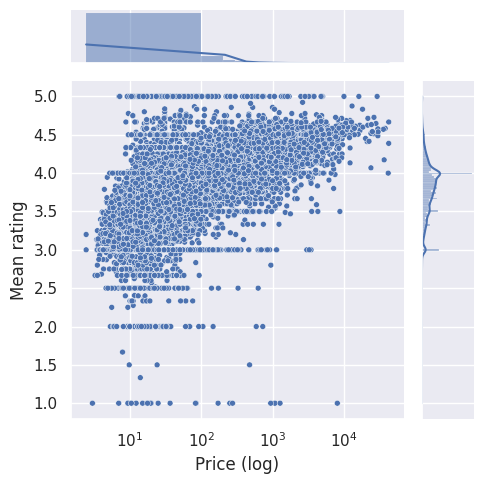

In [14]:
sns.set_theme(style='darkgrid')
g = sns.jointplot(wines[wines['mean_rating'] > 0], x='price', y ='mean_rating', marginal_kws={"kde": True}, height=5, size=1)
g.ax_joint.set_xscale("log")         # Set x-axis scale on the joint plot
g.ax_joint.set_xlabel("Price (log)")
g.ax_joint.set_ylabel("Mean rating")
g.ax_joint.legend([], [], frameon=False) # hide legend
plt.tight_layout()

In [26]:
# cut by quantile

def cut_quant(X, q=10, show=False):
    df = X.copy() # has price and mean_rating
    df['bins'], bins_edge = pd.qcut(np.log(df['price']), q=q, labels=False, retbins=True)
    df['norm_rating'] = df['mean_rating'] - df.groupby('bins', observed=True)['mean_rating'].transform('mean')

    if show:
        sns.scatterplot(df, x='price', y ='norm_rating', hue="bins")
        plt.xscale('log')
        plt.legend().set_visible(False)

    bin_mean_mapping = df.groupby('bins', observed=True)['mean_rating'].mean()
    return df.drop(columns=['mean_rating', 'price']), bins_edge, bin_mean_mapping #

def cut_quant_test(df, bin_edges, bin_mean_mapping):
    df_test = df.copy()

    extended_bin_edges = bin_edges.copy()
    extended_bin_edges[0] = -np.inf
    extended_bin_edges[-1] = np.inf
    
    df_test['bins'] = pd.cut(np.log(df_test['price']),
                             bins=extended_bin_edges,
                             labels=False,
                             include_lowest=True)

    df_test['norm_rating'] = df_test['mean_rating'] - df_test['bins'].map(bin_mean_mapping)
    
    return df_test.drop(columns=['mean_rating', 'price'])

In [20]:
# for equal bins!!

# cut by bins

def cut_bins(X, nb_bins=5, show=False, save=False):
    sns.set_theme(style='darkgrid')
    df = X.copy() # has price and mean_rating
    df['bins'], bins_edge = pd.cut(np.log(df['price']), bins = nb_bins, labels = False, retbins=True) 
    print("in cut")
    print(df['mean_rating'].shape)
    # removing biais
    df['norm_rating'] = df['mean_rating'] - df.groupby('bins', observed=True)['mean_rating'].transform('mean')

    bin_mean_mapping = df.groupby('bins', observed=True)['mean_rating'].mean()

    # # plot
    if show:
        sns.scatterplot(df, x='price', y ='norm_rating', hue="bins", palette="deep")
        plt.xlabel("Price (log)")
        plt.ylabel("Adjusted rating")
        plt.xscale('log')
        plt.legend()
        if save:
            plt.savefig("img/price_bins.jpg", dpi=300)
    
    # plot 2
    # if show:
    #     sns.scatterplot(df, x='price', y ='mean_rating', hue="bins", palette="deep")
    #     plt.xlabel("Price (log)")
    #     plt.ylabel("Mean rating")
    #     plt.xscale('log')
    #     plt.legend().set_visible(False)
    #     if save:
    #         plt.savefig("img/price_bins_normal.jpg", dpi=300)


    return df.drop(columns=['mean_rating', 'price']), bins_edge, bin_mean_mapping # remove columns mean_rating and price

def cut_bins_test(X_test, bin_edges, bin_mean_mapping):
    df_test = X_test.copy()

    extended_bin_edges = bin_edges.copy()
    extended_bin_edges[0] = -np.inf
    extended_bin_edges[-1] = np.inf
    
    # Use the same bin edges and integer labels
    df_test['bins'] = pd.cut(np.log(df_test['price']),
                             bins=extended_bin_edges,
                             labels=False,
                             include_lowest=True)

    df_test['norm_rating'] = df_test['mean_rating'] - df_test['bins'].map(bin_mean_mapping)

    # remove columns mean_rating and price
    # remove bins when train
    
    return df_test.drop(columns=['mean_rating', 'price'])

---

In [21]:
X_cols = ['type', 'year', 'country', 'region_name', 'winery_name', 'intensity', 'sweetness', 'acidity', 'tannin', 'fizziness', 'alcohol', 'drinking_window', 'food_filt', 'grapes_merged', 'price']
y_cols = ['mean_rating']
cat_cols = ['type', 'country', 'region_name', 'winery_name']

In [22]:
work_df.shape, work_df_test.shape

((37315, 16), (9329, 16))

### Performance on train for models - 5 cross validation

In [23]:
# splitting the 5 folds TRAIN
from sklearn.model_selection import StratifiedKFold

df = work_df[X_cols + y_cols].copy()
X, y = df.drop(columns=y_cols), df[y_cols]

# 5 splits
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
splits = list(skf.split(df, df['country'])) # 5 splits stratified

In [24]:
df.shape, X.shape

((37315, 16), (37315, 15))

In [25]:
df, bins_edge, bin_mean_mapping = cut_quant(work_df, q=10)

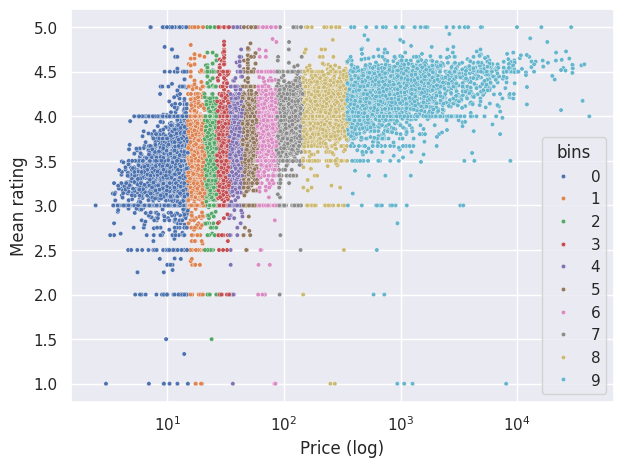

In [ ]:
sns.scatterplot(df, x='price', y='mean_rating', s=10, hue="bins", palette='deep')
plt.xlabel("Price (log)")
plt.ylabel("Mean rating")
plt.tight_layout()
plt.xscale('log')
plt.savefig("img/price_normal_quant10.jpg", dpi = 300)


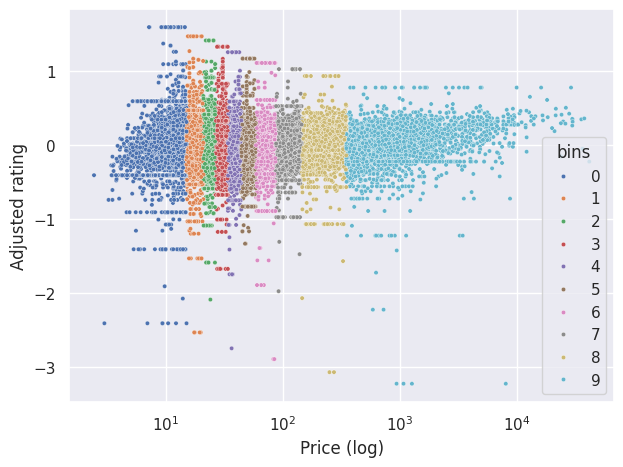

In [26]:
sns.scatterplot(df, x='price', y='norm_rating', s=10, hue="bins", palette='deep')
plt.xlabel("Price (log)")
plt.ylabel("Adjusted rating")
plt.tight_layout()
plt.xscale('log')
plt.savefig("img/price_adj_quant10.jpg", dpi = 300)


In [96]:
df = cut_quant_test(work_df_test, bins_edge, bin_mean_mapping)

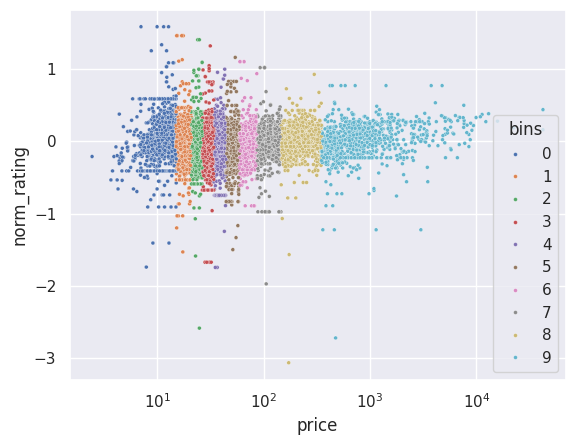

In [ ]:
# quantile cut on the test set 
sns.scatterplot(df, x='price', y='norm_rating', s=8, hue="bins", palette='deep')
plt.xscale('log')

In [ ]:
# from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# def cv_5_trainset(model_choice:str, X, y, splits):
#     mae_lst = []
#     mse_lst = []
#     r2_lst = []

#     prec_lst = []
#     rec_lst = []
#     f1_lst = []
#     acc_lst = []

#     for i, (train_idx, val_idx) in enumerate(splits):
#         match model_choice:
#             case "RF":
#                 model = RandomForestRegressor(
#                     random_state=0,
#                     n_estimators=500,
#                     max_depth=None,
#                     criterion="squared_error",
#                     )
#             case "XGB":
#                 model = XGBRegressor(
#                     enable_categorical=True,
#                     max_cat_to_onehot=10,
#                     n_estimators=800,
#                     learning_rate=0.03,
#                     max_depth=3,
#                     min_child_weight=5,
#                     gamma=0.1,
#                     subsample=0.8,
#                     colsample_bytree=0.8,
#                     reg_alpha=0.1,
#                     reg_lambda=1.0,
#                     random_state=0
#                 )
#             case _:
#                 model = CatBoostRegressor(
#                     iterations=500,
#                     learning_rate=0.05,
#                     depth=6,
#                     loss_function="RMSE",
#                     cat_features=cat_cols,
#                     verbose=100,
#                     random_state=0,
#                     allow_writing_files=False
#                     )
                
#         if model_choice == "RF":
#             cust_model = CustPipeline(model, RF = True)
#         else:   
#             cust_model = CustPipeline(model, RF = False)

#         # split of train and test according to splits
#         X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
#         y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

#         # Bins! remove bias on train and test before encoding!
#         df_train = pd.concat([X_train, y_train], axis = 1)
#         # df_train, bin_edges, bins_mean = cut_bins(df_train, nb_bins=5, show=False) # bins cut and bias remove

#         # quantil given
#         df_train, bin_edges, bins_mean = cut_quant(df_train, q=10, show=False)

#         # df_train has norm_rating, bins, no price, no mean_rating  
#         X_train_bins, y_train_bins = df_train.drop(columns=['bins', "norm_rating"]), df_train[["norm_rating"]] # mean rating becomes norm rating, bias removed
#         y_true_train_class = np.where(df_train["norm_rating"] >= 0, 1, 0)
    
#         # bias remove in test set
#         df_test = pd.concat([X_val,y_val], axis = 1)
#         # df_test = cut_bins_test(df_test, bin_edges, bins_mean)
#         # df_test = cut_custom_test(df_test, bin_edges, bin_mean_mapping)
#         df_test = cut_quant_test(df_test, bin_edges, bins_mean)
    
#         X_val_bins, y_val_bins = df_test.drop(columns=['bins', "norm_rating"]), df_test[["norm_rating"]] # corrected !
#         y_true_val_bins_class = np.where(df_test["norm_rating"] >= 0, 1, 0)
       
#         cust_model.fit(X_train_bins, y_train_bins.values.flatten())

#         # not adding the mean back
#         preds_train = cust_model.predict(X_train_bins) 
#         preds_train_class = np.where(preds_train >= 0, 1, 0)
#         preds = cust_model.predict(X_val_bins) 
#         preds_class = np.where(preds >= 0, 1, 0)

#         # regression
#         r2 = r2_score(y_val_bins, preds)
#         mae = mean_absolute_error(y_val_bins, preds)
#         mse = mean_squared_error(y_val_bins, preds)
        
#         r2_lst.append(r2)
#         mae_lst.append(mae)
#         mse_lst.append(mse)

#         print(f"Fold {i} train metrics MAE {mean_absolute_error(y_train_bins, preds_train)} MSE {mean_squared_error(y_train_bins, preds_train)} R2 {r2_score(y_train_bins, preds_train)}")
#         print(f"Fold {i} test metrics MAE {mae} MSE {mse} R2 {r2}")

#         # classification
#         prec = precision_score(y_true_val_bins_class, preds_class)
#         rec = recall_score(y_true_val_bins_class, preds_class)
#         f1 = f1_score(y_true_val_bins_class, preds_class)
#         acc = accuracy_score(y_true_val_bins_class, preds_class)

#         prec_lst.append(prec)
#         rec_lst.append(rec)
#         f1_lst.append(f1)
#         acc_lst.append(acc)

#         print(f"Fold {i} train metrics PREC {precision_score(y_true_train_class, preds_train_class)} REC {recall_score(y_true_train_class, preds_train_class)} F1 {f1_score(y_true_train_class, preds_train_class)} ACC {accuracy_score(y_true_train_class,preds_train_class)}")
#         print(f"Fold {i} test metrics PREC {prec} REC {rec} F1 {f1} ACC {acc}")
        
#     print(f"Mean metrics \nMAE {np.mean(mae_lst)} \nMSE {np.mean(mse_lst)} \nR2 {np.mean(r2_lst)}")
#     print(f"Mean metrics \nPREC {np.mean(prec_lst)} \nREC {np.mean(rec_lst)} \nf1 {np.mean(f1_lst)} \naccuracy {np.mean(acc_lst)}")
#     return [mae_lst, mse_lst, r2_lst], [prec_lst, rec_lst, f1_lst, acc_lst]


k=5 CV for regression models

In [ ]:
# test with price, no norm, no classification

def cv_5_trainset(model_choice:str, X, y, splits):
    print('CV 5 normal mean rating, OHE grapes, and keep price in features')
    mae_lst = []
    mse_lst = []
    r2_lst = []

    for i, (train_idx, val_idx) in enumerate(splits):
        match model_choice:
            case "RF":
                model = RandomForestRegressor(
                    random_state=0,
                    n_estimators=500,
                    max_depth=None,
                    criterion="squared_error",
                    )
            case "XGB":
                model = XGBRegressor(
                    enable_categorical=True,
                    max_cat_to_onehot=10,
                    n_estimators=500,
                    learning_rate=0.03,
                    max_depth=3,
                    min_child_weight=5,
                    gamma=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=1.0,
                    random_state=0
                )
            case _:
                model = CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    loss_function="RMSE",
                    cat_features=cat_cols,
                    verbose=100,
                    random_state=0,
                    allow_writing_files=False
                    )
                
        if model_choice == "RF":
            cust_model = CustPipeline(model, RF = True)
        else:   
            cust_model = CustPipeline(model, RF = False)

        # split of train and test according to splits
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

        # print(X_train.columns)

        # no norm, so no bins, keep ratings
        # print(X_train['price'].min(),X_train['price'].max(), y_train.columns)
       
        cust_model.fit(X_train, y_train.values.flatten())

        # not adding the mean back
        preds_train = cust_model.predict(X_train) 
        preds = cust_model.predict(X_val) 

        # regression
        r2 = r2_score(y_val, preds)
        mae = mean_absolute_error(y_val, preds)
        mse = mean_squared_error(y_val, preds)
        
        r2_lst.append(r2)
        mae_lst.append(mae)
        mse_lst.append(mse)

        print(f"Fold {i} train metrics MAE {mean_absolute_error(y_train, preds_train)} MSE {mean_squared_error(y_train, preds_train)} R2 {r2_score(y_train, preds_train)}")
        print(f"Fold {i} test metrics MAE {mae} MSE {mse} R2 {r2}")
        
    print(f"Mean metrics \nMAE {np.mean(mae_lst)} \nMSE {np.mean(mse_lst)} \nR2 {np.mean(r2_lst)}")
    return [mae_lst, mse_lst, r2_lst]

In [31]:
catb_new_scores = cv_5_trainset("CATB", X, y, splits)

CV 5 normal mean rating, OHE grapes, and keep price in features
0:	learn: 0.3613266	total: 31.1ms	remaining: 15.5s
100:	learn: 0.2518694	total: 3.04s	remaining: 12s
200:	learn: 0.2468764	total: 5.82s	remaining: 8.66s
300:	learn: 0.2435469	total: 8.65s	remaining: 5.72s
400:	learn: 0.2407996	total: 11.4s	remaining: 2.8s
499:	learn: 0.2385029	total: 14.1s	remaining: 0us
Fold 0 train metrics MAE 0.1566184175395492 MSE 0.055314244291874384 R2 0.5939838016288251
Fold 0 test metrics MAE 0.16285611772926717 MSE 0.05991584231213706 R2 0.5488722249527352
0:	learn: 0.3608830	total: 31.2ms	remaining: 15.6s
100:	learn: 0.2518426	total: 2.76s	remaining: 10.9s
200:	learn: 0.2469744	total: 5.26s	remaining: 7.82s
300:	learn: 0.2435768	total: 7.84s	remaining: 5.18s
400:	learn: 0.2407383	total: 10.3s	remaining: 2.53s
499:	learn: 0.2385121	total: 12.7s	remaining: 0us
Fold 1 train metrics MAE 0.15709748678747487 MSE 0.055555578221750605 R2 0.5919439094041477
Fold 1 test metrics MAE 0.16341356959928305 MSE 

In [32]:
xgb_new_scores = cv_5_trainset("XGB", X, y, splits)

CV 5 normal mean rating, OHE grapes, and keep price in features
Fold 0 train metrics MAE 0.15628738701343536 MSE 0.0542813278734684 R2 0.6015655994415283
Fold 0 test metrics MAE 0.1987249106168747 MSE 0.0799933448433876 R2 0.3977015018463135
Fold 1 train metrics MAE 0.15604475140571594 MSE 0.054113637655973434 R2 0.6025350093841553
Fold 1 test metrics MAE 0.19289205968379974 MSE 0.07557275891304016 R2 0.43257272243499756
Fold 2 train metrics MAE 0.15580156445503235 MSE 0.054017748683691025 R2 0.6031824350357056
Fold 2 test metrics MAE 0.1955372393131256 MSE 0.07697854191064835 R2 0.4222838282585144
Fold 3 train metrics MAE 0.15580140054225922 MSE 0.053373076021671295 R2 0.6036200523376465
Fold 3 test metrics MAE 0.20149043202400208 MSE 0.08305712789297104 R2 0.4031304121017456
Fold 4 train metrics MAE 0.15619443356990814 MSE 0.053908415138721466 R2 0.5995227098464966
Fold 4 test metrics MAE 0.1987084597349167 MSE 0.08004019409418106 R2 0.4255226254463196
Mean metrics 
MAE 0.19747062027

In [ ]:
RF_new_scores = cv_5_trainset("RF", X, y, splits)

---

k=5 CV for classification models

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

def cv_5_trainset(model_choice:str, X, y, splits):
    mae_lst = []
    mse_lst = []
    r2_lst = []

    prec_lst = []
    rec_lst = []
    f1_lst = []
    acc_lst = []

    for i, (train_idx, val_idx) in enumerate(splits):
        match model_choice:
            case "RF":
                model = RandomForestRegressor(
                    random_state=0,
                    n_estimators=500,
                    max_depth=None,
                    criterion="squared_error",
                    )
            case "XGB":
                model = XGBRegressor(
                    enable_categorical=True,
                    max_cat_to_onehot=10,
                    n_estimators=800,
                    learning_rate=0.03,
                    max_depth=3,
                    min_child_weight=5,
                    gamma=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_alpha=0.1,
                    reg_lambda=1.0,
                    random_state=0
                )
            case _:
                model = CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    loss_function="RMSE",
                    cat_features=cat_cols,
                    verbose=100,
                    random_state=0,
                    allow_writing_files=False
                    )
                
        if model_choice == "RF":
            cust_model = CustPipeline(model, RF = True)
        else:   
            cust_model = CustPipeline(model, RF = False)

        # split of train and test according to splits
        X_train, X_val = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
        y_train, y_val = y.iloc[train_idx].copy(), y.iloc[val_idx].copy()

        df_train = pd.concat([X_train, y_train], axis = 1)

        # quantil 
        df_train, bin_edges, bins_mean = cut_quant(df_train, q=10, show=False)

        # df_train has norm_rating, bins, no price, no mean_rating  
        X_train_bins, y_train_bins = df_train.drop(columns=['bins', "norm_rating"]), df_train[["norm_rating"]] # mean rating becomes norm rating, bias removed
        y_true_train_class = np.where(df_train["norm_rating"] >= 0, 1, 0)
    
        # bias remove in test set
        df_test = pd.concat([X_val,y_val], axis = 1)
        df_test = cut_quant_test(df_test, bin_edges, bins_mean)
    
        X_val_bins, y_val_bins = df_test.drop(columns=['bins', "norm_rating"]), df_test[["norm_rating"]] # corrected !
        y_true_val_bins_class = np.where(df_test["norm_rating"] >= 0, 1, 0)
       
        cust_model.fit(X_train_bins, y_train_bins.values.flatten())

        # not adding the mean back
        preds_train = cust_model.predict(X_train_bins) 
        preds_train_class = np.where(preds_train >= 0, 1, 0)
        preds = cust_model.predict(X_val_bins) 
        preds_class = np.where(preds >= 0, 1, 0)

        # regression
        r2 = r2_score(y_val_bins, preds)
        mae = mean_absolute_error(y_val_bins, preds)
        mse = mean_squared_error(y_val_bins, preds)
        
        r2_lst.append(r2)
        mae_lst.append(mae)
        mse_lst.append(mse)

        print(f"Fold {i} train metrics MAE {mean_absolute_error(y_train_bins, preds_train)} MSE {mean_squared_error(y_train_bins, preds_train)} R2 {r2_score(y_train_bins, preds_train)}")
        print(f"Fold {i} test metrics MAE {mae} MSE {mse} R2 {r2}")

        # classification
        prec = precision_score(y_true_val_bins_class, preds_class)
        rec = recall_score(y_true_val_bins_class, preds_class)
        f1 = f1_score(y_true_val_bins_class, preds_class)
        acc = accuracy_score(y_true_val_bins_class, preds_class)

        prec_lst.append(prec)
        rec_lst.append(rec)
        f1_lst.append(f1)
        acc_lst.append(acc)

        print(f"Fold {i} train metrics PREC {precision_score(y_true_train_class, preds_train_class)} REC {recall_score(y_true_train_class, preds_train_class)} F1 {f1_score(y_true_train_class, preds_train_class)} ACC {accuracy_score(y_true_train_class,preds_train_class)}")
        print(f"Fold {i} test metrics PREC {prec} REC {rec} F1 {f1} ACC {acc}")
        
    print(f"Mean metrics \nMAE {np.mean(mae_lst)} \nMSE {np.mean(mse_lst)} \nR2 {np.mean(r2_lst)}")
    print(f"Mean metrics \nPREC {np.mean(prec_lst)} \nREC {np.mean(rec_lst)} \nf1 {np.mean(f1_lst)} \naccuracy {np.mean(acc_lst)}")
    return [mae_lst, mse_lst, r2_lst], [prec_lst, rec_lst, f1_lst, acc_lst]


In [32]:
cat_scores, cat_class = cv_5_trainset("CATB", X, y, splits)

0:	learn: 0.2770310	total: 82.5ms	remaining: 41.2s
100:	learn: 0.2544563	total: 2.47s	remaining: 9.74s
200:	learn: 0.2512099	total: 4.75s	remaining: 7.07s
300:	learn: 0.2482882	total: 7.14s	remaining: 4.72s
400:	learn: 0.2465152	total: 9.36s	remaining: 2.31s
499:	learn: 0.2448328	total: 11.5s	remaining: 0us
Fold 0 train metrics MAE 0.1577609264156177 MSE 0.05605626769627393 R2 0.27766556603268
Fold 0 test metrics MAE 0.1683581249303254 MSE 0.06197180496775286 R2 0.19014841873859467
Fold 0 train metrics PREC 0.7540940480105228 REC 0.7155070202808113 F1 0.7342939481268012 ACC 0.7220286747956586
Fold 0 test metrics PREC 0.6919864265204907 REC 0.6635794743429286 F1 0.6774853053922821 ACC 0.661798204475412
0:	learn: 0.2778851	total: 26ms	remaining: 13s
100:	learn: 0.2546760	total: 2.22s	remaining: 8.76s
200:	learn: 0.2514400	total: 4.65s	remaining: 6.92s
300:	learn: 0.2485034	total: 7.08s	remaining: 4.68s
400:	learn: 0.2462618	total: 9.53s	remaining: 2.35s
499:	learn: 0.2446103	total: 12s	r

In [165]:
xgb_scores, xgb_class = cv_5_trainset("XGB", X, y, splits)

Fold 0 train metrics MAE 0.16080322861671448 MSE 0.05553489923477173 R2 0.2843838334083557
Fold 0 test metrics MAE 0.2041493058204651 MSE 0.08464189618825912 R2 -0.10610580444335938
Fold 0 train metrics PREC 0.7261736852710055 REC 0.6746957878315133 F1 0.6994889047033707 ACC 0.6887980704810398
Fold 0 test metrics PREC 0.625 REC 0.40175219023779724 F1 0.48910559195489867 ACC 0.5507168698914645
Fold 1 train metrics MAE 0.1606694459915161 MSE 0.05550068989396095 R2 0.28911125659942627
Fold 1 test metrics MAE 0.1977701336145401 MSE 0.07819385826587677 R2 -0.04412972927093506
Fold 1 train metrics PREC 0.7244911622924478 REC 0.6759745127436282 F1 0.6993924508790073 ACC 0.6883960873643307
Fold 1 test metrics PREC 0.6067558954748248 REC 0.4714038128249567 F1 0.5305838093911105 ACC 0.5485729599356827
Fold 2 train metrics MAE 0.16072718799114227 MSE 0.055511485785245895 R2 0.286223828792572
Fold 2 test metrics MAE 0.1998647153377533 MSE 0.08005668222904205 R2 -0.05092895030975342
Fold 2 train me

In [166]:
rf_scores, rf_class = cv_5_trainset("RF", X, y, splits)

Fold 0 train metrics MAE 0.055194291489772035 MSE 0.0072949565485847 R2 0.905998052922664
Fold 0 test metrics MAE 0.18256718622597673 MSE 0.07498248606274656 R2 0.020123991282409937
Fold 0 train metrics PREC 0.926135648672455 REC 0.9185647425897036 F1 0.9223346596071306 ACC 0.9169569878065121
Fold 0 test metrics PREC 0.6759002770083102 REC 0.6718397997496871 F1 0.6738639216670851 ACC 0.651882620929921
Fold 1 train metrics MAE 0.05514261450850353 MSE 0.007159589956405777 R2 0.9082953356974784
Fold 1 test metrics MAE 0.18635850254512643 MSE 0.07864877150887906 R2 -0.05020410803640263
Fold 1 train metrics PREC 0.9280322093608455 REC 0.9215392303848076 F1 0.9247743229689067 ACC 0.9196033766581804
Fold 1 test metrics PREC 0.6818881477680862 REC 0.6580836840802179 F1 0.669774473982613 ACC 0.6488007503684845
Fold 2 train metrics MAE 0.0545975918258964 MSE 0.00710055844245823 R2 0.9086998095790908
Fold 2 test metrics MAE 0.18556683840053492 MSE 0.07866483926200854 R2 -0.032657911877368884
Fold

### Plots

In [ ]:
# only regression and with price

# df for regression
met_cols = ["MAE", "MSE", "R2"]
rf_df = pd.DataFrame(RF_new_scores).T
rf_df.columns = met_cols
rf_df['model'] = "Random Forest"

cat_df = pd.DataFrame(catb_new_scores).T
cat_df.columns = met_cols
cat_df['model'] = "CatBoost"

xgb_df = pd.DataFrame(xgb_new_scores).T
xgb_df.columns = met_cols
xgb_df['model'] = "XGBoost"

scores_models = pd.concat([rf_df, xgb_df, cat_df])

scores_melt = scores_models.melt(
    id_vars="model",
    value_vars=met_cols,
    var_name="metric",
    value_name="value"
)

In [ ]:
# df for classification

met_cols = ["MAE", "MSE", "R2"]
rf_df = pd.DataFrame(rf_scores).T
rf_df.columns = met_cols
rf_df['model'] = "Random Forest"

cat_df = pd.DataFrame(cat_scores).T
cat_df.columns = met_cols
cat_df['model'] = "CatBoost"

xgb_df = pd.DataFrame(xgb_scores).T
xgb_df.columns = met_cols
xgb_df['model'] = "XGBoost"

scores_models = pd.concat([rf_df, xgb_df, cat_df])

scores_melt = scores_models.melt(
    id_vars="model",
    value_vars=met_cols,
    var_name="metric",
    value_name="value"
)

In [198]:
met_cols = ["Precision", "Recall", "F1", "Accuracy"]
rf_df = pd.DataFrame(rf_class).T
rf_df.columns = met_cols
rf_df['model'] = "Random Forest"

cat_df = pd.DataFrame(cat_class).T
cat_df.columns = met_cols
cat_df['model'] = "CatBoost"

xgb_df = pd.DataFrame(xgb_class).T
xgb_df.columns = met_cols
xgb_df['model'] = "XGBoost"

scores_models = pd.concat([rf_df, xgb_df, cat_df])

class_melt = scores_models.melt(
    id_vars="model",
    value_vars=met_cols,
    var_name="metric",
    value_name="value"
)

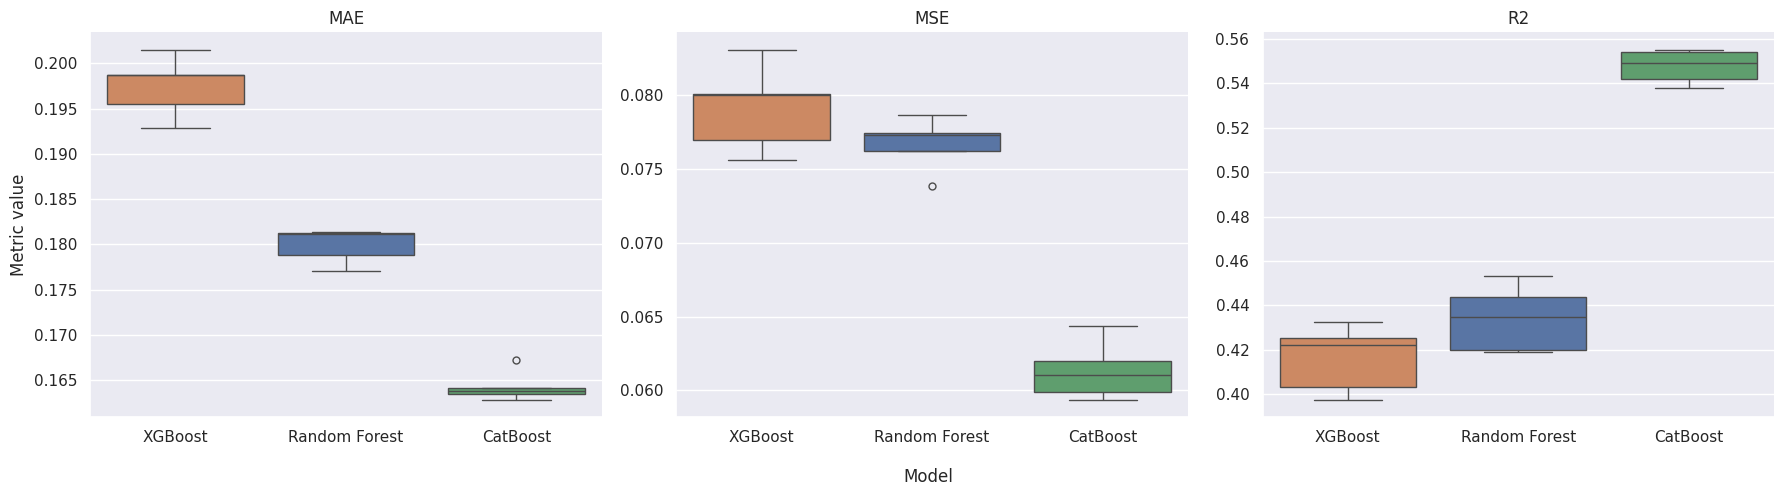

In [74]:
# plots on normal ratinhg, PRICE included

sns.set_theme(style="darkgrid")

g = sns.catplot(
    data=scores_melt,
    x="model",
    y="value",
    col="metric",
    kind="box",
    sharey=False,
    height=5, aspect=1.2,
    hue="model",
    order=["XGBoost", "Random Forest", "CatBoost"]
)

g.set_titles("{col_name}")
g.set_xticklabels(rotation=0)
g.set_ylabels("Metric value")
g.set_xlabels("")

g.figure.subplots_adjust(bottom=0.15) 
g.figure.text(0.52, 0.02, "Model", ha="center", fontsize=12)

g.figure.savefig(f"img/F_metric_reg_p_norm.jpg", dpi=300) # price normalized
plt.show()

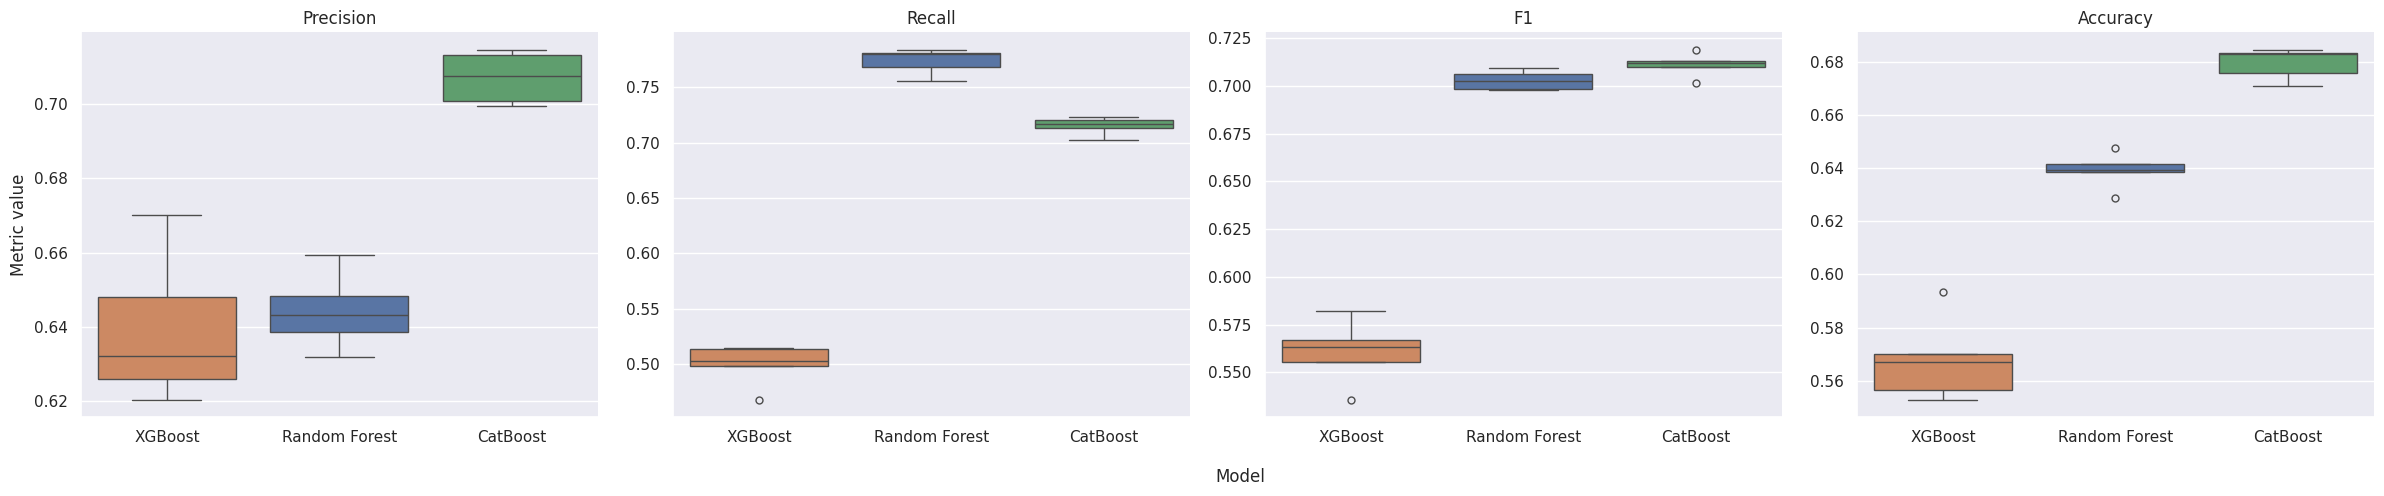

In [191]:
# plots on unbiased ratings

sns.set_theme(style="darkgrid")

g = sns.catplot(
    data=class_melt,
    x="model",
    y="value",
    col="metric",
    kind="box",
    sharey=False,
    height=5, aspect=1.2,
    hue="model",
    order=["XGBoost", "Random Forest", "CatBoost"]
)

g.set_titles("{col_name}")
g.set_xticklabels(rotation=0)
g.set_ylabels("Metric value")
g.set_xlabels("")

g.figure.subplots_adjust(bottom=0.15) 
g.figure.text(0.52, 0.02, "Model", ha="center", fontsize=12)

# g.figure.suptitle("Performance for bins 5", y=1.05)

# plt.tight_layout()
# g.figure.tight_layout()
g.figure.savefig(f"img/perf_draft_bins5_class", dpi=300)
plt.show()

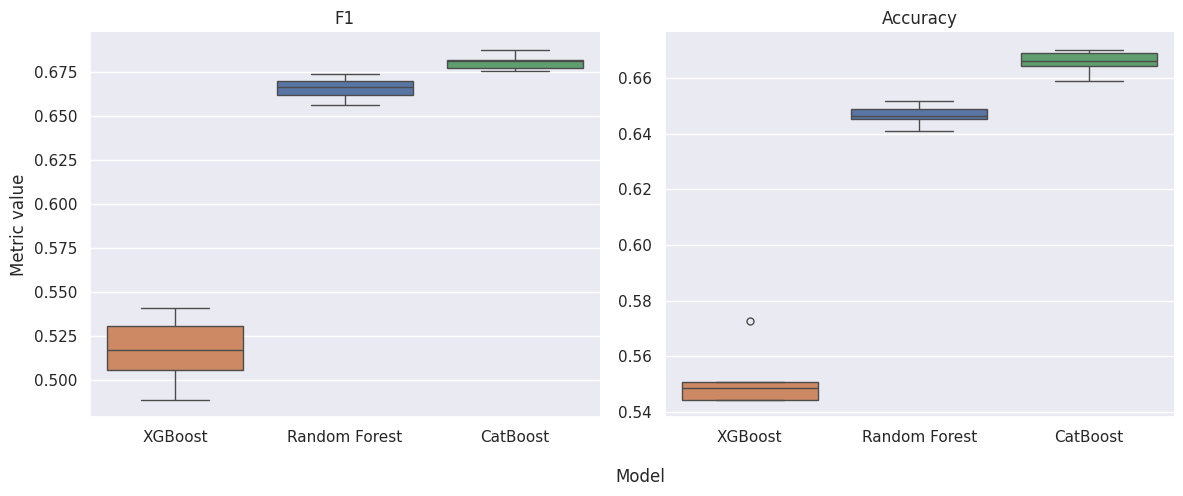

In [ ]:
# plots on unbiased ratings F1 and Accuracy 

sns.set_theme(style="darkgrid")

g = sns.catplot(
    data=class_melt[class_melt['metric'].isin(['F1', 'Accuracy'])],
    x="model",
    y="value",
    col="metric",
    kind="box",
    sharey=False,
    height=5, aspect=1.2,
    hue="model",
    order=["XGBoost", "Random Forest", "CatBoost"]
)

g.set_titles("{col_name}")
g.set_xticklabels(rotation=0)
g.set_ylabels("Metric value")
g.set_xlabels("")

g.figure.subplots_adjust(bottom=0.15) 
g.figure.text(0.54, 0.02, "Model", ha="center", fontsize=12)

# g.figure.suptitle("Performance for bins 5", y=1.05)

# plt.tight_layout()
# g.figure.tight_layout()
g.figure.savefig(f"img/F_metric_classif_cv", dpi=300)
plt.show()

#### Models k=5 CV regression on normalized ratings and price removed: for Appendix

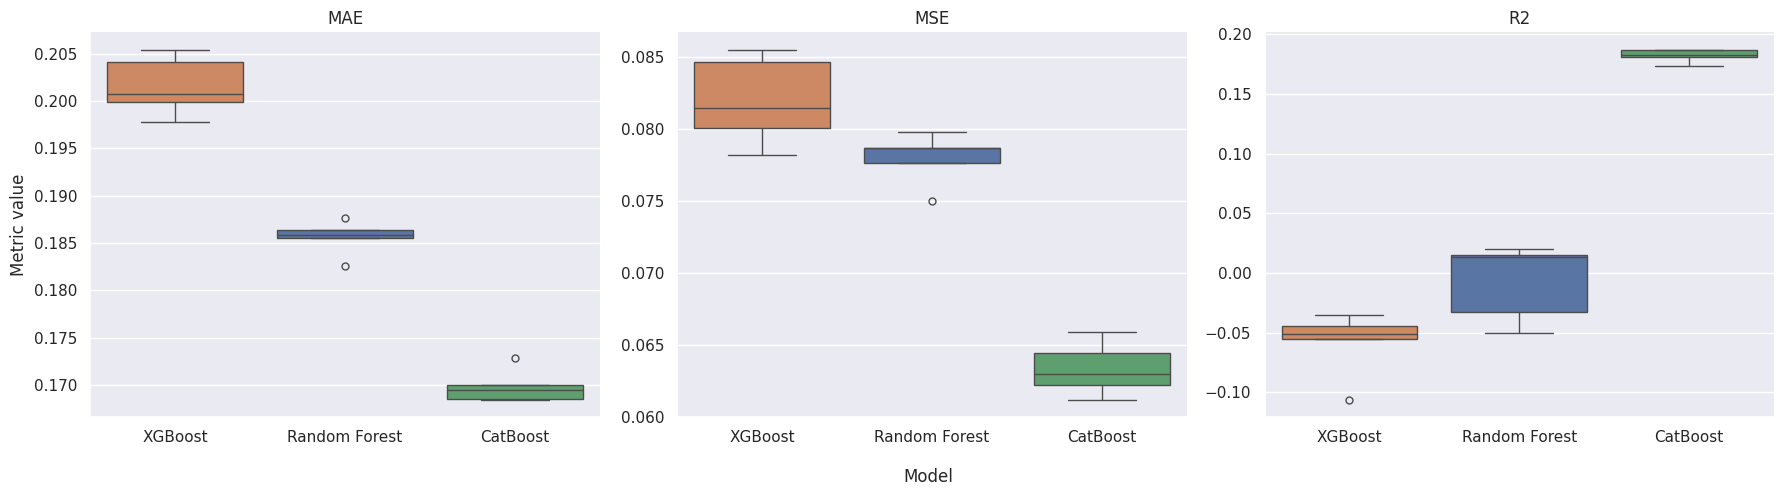

In [201]:
# plots on adjusted ratings 

sns.set_theme(style="darkgrid")

g = sns.catplot(
    data=scores_melt,
    x="model",
    y="value",
    col="metric",
    kind="box",
    sharey=False,
    height=5, aspect=1.2,
    hue="model",
    order=["XGBoost", "Random Forest", "CatBoost"]
)

g.set_titles("{col_name}")
g.set_xticklabels(rotation=0)
g.set_ylabels("Metric value")
g.set_xlabels("")

g.figure.subplots_adjust(bottom=0.15) 
g.figure.text(0.52, 0.02, "Model", ha="center", fontsize=12)

g.figure.savefig(f"img/F_metric_reg_quant_bias.jpg", dpi=300) # price normalized
plt.show()

---

### Performance on test

In [34]:
train = work_df[X_cols + y_cols].copy()
test = work_df_test[X_cols + y_cols].copy()

In [35]:
train.shape, test.shape

((37315, 16), (9329, 16))

In [42]:
# evaluation for regression

def eval_test(model, train, test, RF = False):
    
    X_train, y_train = train.drop(columns="mean_rating"), train[["mean_rating"]]

    print(X_train.columns, y_train.columns)

    cust_model = CustPipeline(model, RF = RF)
    cust_model.fit(X_train, y_train.values.flatten())

    X_test, y_test = test.drop(columns="mean_rating"), test[["mean_rating"]]

    # predict
    preds_train = cust_model.predict(X_train) 
    preds = cust_model.predict(X_test) 

    # reg
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)
    
    print(f"Fold train metrics MAE {mean_absolute_error(y_train, preds_train)} MSE {mean_squared_error(y_train, preds_train)} R2 {r2_score(y_train, preds_train)}")

    print(f"test metrics MAE {mae} MSE {mse} R2 {r2}")

    return [mae, mse, r2, preds_train, y_train, preds, y_test, cust_model] 

In [37]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, precision_score, recall_score, f1_score, accuracy_score, r2_score

In [59]:
# evaluation for classification

def eval_test(model, train, test, RF = False):
    
    # bins on train
    # df_train, bin_edges, bins_mean = cut_bins(train, nb_bins=5, show=False)
    df_train, bin_edges, bins_mean = cut_quant(train, q=10, show=False)
    X_train, y_train = df_train.drop(columns=['bins', "norm_rating"]), df_train[["norm_rating"]]
    y_true_train_class = np.where(df_train["norm_rating"] >= 0, 1, 0)
    print(X_train.columns, y_train.columns)

    print("bins, ", bin_edges)

    cust_model = CustPipeline(model, RF = RF)
    cust_model.fit(X_train, y_train.values.flatten())

    # bins before predict 
    # df_test = cut_bins_test(test, bin_edges, bins_mean)
    df_test = cut_quant_test(test, bin_edges, bins_mean)

    print("number of bins")
    print(df_test.groupby('bins')['bins'].count())

    X_test, y_test = df_test.drop(columns=['bins', "norm_rating"]), df_test[["norm_rating"]]
    y_true_val_bins_class = np.where(df_test["norm_rating"] >= 0, 1, 0)

    # predict
    preds_train = cust_model.predict(X_train) 
    preds_train_class = np.where(preds_train >= 0, 1, 0)

    preds = cust_model.predict(X_test) 
    preds_class = np.where(preds >= 0, 1, 0)

    # reg
    r2 = r2_score(y_test, preds)
    mae = mean_absolute_error(y_test, preds)
    mse = mean_squared_error(y_test, preds)

    # classification
    prec = precision_score(y_true_val_bins_class, preds_class)
    rec = recall_score(y_true_val_bins_class, preds_class)
    f1 = f1_score(y_true_val_bins_class, preds_class)
    acc = accuracy_score(y_true_val_bins_class, preds_class)

    print(f"train metrics PREC {precision_score(y_true_train_class, preds_train_class)} REC {recall_score(y_true_train_class, preds_train_class)} F1 {f1_score(y_true_train_class, preds_train_class)} ACC {accuracy_score(y_true_train_class,preds_train_class)}")
    print(f"Fold train metrics MAE {mean_absolute_error(y_train, preds_train)} MSE {mean_squared_error(y_train, preds_train)} R2 {r2_score(y_train, preds_train)}")

    print(f"test metrics MAE {mae} MSE {mse} R2 {r2}")
    print(f"test metrics PREC {prec} REC {rec} F1 {f1} ACC {acc}")

    return [mae, mse, r2, prec, rec, f1, acc, preds_train, y_train, preds, y_test, pd.concat([df_test, test[['mean_rating', 'price']]], axis = 1), cust_model] 

### Test results

In [40]:
# Regression on test
res_cat_new = eval_test(CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    loss_function="RMSE",
                    cat_features=cat_cols,
                    verbose=100,
                    random_state=0,
                    allow_writing_files=False
                    ), train, test, RF = False)

Index(['type', 'year', 'country', 'region_name', 'winery_name', 'intensity',
       'sweetness', 'acidity', 'tannin', 'fizziness', 'alcohol',
       'drinking_window', 'food_filt', 'grapes_merged', 'price'],
      dtype='object') Index(['mean_rating'], dtype='object')
0:	learn: 0.3601614	total: 33.8ms	remaining: 16.9s
100:	learn: 0.2505821	total: 3.31s	remaining: 13.1s
200:	learn: 0.2461091	total: 6.37s	remaining: 9.48s
300:	learn: 0.2431927	total: 9.42s	remaining: 6.23s
400:	learn: 0.2406813	total: 12.5s	remaining: 3.1s
499:	learn: 0.2387677	total: 15.4s	remaining: 0us
Fold train metrics MAE 0.15711806241348183 MSE 0.05582919212310632 R2 0.5881440402091715
test metrics MAE 0.16263520606399368 MSE 0.05928215351171821 R2 0.5525750817887636


In [44]:
preds_train_cat, y_train_cat, preds_cat, y_test_cat, cust_model_cat = res_cat_new[3:]

In [60]:
# Classification on test
res_cat_new = eval_test(CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    loss_function="RMSE",
                    cat_features=cat_cols,
                    verbose=100,
                    random_state=0,
                    allow_writing_files=False
                    ), train, test, RF = False)

Index(['type', 'year', 'country', 'region_name', 'winery_name', 'intensity',
       'sweetness', 'acidity', 'tannin', 'fizziness', 'alcohol',
       'drinking_window', 'food_filt', 'grapes_merged'],
      dtype='object') Index(['norm_rating'], dtype='object')
bins,  [ 0.88560387  2.70735769  3.03718568  3.27298515  3.52053181  3.78396234
  4.07228257  4.45730107  4.97852524  5.85100038 10.63523025]
0:	learn: 0.2767453	total: 34.2ms	remaining: 17s
100:	learn: 0.2537965	total: 2.97s	remaining: 11.7s
200:	learn: 0.2509476	total: 5.73s	remaining: 8.52s
300:	learn: 0.2486105	total: 8.43s	remaining: 5.57s
400:	learn: 0.2467968	total: 11.2s	remaining: 2.76s
499:	learn: 0.2451704	total: 13.8s	remaining: 0us
number of bins
bins
0    921
1    966
2    923
3    955
4    968
5    881
6    931
7    899
8    985
9    900
Name: bins, dtype: int64
train metrics PREC 0.7444927086565312 REC 0.7193464574797641 F1 0.7317035982923359 ACC 0.7170574835856894
Fold train metrics MAE 0.15791508186942926 MSE 0.0

In [54]:
cust_model_cat_class = res_cat_new[-1]

### Plots

/home/franciline/.local/lib/python3.12/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)


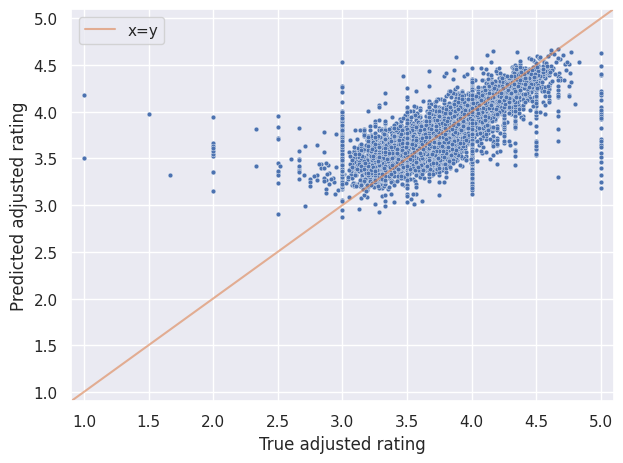

In [ ]:
# plot for regression
sns.set_theme(style='darkgrid')

# pd.DataFrame({"pred": preds_train_cat, "true" : y_train_cat['mean_rating']})
df = pd.DataFrame({"pred": preds_cat, "true" : y_test_cat['mean_rating']})

sns.scatterplot(df, x="true", y="pred", s=12, c=sns.color_palette()[0])
plt.xlabel("True adjusted rating")
plt.ylabel("Predicted adjusted rating")
# plt.title("TEST CATB price and no norma")
plt.plot([-1, 6], [-1, 6], c=sns.color_palette()[1], alpha = 0.6, label = "x=y")
plt.xlim(0.9, 5.1)
plt.ylim(0.9, 5.1)
# plt.xlim(min(preds_train_cat) - 0.1, 5.1)
plt.legend()
plt.tight_layout()

/home/franciline/.local/lib/python3.12/site-packages/seaborn/relational.py:438: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  points = ax.scatter(x=x, y=y, **kws)


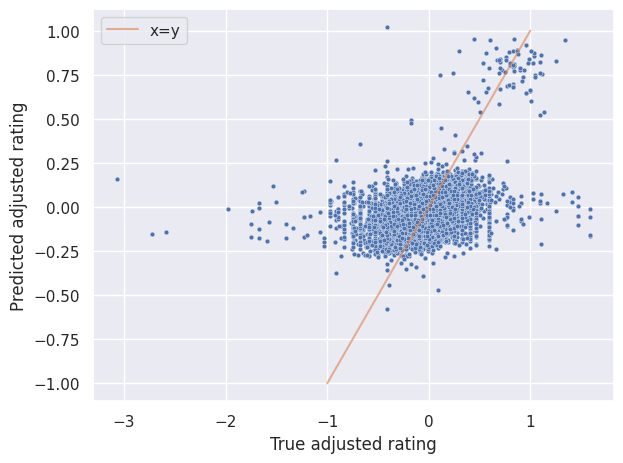

In [ ]:
# plot for appendix
sns.set_theme(style='darkgrid')

# pd.DataFrame({"pred": preds_train_cat, "true" : y_train_cat['mean_rating']})
df = pd.DataFrame({"pred": preds, "true" : y_test['norm_rating']})

sns.scatterplot(df, x="true", y="pred", s=12, c=sns.color_palette()[0])
plt.xlabel("True adjusted rating")
plt.ylabel("Predicted adjusted rating")
# plt.title("TEST CATB price and no norma")
plt.plot([-1, 1], [-1, 1], c=sns.color_palette()[1], alpha = 0.6, label = "x=y")
# plt.xlim(0.9, 5.1)
# plt.ylim(0.9, 5.1)
# plt.xlim(min(preds_train_cat) - 0.1, 5.1)
plt.legend()
plt.tight_layout()
plt.savefig("img/true_pred_reg_catb_test_bias.jpg", dpi = 300)

In [ ]:
# Classification

preds_train_cat, y_train_cat, preds_cat, y_test_cat, df_test_end, cust_model_cat = res_cat_new[7:]
true_class_test = np.where(y_test_cat['norm_rating']>= 0, 1, 0)
pred_class_test = np.where(preds_cat >= 0, 1, 0)
df_test_end['true_class'] = true_class_test
df_test_end['pred_class'] = pred_class_test

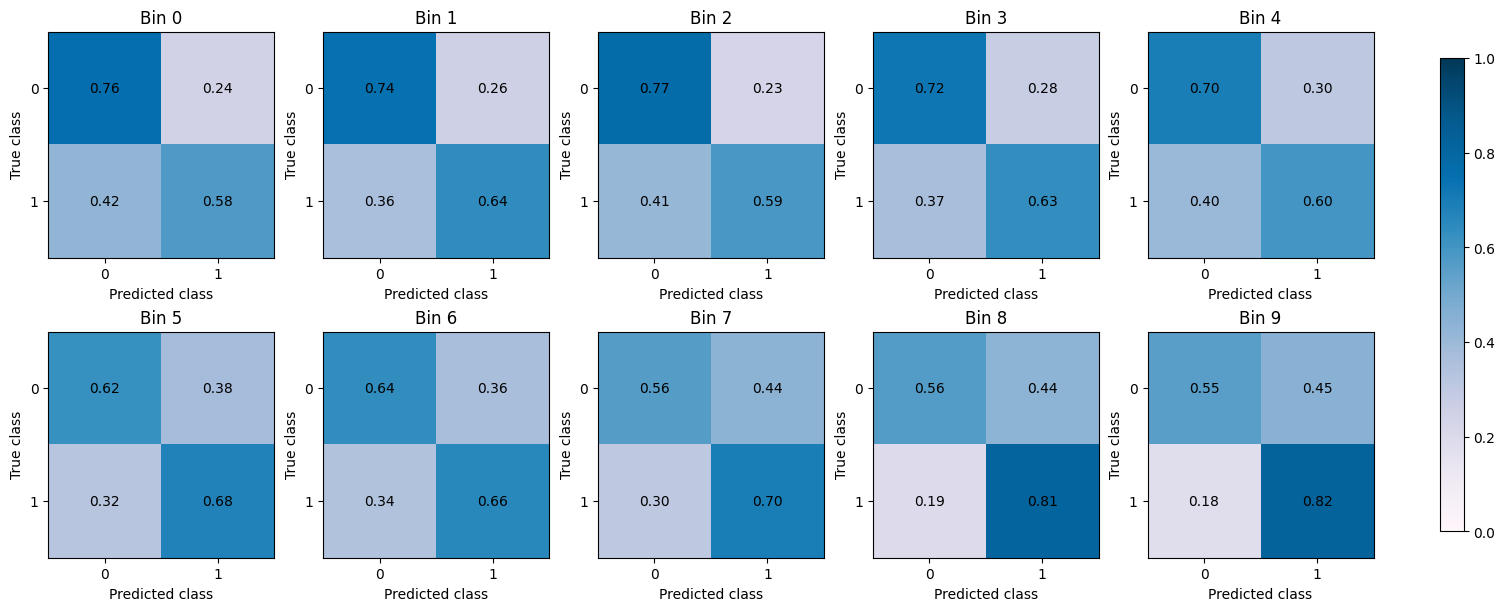

In [68]:
from sklearn.metrics import confusion_matrix

bins = sorted(df_test_end['bins'].unique())  # should be 10 bins
nrows, ncols = 2, 5

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(15, 6),
    constrained_layout=True
)

axes = axes.flatten()

vmin, vmax = 0, 1
im = None

for ax, b in zip(axes, bins):
    e = df_test_end[df_test_end['bins'] == b]
    cm = confusion_matrix(
        e['true_class'], e['pred_class'], normalize="true"
    )

    im = ax.imshow(cm, cmap="PuBu", vmin=vmin, vmax=vmax)
    ax.set_title(f"Bin {b}")
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.grid(False)

    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels([0, 1])
    ax.set_yticklabels([0, 1])

    # numbers inside cells
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(
                j, i, f"{cm[i, j]:.2f}",
                ha="center", va="center", color="black"
            )

# shared colorbar on the right
fig.colorbar(im, ax=axes, location="right", shrink=0.9)

plt.savefig("img/cm_all_each_bins.jpg", dpi=300)
plt.show()


## Model importance feature

In [68]:
# classification/regression

res_cat = eval_test(CatBoostRegressor(
                    iterations=500,
                    learning_rate=0.05,
                    depth=6,
                    loss_function="RMSE",
                    cat_features=cat_cols,
                    verbose=100,
                    random_state=0,
                    allow_writing_files=False
                    ), train, test, RF = False)

Index(['type', 'year', 'country', 'region_name', 'winery_name', 'intensity',
       'sweetness', 'acidity', 'tannin', 'fizziness', 'alcohol',
       'drinking_window', 'food_filt', 'grapes_merged'],
      dtype='object') Index(['norm_rating'], dtype='object')
bins,  [ 0.88560387  2.70735769  3.03718568  3.27298515  3.52053181  3.78396234
  4.07228257  4.45730107  4.97852524  5.85100038 10.63523025]
0:	learn: 0.2767453	total: 31.6ms	remaining: 15.8s
100:	learn: 0.2537965	total: 2.58s	remaining: 10.2s
200:	learn: 0.2509476	total: 5.6s	remaining: 8.33s
300:	learn: 0.2486105	total: 8.44s	remaining: 5.58s
400:	learn: 0.2467968	total: 11.3s	remaining: 2.78s
499:	learn: 0.2451704	total: 13.9s	remaining: 0us
number of bins
bins
0    921
1    966
2    923
3    955
4    968
5    881
6    931
7    899
8    985
9    900
Name: bins, dtype: int64
train metrics PREC 0.7444927086565312 REC 0.7193464574797641 F1 0.7317035982923359 ACC 0.7170574835856894
Fold train metrics MAE 0.15791508186942926 MSE 0.

In [69]:
preds_train, y_train_r, preds, y_test_r, df_test, model = res_cat[-6:]

Feature importance for regression catboost model on test

Using cust_model_cat and cust_model_cat_class, run twice

In [72]:
cust_model_cat = cust_model_cat_class

In [29]:
df_cat_reg_feat_imp = pd.DataFrame({"feat_name":cust_model_cat.model.feature_names_, "feat_imp":cust_model_cat.model.feature_importances_})

In [30]:
df_cat_reg_feat_imp = df_cat_reg_feat_imp.sort_values(by="feat_imp", ascending=False)

In [31]:
print(sum(df_cat_reg_feat_imp["feat_imp"] == 0))
df_cat_reg_feat_imp[df_cat_reg_feat_imp["feat_imp"] == 0]

14


,feat_name,feat_imp
3,bluecheese,0.0
26,alpine_whites,0.0
27,atlantic_whites,0.0
40,eastern_europe_whites,0.0
51,iberian_reds,0.0
45,greek_reds,0.0
60,negroamaro_family,0.0
61,nero_davola_family,0.0
80,teroldego_lagrein_family,0.0
70,sagrantino_tannat_family,0.0


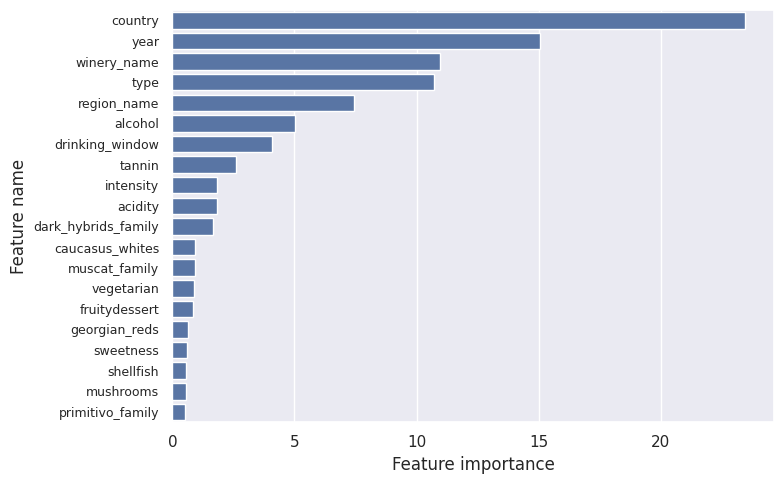

In [433]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="darkgrid")
sns.barplot(df_cat_reg_feat_imp.head(20), x="feat_imp", y="feat_name")
plt.yticks(fontsize=9)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.tight_layout()
plt.savefig('img/class_fimp_top20.jpg', dpi=300)

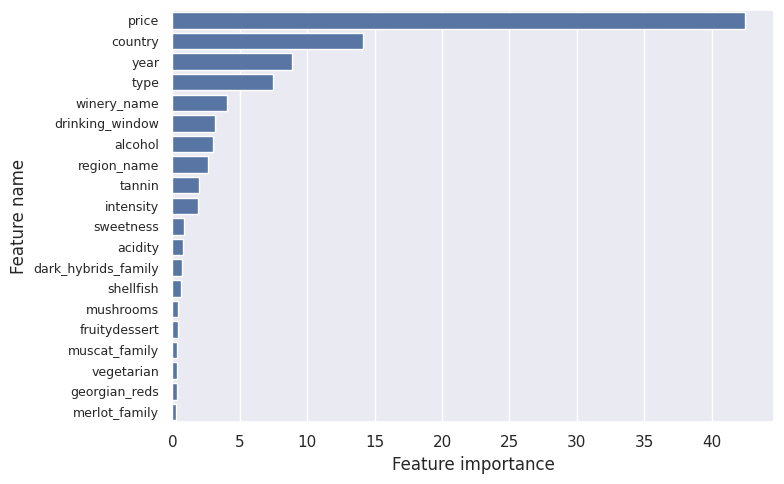

In [ ]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="darkgrid")
sns.barplot(df_cat_reg_feat_imp.head(20), x="feat_imp", y="feat_name")
plt.yticks(fontsize=9)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.tight_layout()
plt.savefig('img/reg_fimp_top20.jpg', dpi=300)

Among grapes, most influential

In [73]:
df_cat_reg_feat_imp['feat_name'].values

array(['country', 'year', 'winery_name', 'type', 'region_name', 'alcohol',
       'drinking_window', 'tannin', 'intensity', 'acidity',
       'dark_hybrids_family', 'caucasus_whites', 'muscat_family',
       'vegetarian', 'fruitydessert', 'georgian_reds', 'sweetness',
       'shellfish', 'mushrooms', 'primitivo_family', 'sauvignon_family',
       'fizziness', 'aperitif', 'goatcheese', 'pinot_noir_family', 'veal',
       'merlot_family', 'rabbit', 'italian_whites', 'hardcheese',
       'nebbiolo_family', 'sweetdessert', 'cabernet_franc_family',
       'softcheese', 'italian_reds', 'leanfish', 'tempranillo_family',
       'petit_manseng_family', 'cinsault_family', 'pasta',
       'cabernet_sauvignon_family', 'greek_whites', 'lamb', 'pork',
       'trebbiano_family', 'grenache_family', 'appetizers-snacks',
       'pinot_blanc_family', 'beef', 'southern_french_reds', 'spicyfood',
       'duck', 'curedmeat', 'volcanic_island_reds', 'syrah_family',
       'garganega_family', 'spanish_whites'

In [32]:
grapes_cols = ['dark_hybrids_family', 
        'muscat_family', 
       'georgian_reds', 'merlot_family',  
        'caucasus_whites', 'primitivo_family',
       'pinot_noir_family'
       'cabernet_franc_family', 'italian_whites', 'portuguese_reds',
       'sauvignon_family', 'italian_reds',
       'nebbiolo_family', 'gewurztraminer_family',
        'petit_manseng_family', 'grenache_family',
       'southern_french_reds', 
       'riesling_family', 'cabernet_sauvignon_family', 'gamay_family',
       'chardonnay_family', 'carignan_family', 'volcanic_island_reds',
       'hybrid_reds', 'greek_whites', 'trebbiano_family',
       'spanish_whites', 'iberian_atlantic_whites', 
       'iberian_reds', 'mourvedre_family', 'malbec_family',
       'viognier_family', 'hybrid_whites', 
       'portuguese_whites', 'zweigelt_family',
       'caucasus_reds', 'schiava_family', 'pinot_gris_family',
       'pinot_blanc_family', 'aglianico_family',
       'cinsault_family', 'syrah_family', 'garganega_family',
       'austrian_german_whites', 'semillon_family',
       'southern_french_whites', 'tempranillo_family', 
       'negroamaro_family', 'alpine_whites', 'atlantic_whites',
       'blaufrankisch_family', 'eastern_europe_whites',
       'colombard_folle_blanche_family', 'nero_davola_family',
       'lambrusco_family', 'chenin_blanc_family', 'greek_reds',
       'vermentino_family', 'teroldego_lagrein_family',
       'sagrantino_tannat_family', 'sangiovese_family']

food_col = ['shellfish', 'mushrooms', 'fruitydessert', 'chicken', 'veal',
            'vegetarian', 'softcheese', 'pasta', 'venison', 'hardcheese', 'rabbit',
             'sweetdessert', 'aperitif',  'lamb', 'curedmeat', 'beef',  'richfish', 'leanfish', 
             'appetizers-snacks', 'pork', 'bluecheese', 'junkfood', 'goatcheese', 'spicyfood','duck']

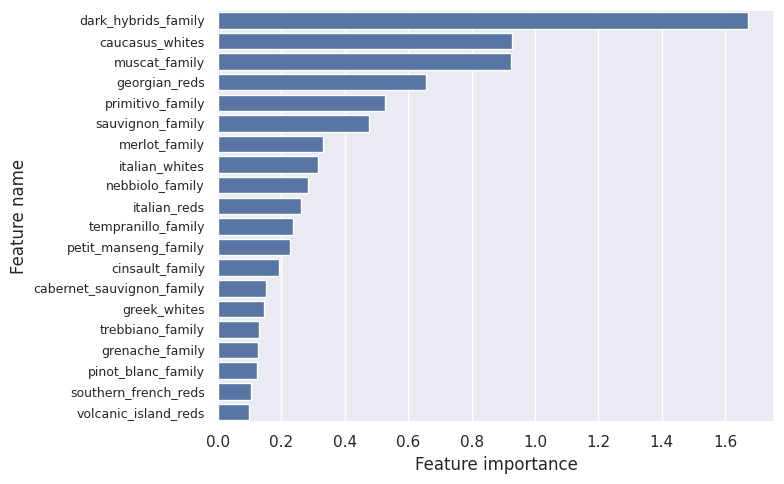

In [437]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="darkgrid")
sns.barplot(df_cat_reg_feat_imp[df_cat_reg_feat_imp['feat_name'].isin(grapes_cols)].head(20), x="feat_imp", y="feat_name")
plt.yticks(fontsize=9)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.tight_layout()
plt.savefig('img/class_fimp_grapes_top20.jpg', dpi=300)

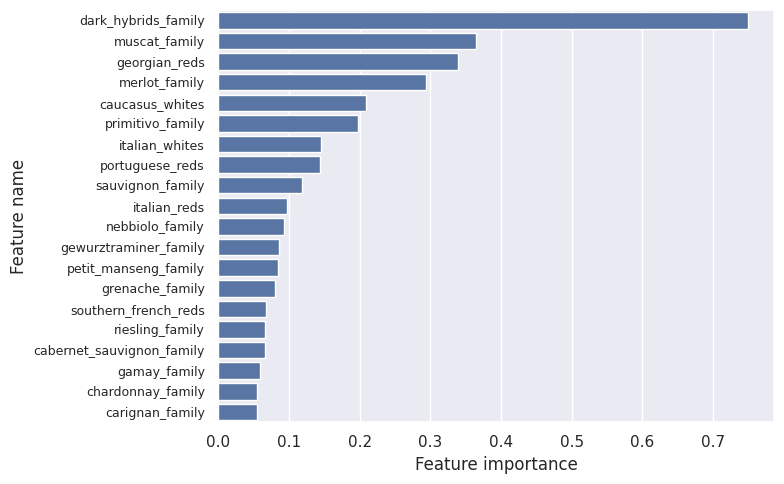

In [72]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="darkgrid")
sns.barplot(df_cat_reg_feat_imp[df_cat_reg_feat_imp['feat_name'].isin(grapes_cols)].head(20), x="feat_imp", y="feat_name")
plt.yticks(fontsize=9)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.tight_layout()
plt.savefig('img/reg_fimp_grapes_top20.jpg', dpi=300)

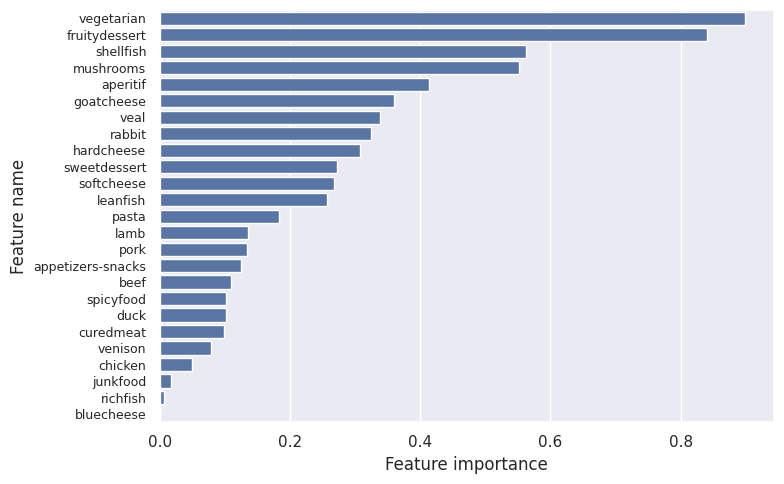

In [439]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="darkgrid")
sns.barplot(df_cat_reg_feat_imp[df_cat_reg_feat_imp['feat_name'].isin(food_col)], x="feat_imp", y="feat_name")
plt.yticks(fontsize=9)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.tight_layout()
plt.savefig('img/class_fimp_food.jpg', dpi=300)

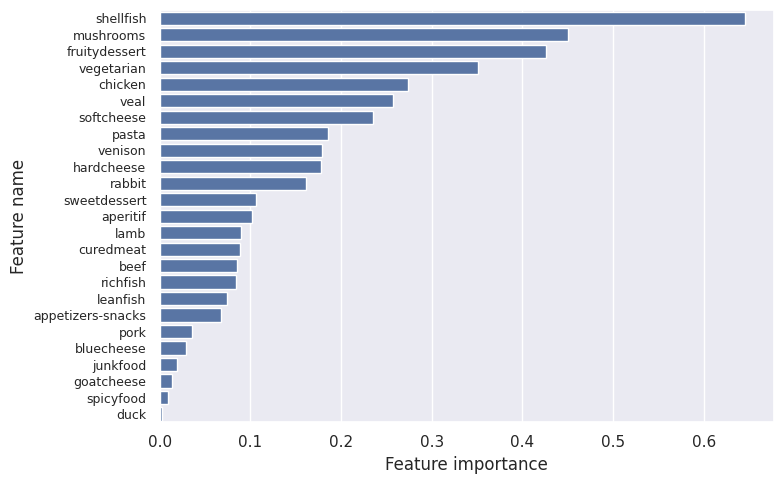

In [76]:
plt.figure(figsize=(8, 5))
sns.set_theme(style="darkgrid")
sns.barplot(df_cat_reg_feat_imp[df_cat_reg_feat_imp['feat_name'].isin(food_col)], x="feat_imp", y="feat_name")
plt.yticks(fontsize=9)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.tight_layout()
plt.savefig('img/reg_fimp_food.jpg', dpi=300)

## SHAP values

In [73]:
train.columns, test.columns, train.shape, test.shape

(Index(['type', 'year', 'country', 'region_name', 'winery_name', 'intensity',
        'sweetness', 'acidity', 'tannin', 'fizziness', 'alcohol',
        'drinking_window', 'food_filt', 'grapes_merged', 'price',
        'mean_rating'],
       dtype='object'),
 Index(['type', 'year', 'country', 'region_name', 'winery_name', 'intensity',
        'sweetness', 'acidity', 'tannin', 'fizziness', 'alcohol',
        'drinking_window', 'food_filt', 'grapes_merged', 'price',
        'mean_rating'],
       dtype='object'),
 (37315, 16),
 (9329, 16))

In [74]:
taste_cols = ['sweetness', 'acidity', 'tannin', 'fizziness','intensity',]

In [75]:
import shap 

# transforme the dataset 
# train_transformed, test_transformed = cust_model_cat.transform(train).drop(columns=["mean_rating", "price"]), cust_model_cat.transform(test).drop(columns=["mean_rating", "price"])
train_transformed, test_transformed = cust_model_cat.transform(train).drop(columns=["mean_rating"]), cust_model_cat.transform(test).drop(columns=["mean_rating"])

In [76]:
explainer = shap.TreeExplainer(cust_model_cat.model)
explanation = explainer(test_transformed)

In [77]:
explanation

.values =
array([[ 3.15931667e-04,  5.18395148e-04,  1.27868340e-03, ...,
        -3.27297643e-03,  8.31246509e-03,  1.95239343e-01],
       [-1.95546134e-04,  8.54081420e-04, -4.61484281e-04, ...,
        -2.49514733e-03, -2.48917503e-03,  6.34422465e-02],
       [ 1.41472522e-04,  2.85044252e-04, -1.11316697e-03, ...,
        -3.30532697e-03, -2.09892126e-03,  5.77449972e-02],
       ...,
       [ 1.85777821e-04,  3.00654783e-04,  1.73774761e-03, ...,
         1.67324598e-02,  7.56737422e-03,  5.50349847e-02],
       [ 1.45714782e-03,  1.55764248e-03,  7.32060435e-05, ...,
         5.42418229e-03, -3.28789255e-03, -8.66346153e-02],
       [ 4.08756234e-04,  1.92232481e-03, -5.64817504e-04, ...,
         8.84830181e-05,  2.96861555e-02,  5.58824435e-02]],
      shape=(9329, 99))

.base_values =
array([3.79528824, 3.79528824, 3.79528824, ..., 3.79528824, 3.79528824,
       3.79528824], shape=(9329,))

.data =
array([[0, 0, 1, ..., 13.5, 12.0, 730.0],
       [0, 0, 0, ..., nan, 8.0, 57.

All categories

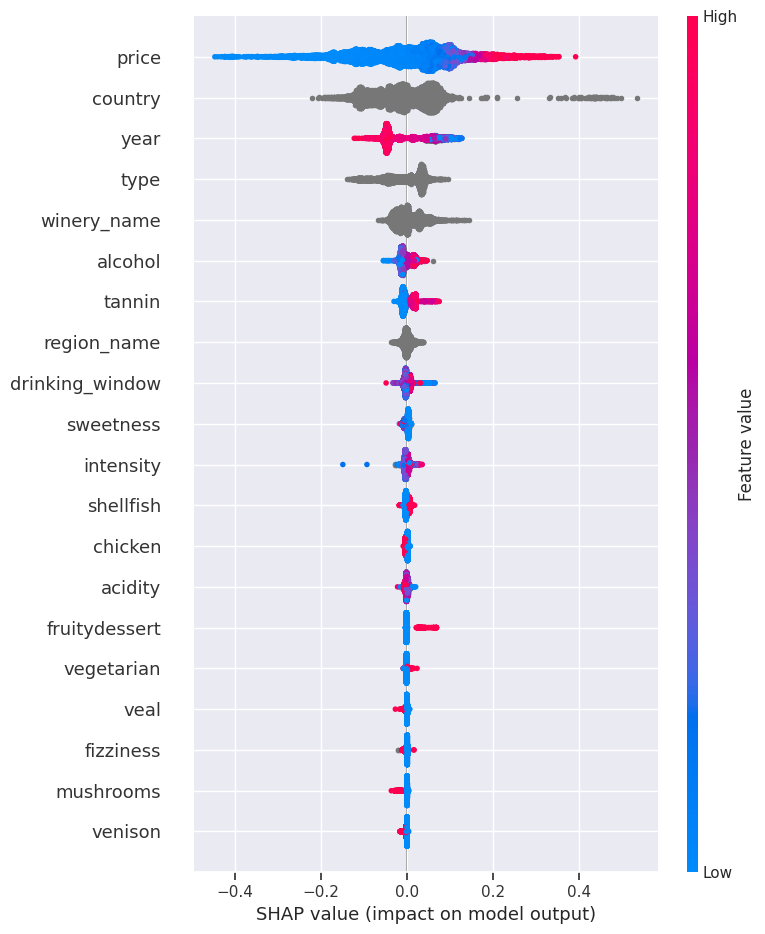

In [78]:
shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values, test_transformed, show=False)
plt.savefig('img/shap_class_all_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

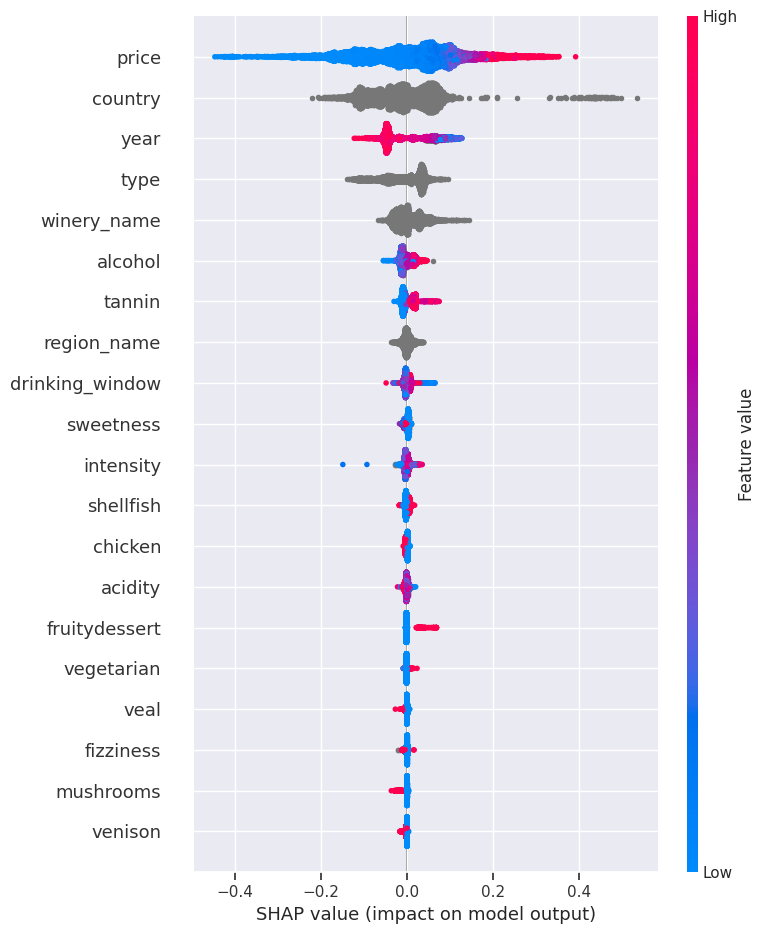

In [79]:
shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values, test_transformed, show=False)
plt.savefig('img/shap_all_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

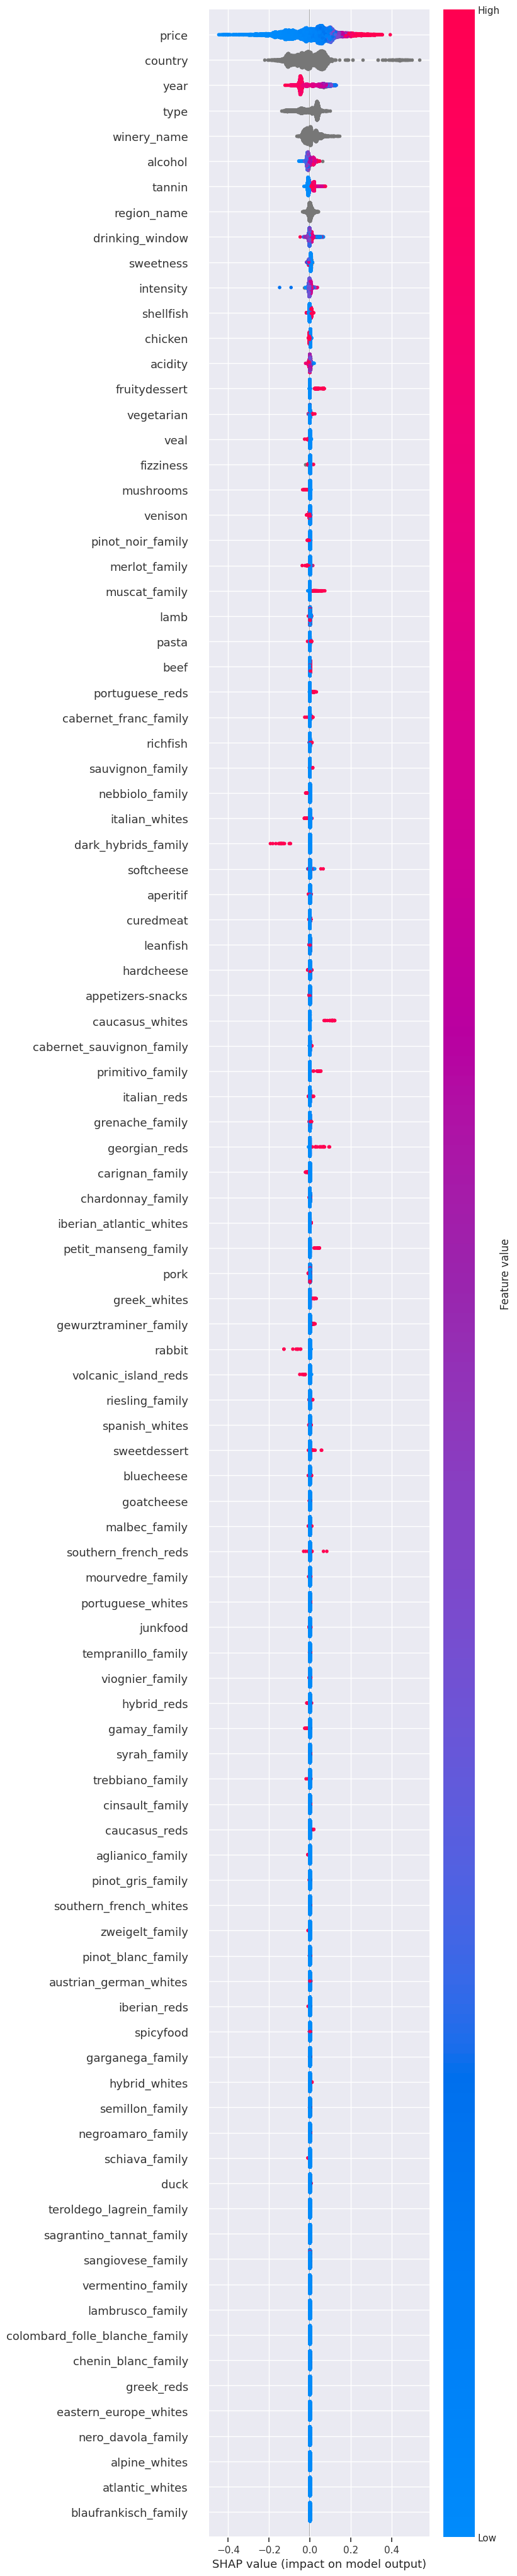

In [80]:
# all feat

shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values, test_transformed, show=False,  max_display=len(test_transformed.columns))
# plt.savefig('img/shap_all.jpg', dpi = 300, bbox_inches='tight')
plt.show()

Tastes 


In [81]:
taste_cols

['sweetness', 'acidity', 'tannin', 'fizziness', 'intensity']

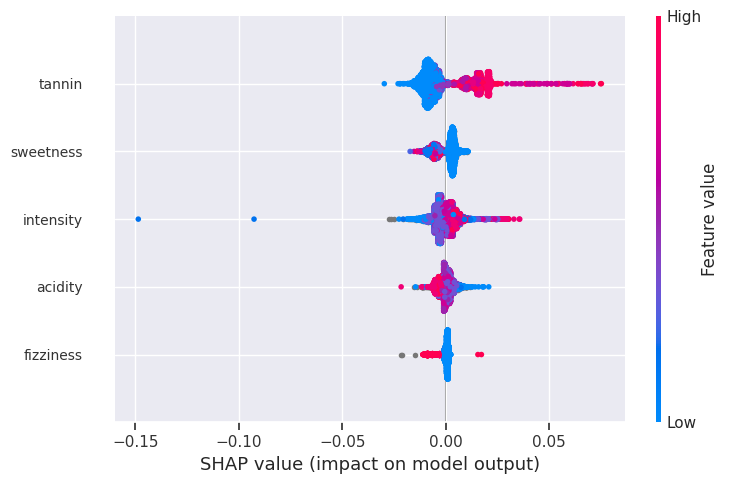

In [82]:
selected_features = taste_cols
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

sns.set_theme(style="darkgrid")
shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False, plot_size=[8, 5])
plt.tight_layout()
plt.yticks(fontsize=10)
plt.savefig('img/shap/reg_taste_shap.jpg', dpi = 300, bbox_inches='tight')
plt.show()

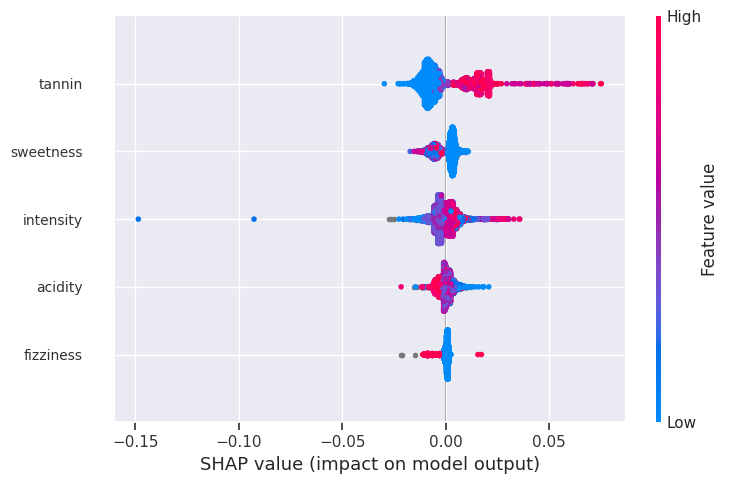

In [83]:
# class
selected_features = taste_cols
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

sns.set_theme(style="darkgrid")
shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False, plot_size=[8, 5])
plt.tight_layout()
plt.yticks(fontsize=10)
# plt.savefig('img/shap/class_taste_shap.jpg', dpi = 300, bbox_inches='tight')
plt.show()

In [84]:
test_transformed.columns

Index(['aperitif', 'appetizers-snacks', 'beef', 'bluecheese', 'chicken',
       'curedmeat', 'duck', 'fruitydessert', 'goatcheese', 'hardcheese',
       'junkfood', 'lamb', 'leanfish', 'mushrooms', 'pasta', 'pork', 'rabbit',
       'richfish', 'shellfish', 'softcheese', 'spicyfood', 'sweetdessert',
       'veal', 'vegetarian', 'venison', 'aglianico_family', 'alpine_whites',
       'atlantic_whites', 'austrian_german_whites', 'blaufrankisch_family',
       'cabernet_franc_family', 'cabernet_sauvignon_family', 'carignan_family',
       'caucasus_reds', 'caucasus_whites', 'chardonnay_family',
       'chenin_blanc_family', 'cinsault_family',
       'colombard_folle_blanche_family', 'dark_hybrids_family',
       'eastern_europe_whites', 'gamay_family', 'garganega_family',
       'georgian_reds', 'gewurztraminer_family', 'greek_reds', 'greek_whites',
       'grenache_family', 'hybrid_reds', 'hybrid_whites',
       'iberian_atlantic_whites', 'iberian_reds', 'italian_reds',
       'italian_whi

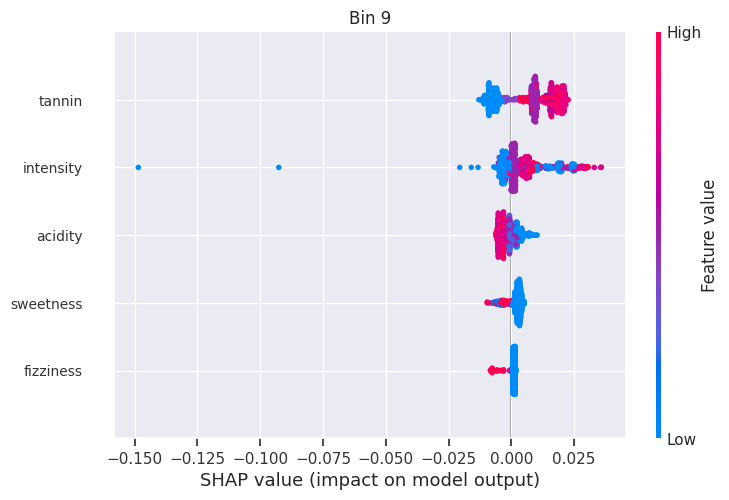

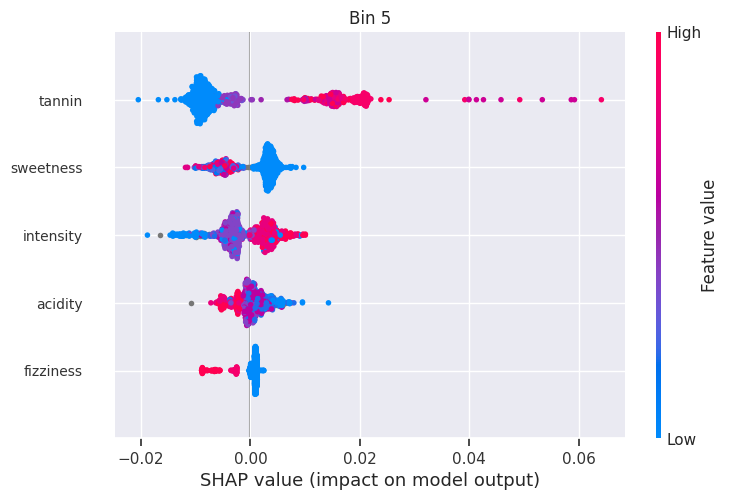

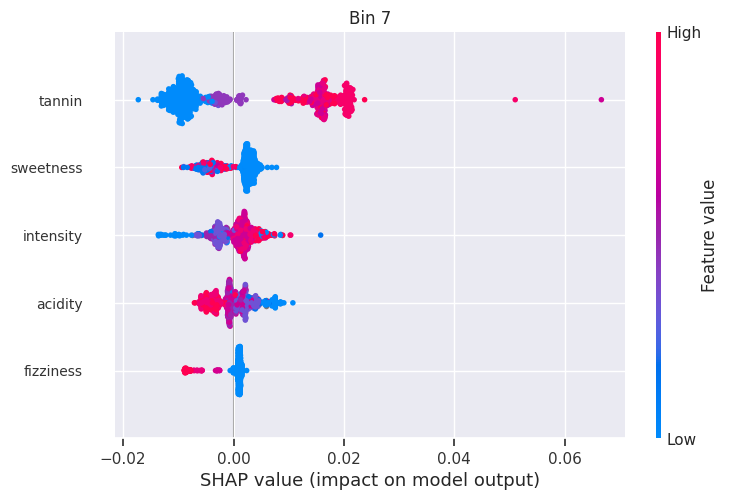

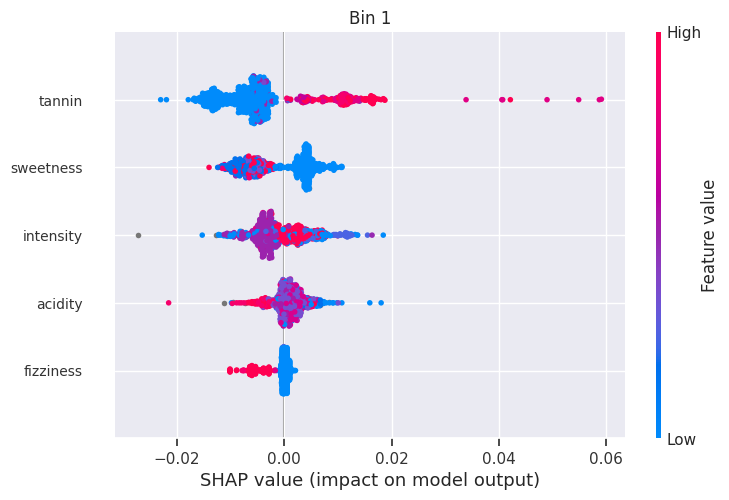

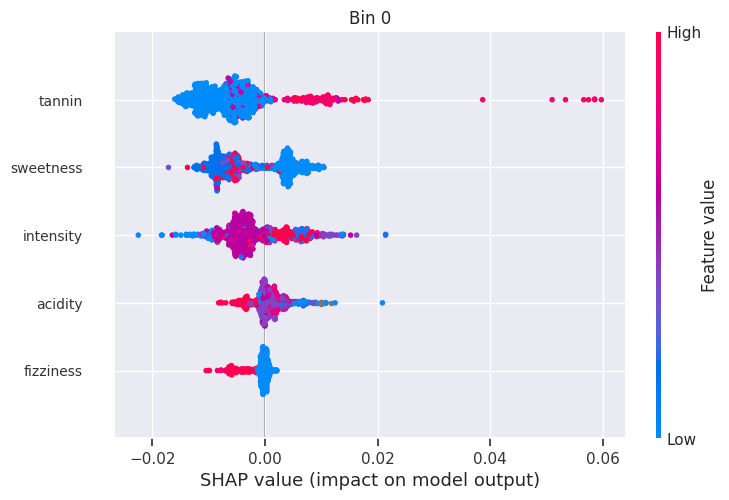

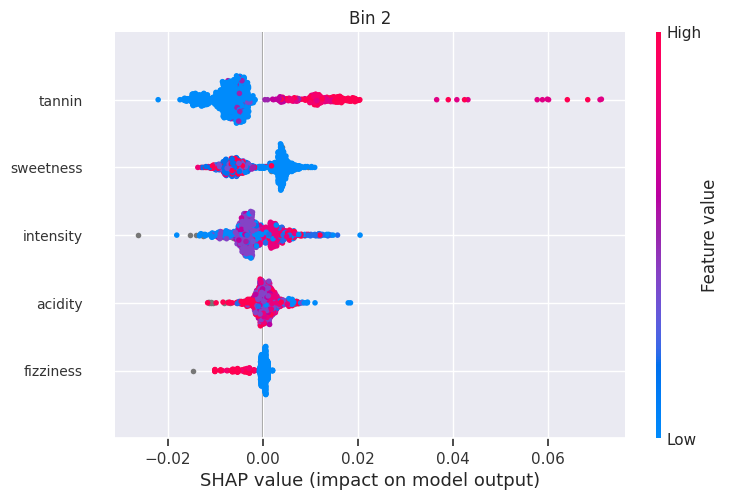

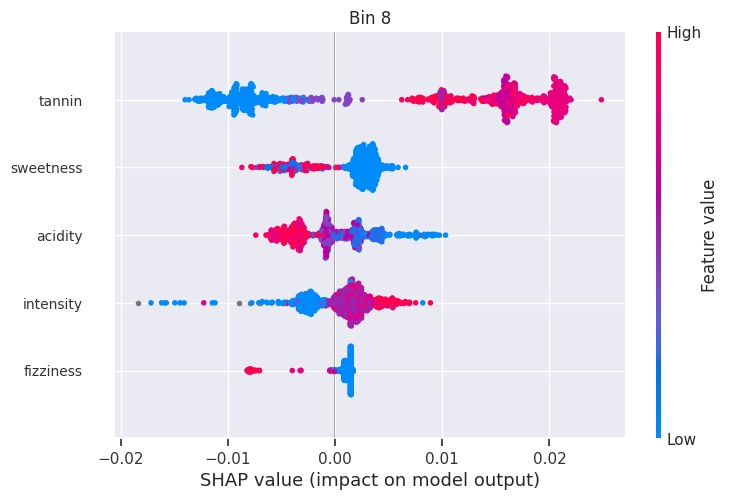

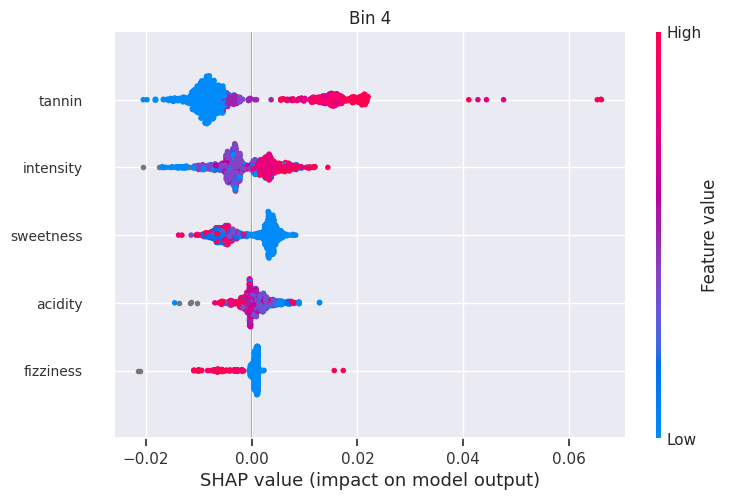

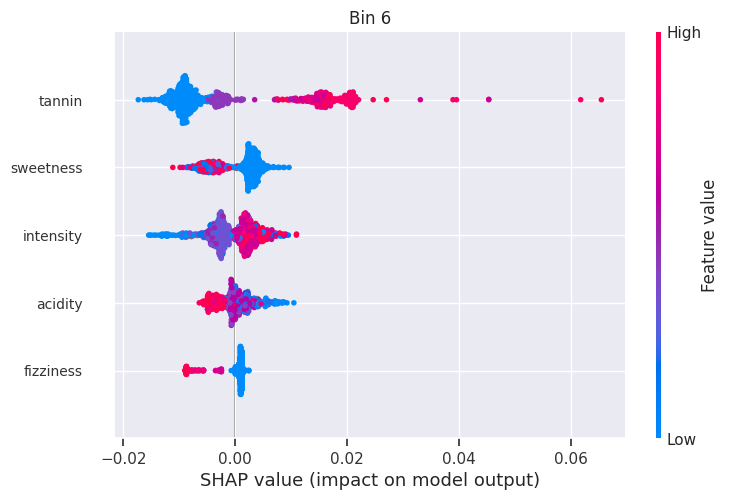

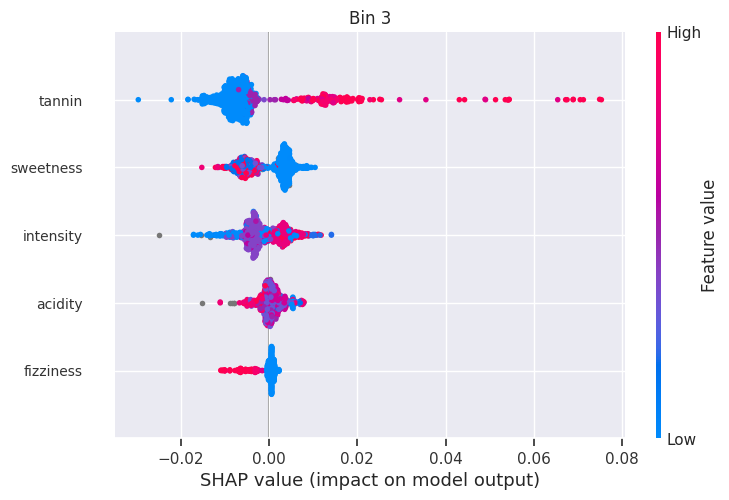

In [85]:
# per bins
# class
selected_features = taste_cols
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap_values = explainer.shap_values(test_transformed)
sns.set_theme(style="darkgrid")

for b in df_test_end['bins'].unique():
    idx = np.where(df_test_end['bins'] == b)[0]
    shap.summary_plot(shap_values[idx][:, feature_idx], test_transformed[df_test_end['bins'] == b].iloc[:, feature_idx], show=False, plot_size=[8, 5])
    plt.tight_layout()
    plt.yticks(fontsize=10)
    plt.title(f"Bin {b}")
    # plt.savefig('img/shap/class_taste_shap.jpg', dpi = 300, bbox_inches='tight')
    plt.show()

#### Dependancy plots

In [86]:
test_transformed.columns

Index(['aperitif', 'appetizers-snacks', 'beef', 'bluecheese', 'chicken',
       'curedmeat', 'duck', 'fruitydessert', 'goatcheese', 'hardcheese',
       'junkfood', 'lamb', 'leanfish', 'mushrooms', 'pasta', 'pork', 'rabbit',
       'richfish', 'shellfish', 'softcheese', 'spicyfood', 'sweetdessert',
       'veal', 'vegetarian', 'venison', 'aglianico_family', 'alpine_whites',
       'atlantic_whites', 'austrian_german_whites', 'blaufrankisch_family',
       'cabernet_franc_family', 'cabernet_sauvignon_family', 'carignan_family',
       'caucasus_reds', 'caucasus_whites', 'chardonnay_family',
       'chenin_blanc_family', 'cinsault_family',
       'colombard_folle_blanche_family', 'dark_hybrids_family',
       'eastern_europe_whites', 'gamay_family', 'garganega_family',
       'georgian_reds', 'gewurztraminer_family', 'greek_reds', 'greek_whites',
       'grenache_family', 'hybrid_reds', 'hybrid_whites',
       'iberian_atlantic_whites', 'iberian_reds', 'italian_reds',
       'italian_whi

In [87]:
np.sort(test_transformed['year'].unique())

array([1925., 1926., 1927., 1928., 1930., 1932., 1933., 1936., 1939.,
       1940., 1941., 1942., 1944., 1946., 1947., 1949., 1952., 1954.,
       1955., 1956., 1957., 1959., 1960., 1961., 1962., 1963., 1964.,
       1965., 1966., 1967., 1969., 1970., 1971., 1972., 1974., 1975.,
       1976., 1978., 1979., 1980., 1981., 1982., 1983., 1984., 1985.,
       1986., 1987., 1988., 1989., 1990., 1991., 1992., 1993., 1994.,
       1995., 1996., 1997., 1998., 1999., 2000., 2001., 2002., 2003.,
       2004., 2005., 2006., 2007., 2008., 2009., 2010., 2011., 2012.,
       2013., 2014., 2015., 2016., 2017., 2018., 2019., 2020., 2021.,
       2022., 2023., 2024., 2025.,   nan])

In [88]:
taste_cols

['sweetness', 'acidity', 'tannin', 'fizziness', 'intensity']

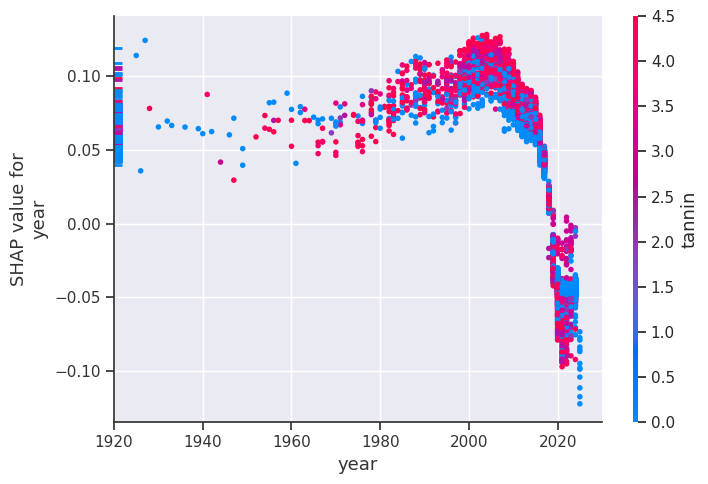

In [89]:
sns.set_theme(style="darkgrid")

shap.dependence_plot("year", shap_values, test_transformed, interaction_index="tannin", show=False)
plt.tight_layout()
# plt.savefig("img/shap/class_price_year_shap.jpg", dpi = 300)
plt.show()

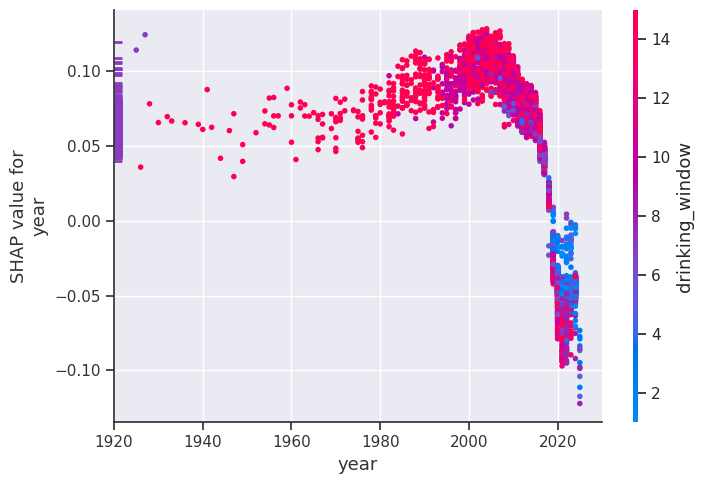

In [90]:
sns.set_theme(style="darkgrid")

shap.dependence_plot("year", shap_values, test_transformed, interaction_index="drinking_window", show=False)
plt.tight_layout()
# plt.savefig("img/shap/class_price_year_shap.jpg", dpi = 300)
plt.show()

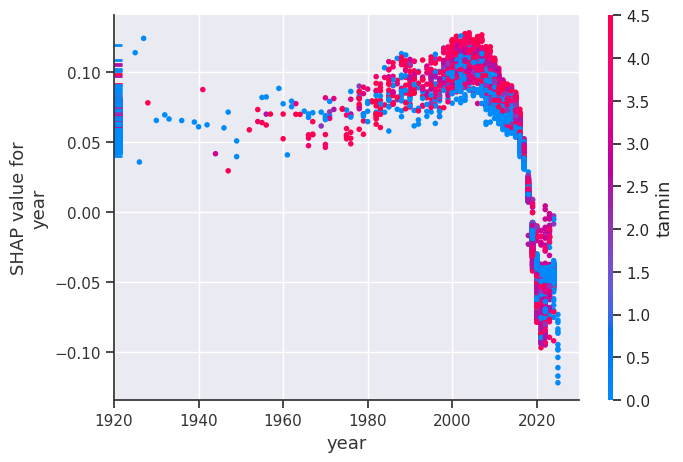

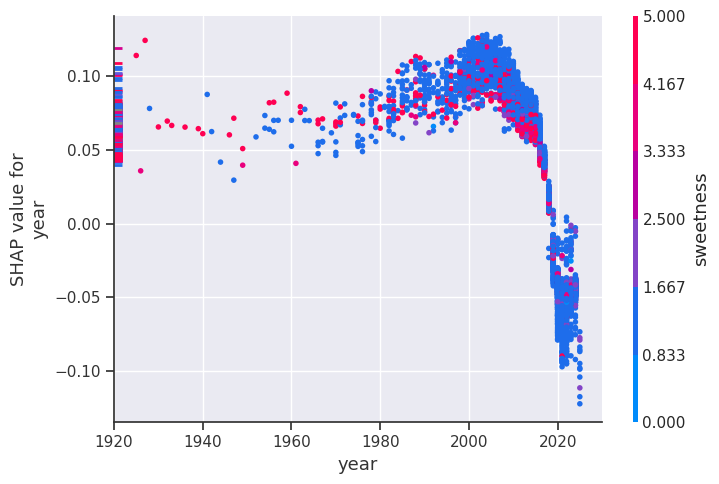

In [91]:
sns.set_theme(style="darkgrid")

shap.dependence_plot("year", shap_values, test_transformed, interaction_index="tannin", show=False)
shap.dependence_plot("year", shap_values, test_transformed, interaction_index="sweetness", show=False)
plt.tight_layout()
# plt.savefig("img/shap/class_price_year_shap.jpg", dpi = 300)
plt.show()

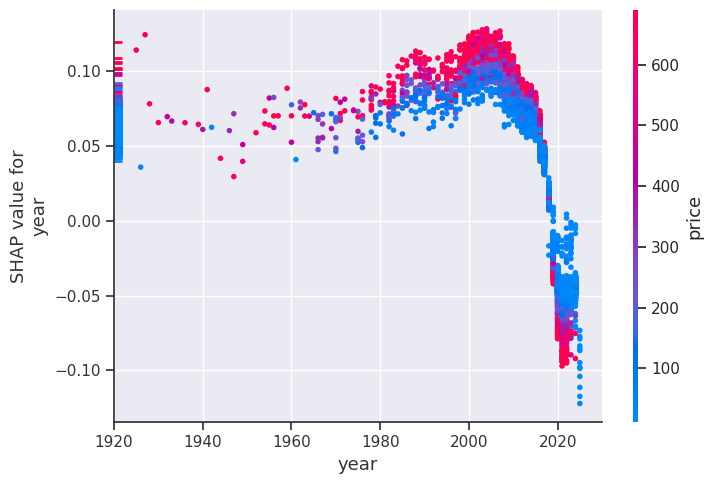

In [92]:
sns.set_theme(style="darkgrid")

shap.dependence_plot("year", shap_values, test_transformed, interaction_index="price", show=False)
plt.tight_layout()
plt.savefig("img/shap/class_price_year_shap.jpg", dpi = 300)
plt.show()

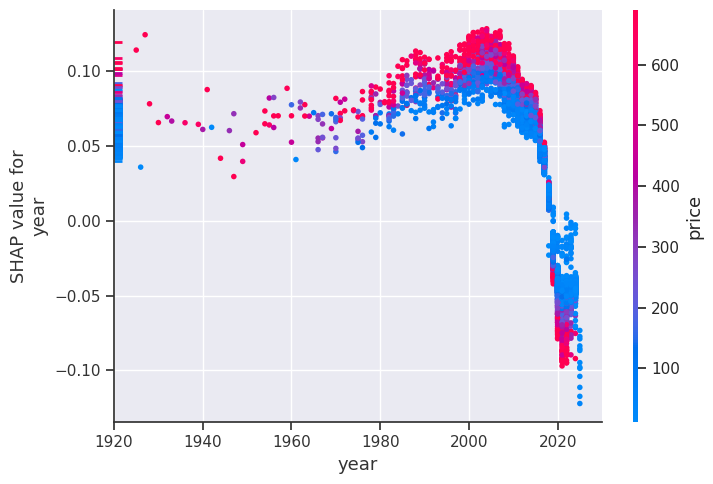

In [93]:
shap.dependence_plot("year", shap_values, test_transformed, interaction_index="price", show=False)
plt.tight_layout()
plt.savefig("img/shap/reg_price_year_shap.jpg", dpi = 300)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

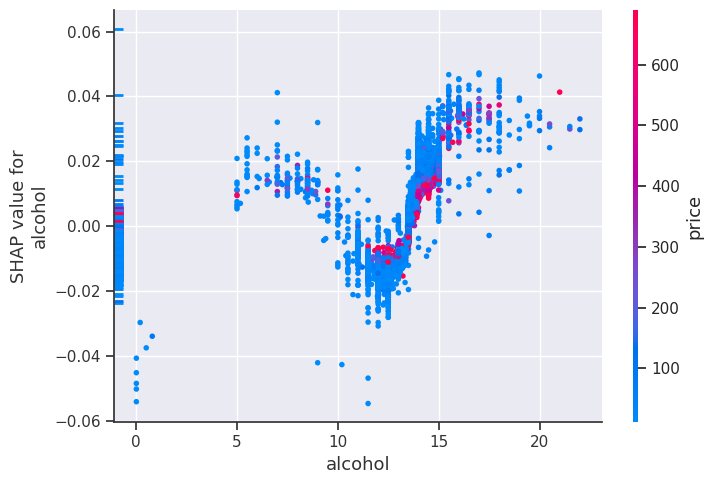

In [94]:
shap.dependence_plot("alcohol", shap_values, test_transformed, interaction_index="price", show=False)
plt.tight_layout()
plt.savefig("img/shap/class_price_alc_shap.jpg", dpi = 300)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

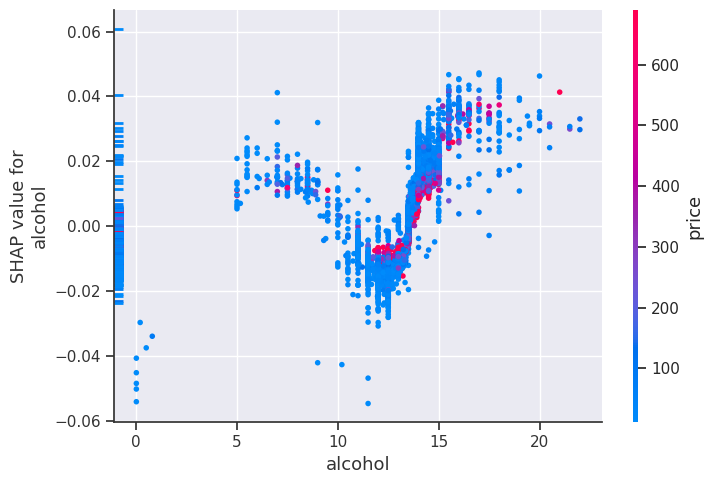

In [95]:
shap.dependence_plot("alcohol", shap_values, test_transformed, interaction_index="price", show=False)
plt.tight_layout()
# plt.savefig("img/shap/reg_price_alc_shap.jpg", dpi = 300)
plt.show

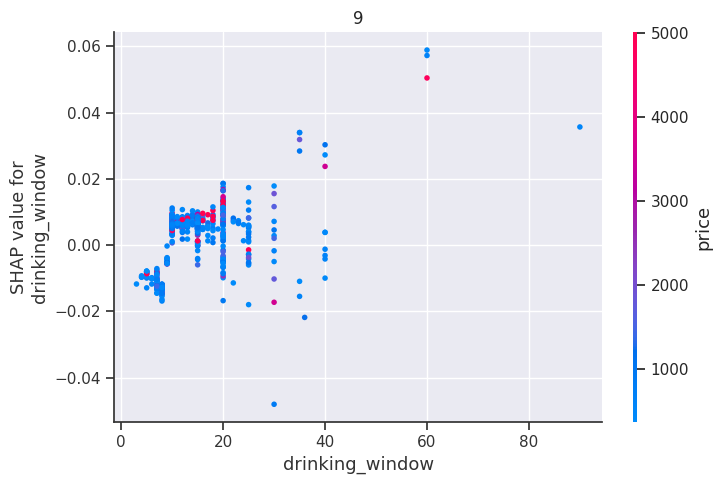

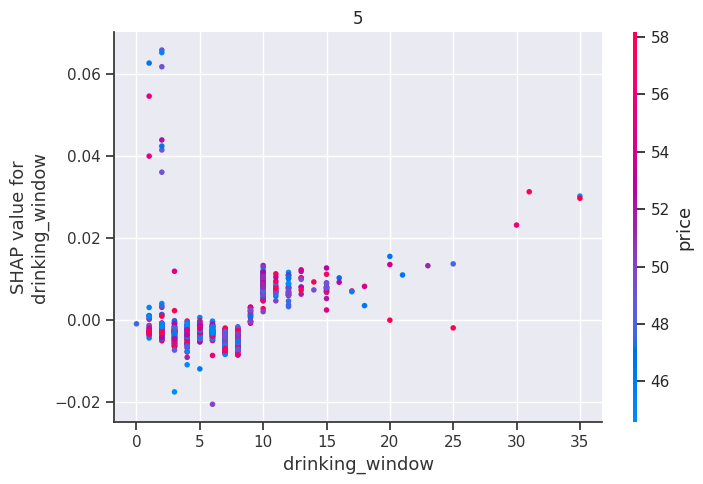

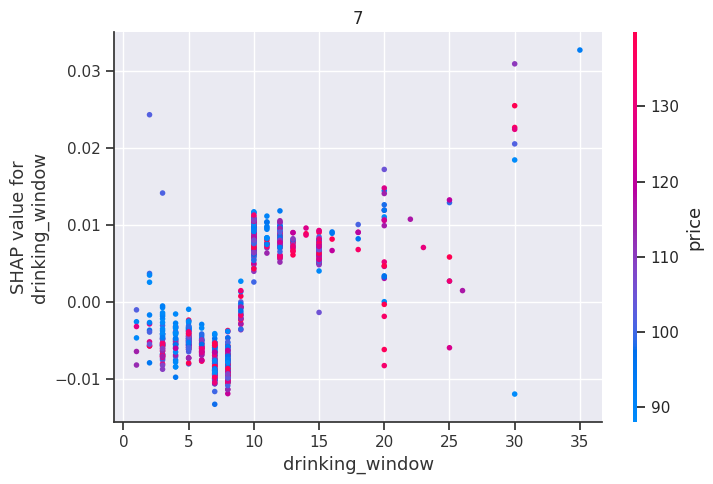

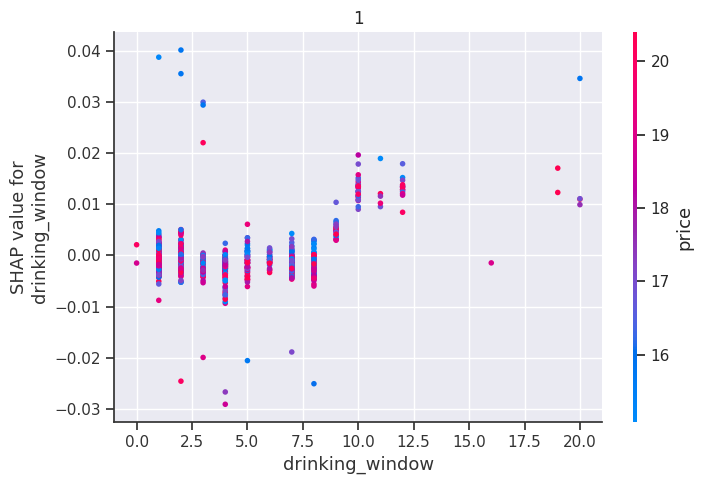

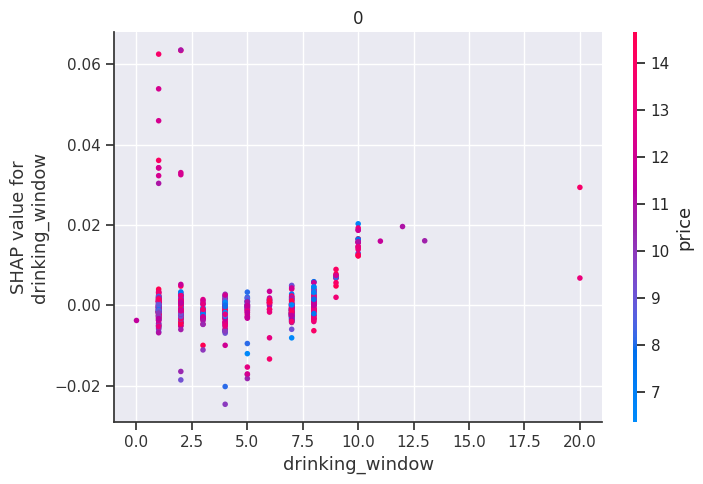

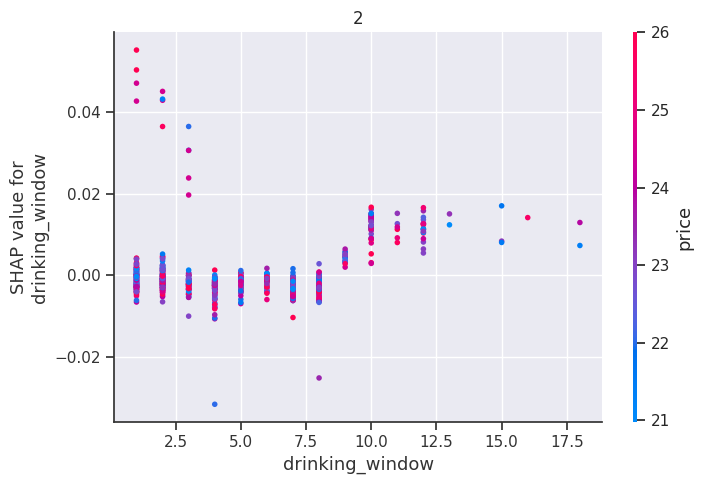

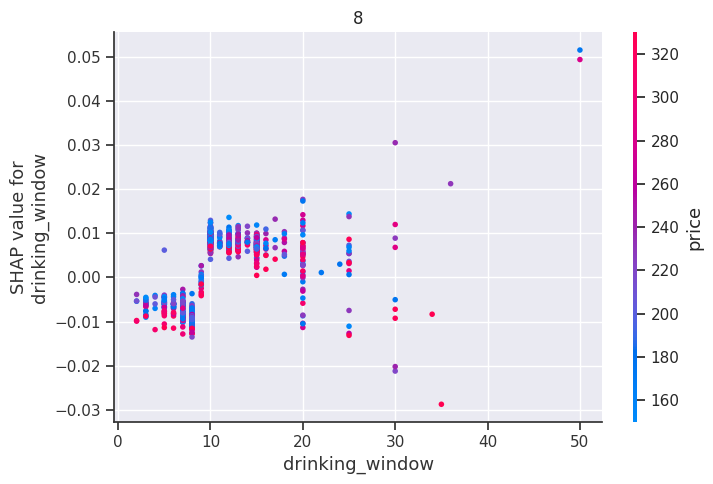

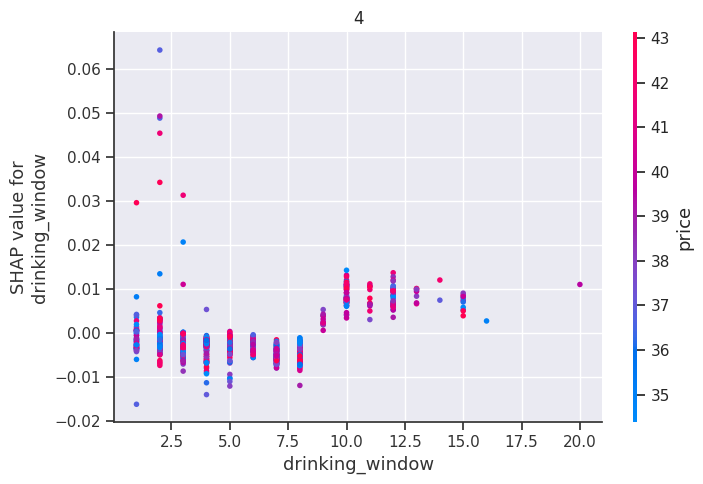

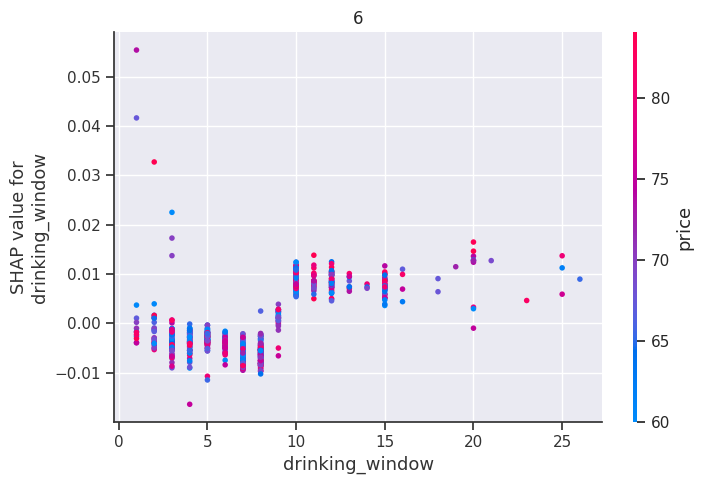

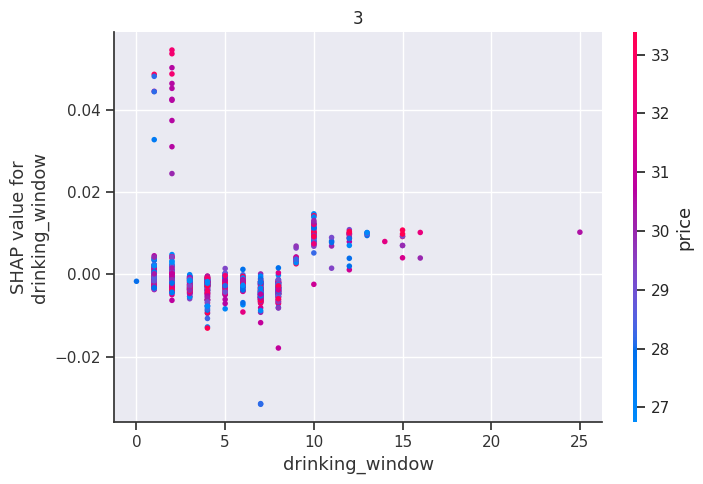

In [96]:
# checking for different bins
for bin_label in df_test_end['bins'].unique():
    # Filter data for the current bin
    mask = df_test_end['bins'] == bin_label
    X_bin = test_transformed[mask]
    shap_bin = shap_values[mask]
    
    # Create SHAP dependence plot for this bin
    shap.dependence_plot(
        "drinking_window",        # feature to plot
        shap_bin,                # shap values for this bin
        X_bin,                   # features for this bin
        interaction_index="price",
        show=False
    )
    plt.title(bin_label)
    
    plt.tight_layout()
    # plt.savefig(f"img/shap/class_wind_price_shap_bin_{bin_label}.jpg", dpi=300)
    plt.show()

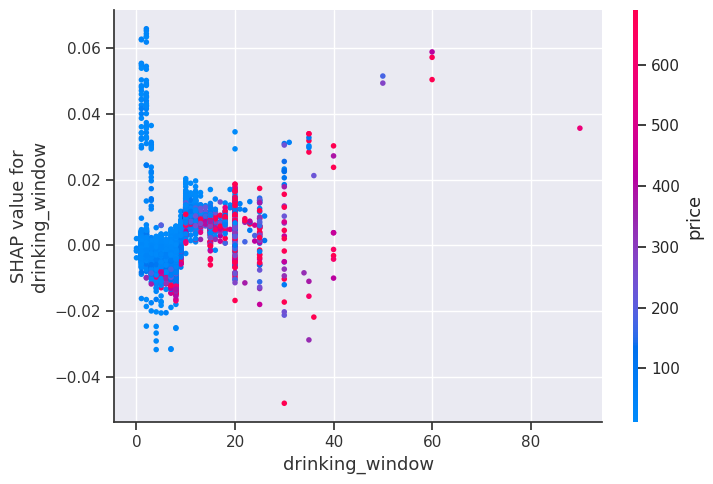

In [97]:
shap.dependence_plot("drinking_window", shap_values, test_transformed, interaction_index="price", show=False)
plt.tight_layout()
plt.savefig("img/shap/class_wind_price_shap.jpg", dpi = 300)
plt.show()

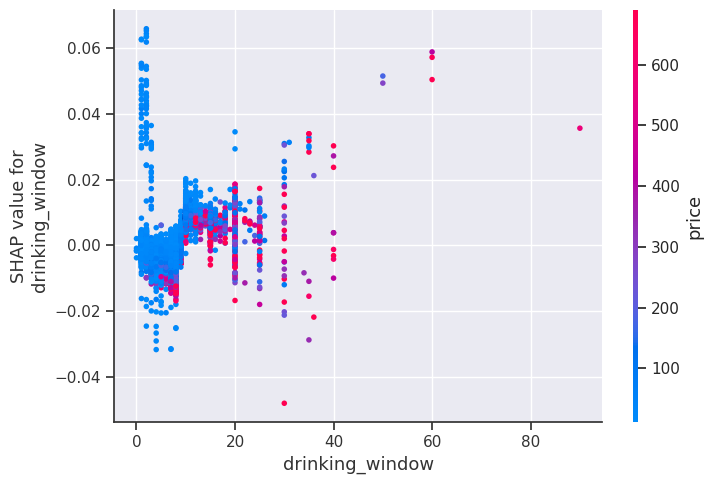

In [98]:

shap.dependence_plot("drinking_window", shap_values, test_transformed, interaction_index="price", show=False)
plt.tight_layout()
plt.savefig("img/shap/reg_wind_price_shap.jpg", dpi = 300)
plt.show()

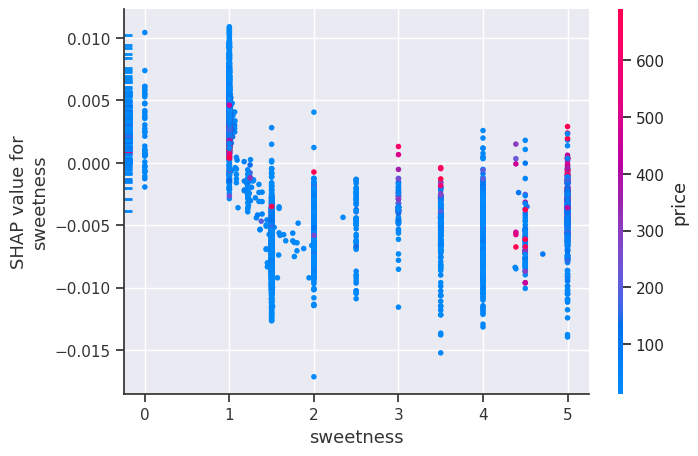

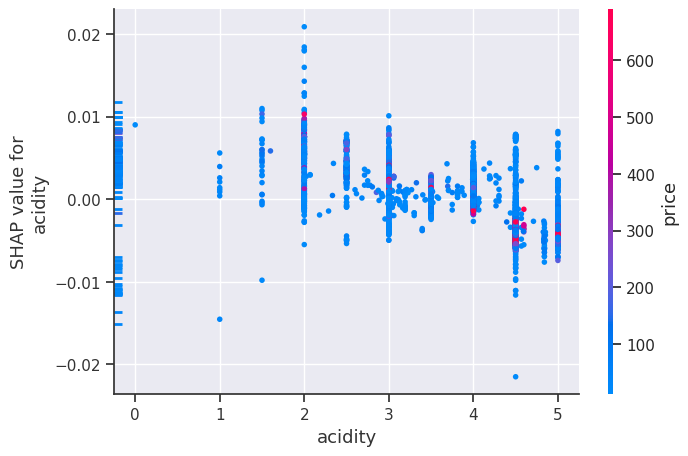

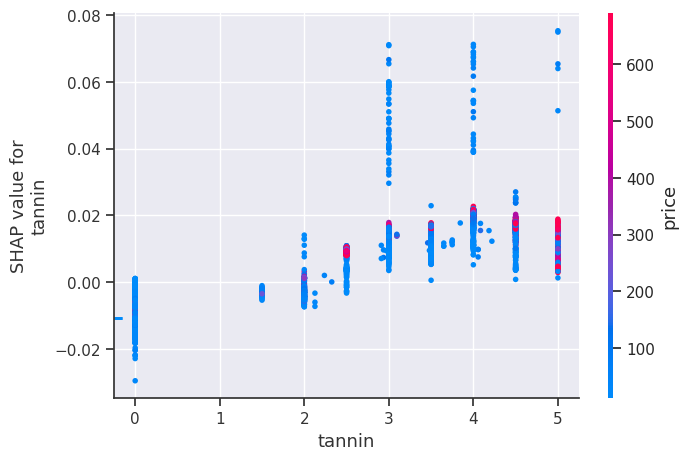

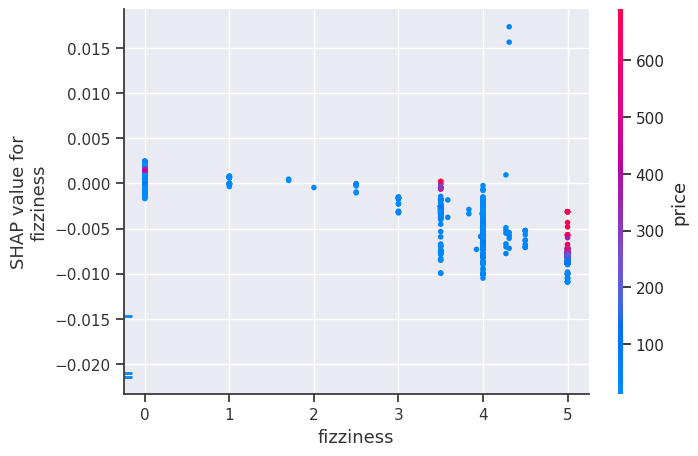

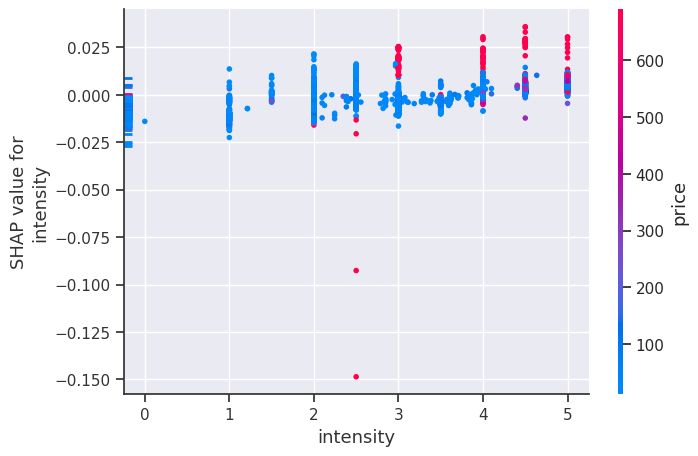

<Figure size 640x480 with 0 Axes>

In [99]:
for t in taste_cols:
    shap.dependence_plot(t, shap_values, test_transformed, interaction_index="price")
plt.tight_layout()
# plt.savefig("img/shap/reg_price_alc_shap.jpg", dpi = 300)

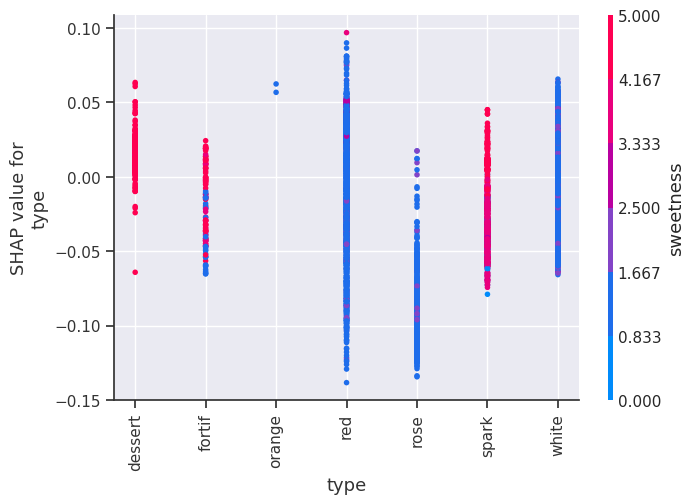

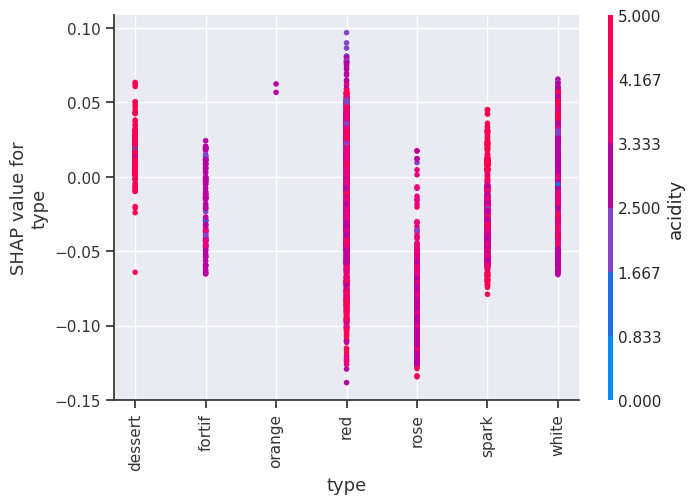

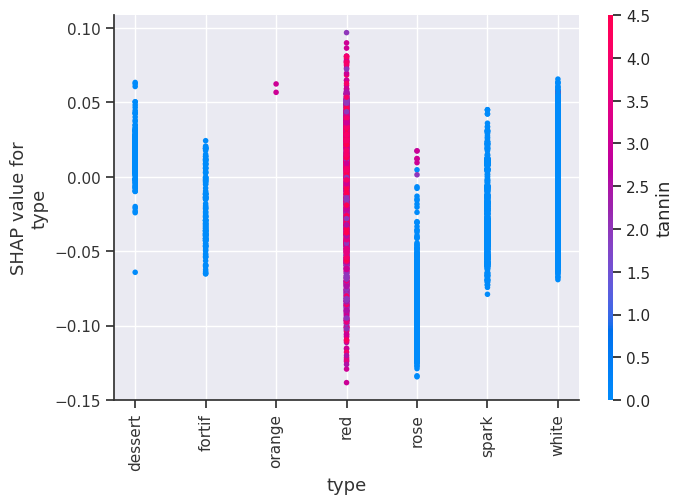

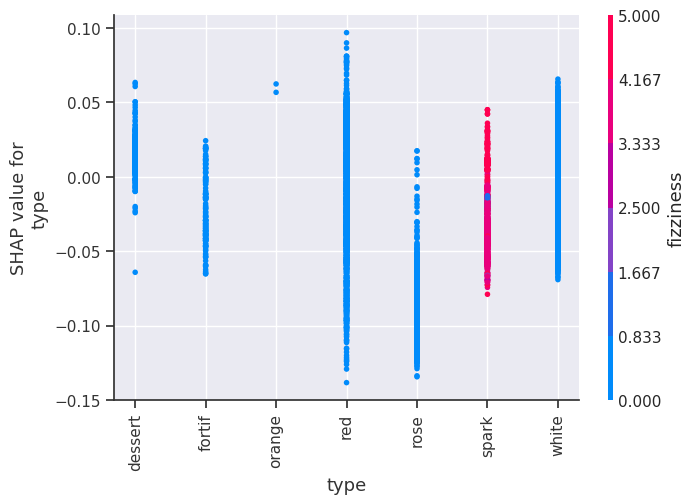

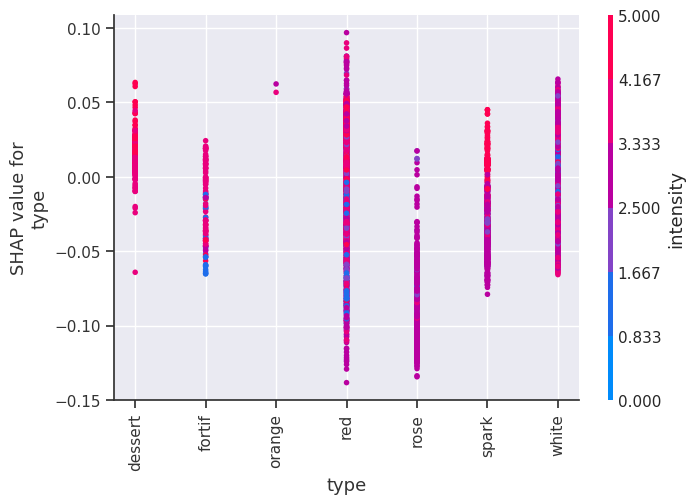

In [100]:
for t in taste_cols:
    shap.dependence_plot("type", shap_values, test_transformed, interaction_index=t)

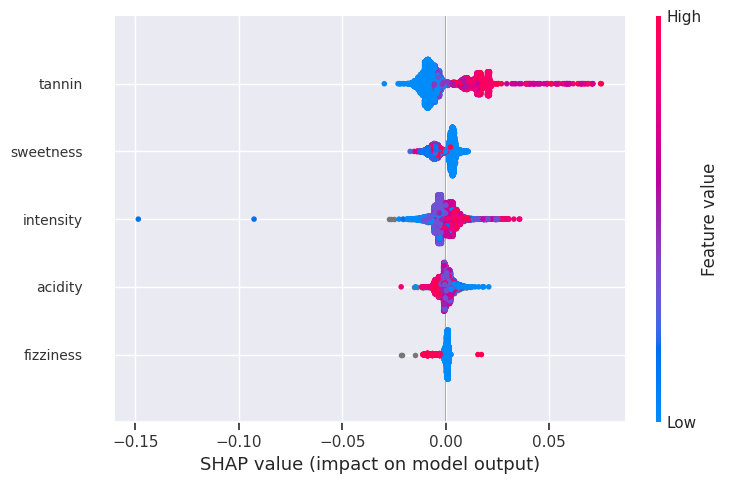

In [101]:
selected_features = taste_cols
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

sns.set_theme(style="darkgrid")
shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False, plot_size=[8, 5])
plt.tight_layout()
plt.yticks(fontsize=10)
plt.show()

In [102]:
mask.values.astype(int)

array([0, 0, 0, ..., 0, 0, 0], shape=(9329,))

In [103]:
# mask = test_transformed["type"] == "red"
shap_values[mask.values.astype(int)][:, feature_idx]


array([[ 0.00343823, -0.00511818,  0.0091618 ,  0.00081706, -0.00246139],
       [ 0.00343823, -0.00511818,  0.0091618 ,  0.00081706, -0.00246139],
       [ 0.00343823, -0.00511818,  0.0091618 ,  0.00081706, -0.00246139],
       ...,
       [ 0.00343823, -0.00511818,  0.0091618 ,  0.00081706, -0.00246139],
       [ 0.00343823, -0.00511818,  0.0091618 ,  0.00081706, -0.00246139],
       [ 0.00343823, -0.00511818,  0.0091618 ,  0.00081706, -0.00246139]],
      shape=(9329, 5))

In [104]:
feature_idx, shap_values

([92, 93, 94, 95, 91],
 array([[ 3.15931667e-04,  5.18395148e-04,  1.27868340e-03, ...,
         -3.27297643e-03,  8.31246509e-03,  1.95239343e-01],
        [-1.95546134e-04,  8.54081420e-04, -4.61484281e-04, ...,
         -2.49514733e-03, -2.48917503e-03,  6.34422465e-02],
        [ 1.41472522e-04,  2.85044252e-04, -1.11316697e-03, ...,
         -3.30532697e-03, -2.09892126e-03,  5.77449972e-02],
        ...,
        [ 1.85777821e-04,  3.00654783e-04,  1.73774761e-03, ...,
          1.67324598e-02,  7.56737422e-03,  5.50349847e-02],
        [ 1.45714782e-03,  1.55764248e-03,  7.32060435e-05, ...,
          5.42418229e-03, -3.28789255e-03, -8.66346153e-02],
        [ 4.08756234e-04,  1.92232481e-03, -5.64817504e-04, ...,
          8.84830181e-05,  2.96861555e-02,  5.58824435e-02]],
       shape=(9329, 99)))

In [105]:
wines.groupby("region_name")['region_name'].count().sort_values()

region_name
Alsace Grand Cru 'Engelberg'                     1
Alsace Grand Cru 'Eichberg'                      1
Alsace Grand Cru 'Altenberg de Bergbieten'       1
Wine of Georgia                                  1
Coteaux du Layon 'Saint-Aubin-de-Luigne'         1
                                              ... 
Ribera del Duero                               866
Rioja                                          959
Willamette Valley                              975
Pfalz                                         1003
Champagne                                     1132
Name: region_name, Length: 1395, dtype: int64

In [106]:
wines[wines["region_name"]=="Vipava"].shape, wines[wines["country"]=="Moldova"].shape

((7, 25), (14, 25))

In [107]:
wine_type_column = test_transformed['type'].unique()
feature_idx = [test_transformed.columns.get_loc(f) for f in taste_cols]

# Initialize data frame to store both mean SHAP and mean absolute SHAP values
shap_values_matrix = pd.DataFrame(index=taste_cols, columns=wine_type_column)
shap_abs_values_matrix = pd.DataFrame(index=taste_cols, columns=wine_type_column)

# Loop through each wine type and taste category to calculate both mean SHAP and mean absolute SHAP values
for wine_type in wine_type_column:
    mask = test_transformed["type"] == wine_type

    e = shap_values[mask][:, feature_idx]
    mean_abs_shap = np.mean(np.abs(e), axis = 1)
    mean_shap =  np.mean(e, axis = 1)

    print(mean_abs_shap, mean_shap)
        # # Create mask for filtering data based on wine_type and taste combination

        # shap_rows = shap
        
        # # Calculate the mean SHAP value (with sign)
        # shap_values_matrix.loc[taste, wine_type] = np.mean(shap_values[mask, test_transformed.columns.get_loc(wine_type_column)])
        
        # # Calculate the mean absolute SHAP value (ignoring sign)
        # shap_abs_values_matrix.loc[taste, wine_type] = np.mean(np.abs(shap_values[mask, test_transformed.columns.get_loc(wine_type_column)]))

# # Normalize opacity based on absolute SHAP values (you can change the factor for desired intensity)
# opacity_matrix = shap_abs_values_matrix / shap_abs_values_matrix.max()

# # Plot the combined heatmap with opacity based on absolute SHAP values
# plt.figure(figsize=(10, 8))

# # We use both the mean SHAP values for color (with sign) and the opacity matrix for intensity
# sns.heatmap(shap_values_matrix, annot=True, cmap="coolwarm", alpha=opacity_matrix, cbar_kws={'label': 'Mean SHAP Value'})
# plt.title('Combined SHAP Values and Magnitude for Wine Type and Taste')
# plt.xlabel('Wine Type')
# plt.ylabel('Taste')
# plt.show()


[0.00419933 0.00557553 0.00434589 ... 0.00383619 0.00481183 0.00573486] [0.0011675  0.00534213 0.00149913 ... 0.00153864 0.00481183 0.00573486]
[0.00520785 0.00702677 0.00425378 0.00416877 0.00479392 0.00439633
 0.00299358 0.00488172 0.0052741  0.00502825 0.00213617 0.00432949
 0.00416664 0.00490931 0.00424756 0.00337292 0.00408259 0.00414964
 0.0031148  0.00349493 0.00479341 0.00455767 0.00386071 0.0029265
 0.00497776 0.00479094 0.00466106 0.00313797 0.0040761  0.00529903
 0.00519807 0.00459759 0.00430956 0.00441568 0.00562655 0.00421771
 0.00492667 0.00249056 0.00462091 0.00452589 0.00539075 0.00416161
 0.00451869 0.00448212 0.00462182 0.00380053 0.00358903 0.00381851
 0.00410097 0.00445621 0.00455243 0.00424768 0.00427607 0.00508785
 0.00505628 0.00320791 0.00397524 0.00296968 0.00452078 0.00400326
 0.00422482 0.00430124 0.00532541 0.00422393 0.00412555 0.00462301
 0.00472859 0.00524071 0.00474666 0.00419069 0.00538062 0.00520266
 0.00434847 0.00431296 0.00310392 0.00316487 0.004156

#### Grapes: plot only best ones


In [ ]:
selected_features = ['merlot_family']
selected_features = np.intersect1d(grapes_cols,test_transformed.columns)
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False, plot_type="bar", plot_size=[9,5])
plt.tight_layout()
plt.yticks(fontsize=10)
plt.savefig('img/shap/class_grapes_bar_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

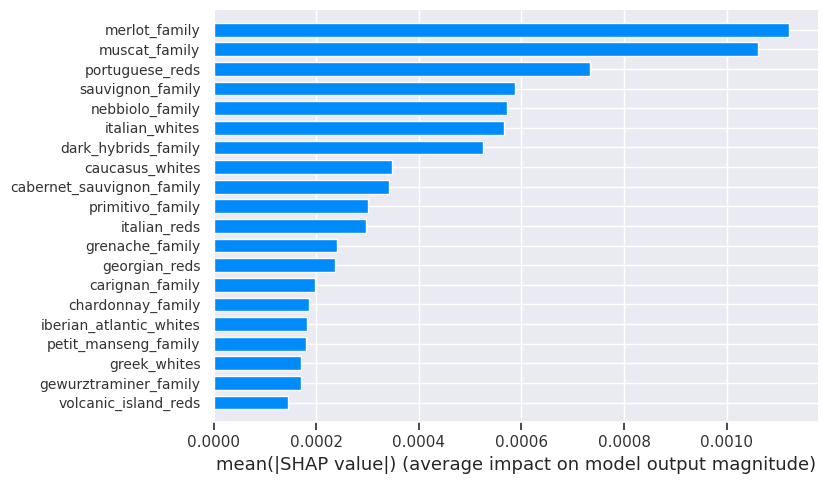

In [ ]:
selected_features = ['merlot_family']
selected_features = np.intersect1d(grapes_cols,test_transformed.columns)
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False, plot_type="bar", plot_size=[9,5])
plt.tight_layout()
plt.yticks(fontsize=10)
plt.savefig('img/shap/grapes_bar_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

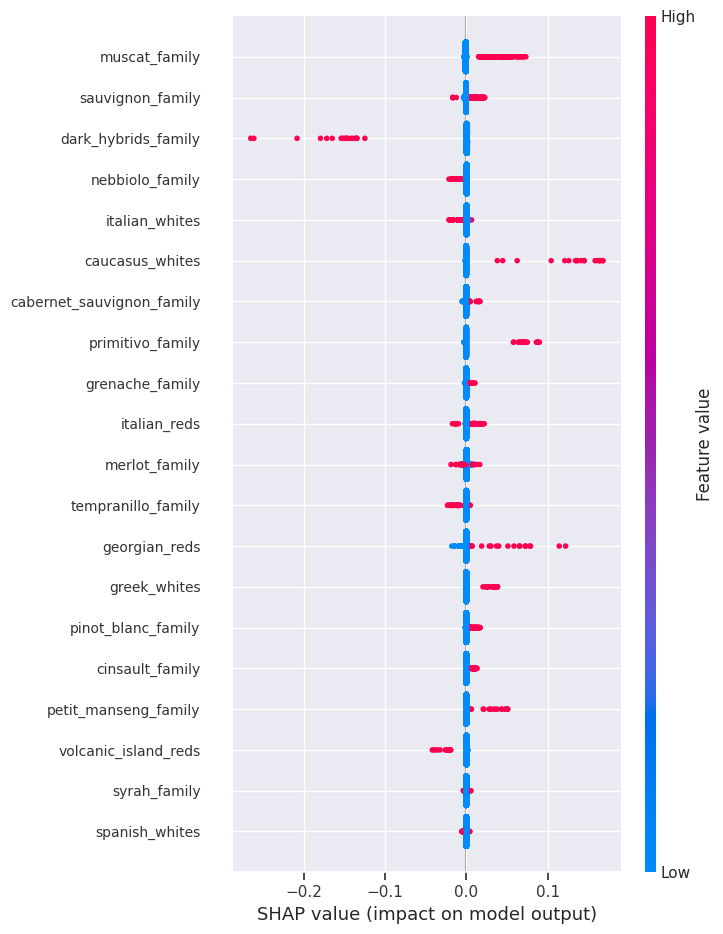

In [ ]:
selected_features = ['merlot_family']
selected_features = np.intersect1d(grapes_cols,test_transformed.columns)
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False)
plt.tight_layout()
plt.yticks(fontsize=10)
plt.savefig('img/shap/class_grapes_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

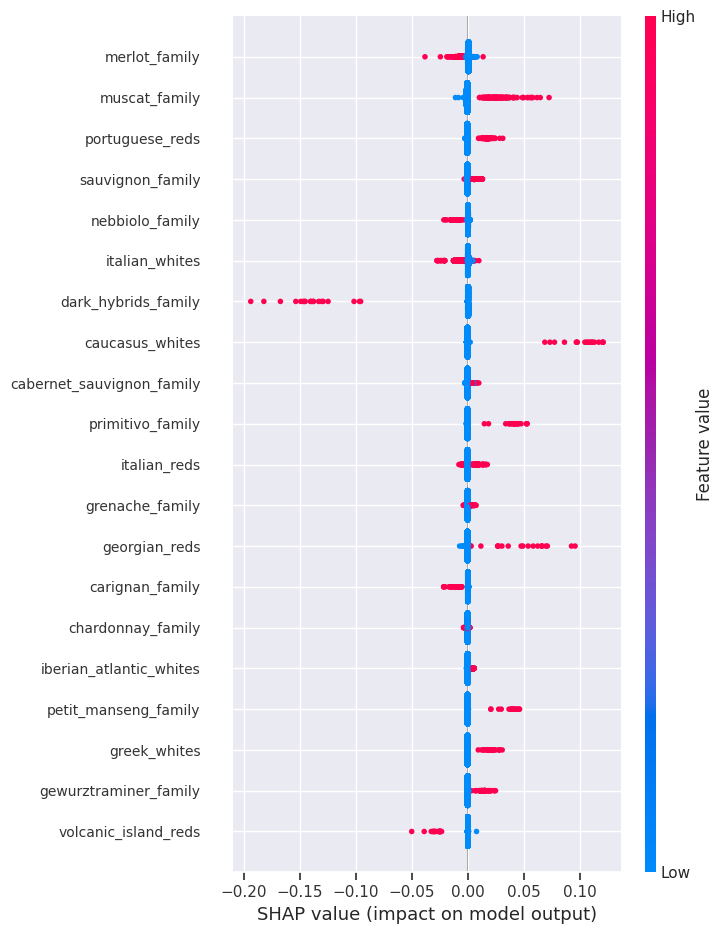

In [ ]:
selected_features = ['merlot_family']
selected_features = np.intersect1d(grapes_cols,test_transformed.columns)
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False)
plt.tight_layout()
plt.yticks(fontsize=10)
plt.savefig('img/shap/grapes_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

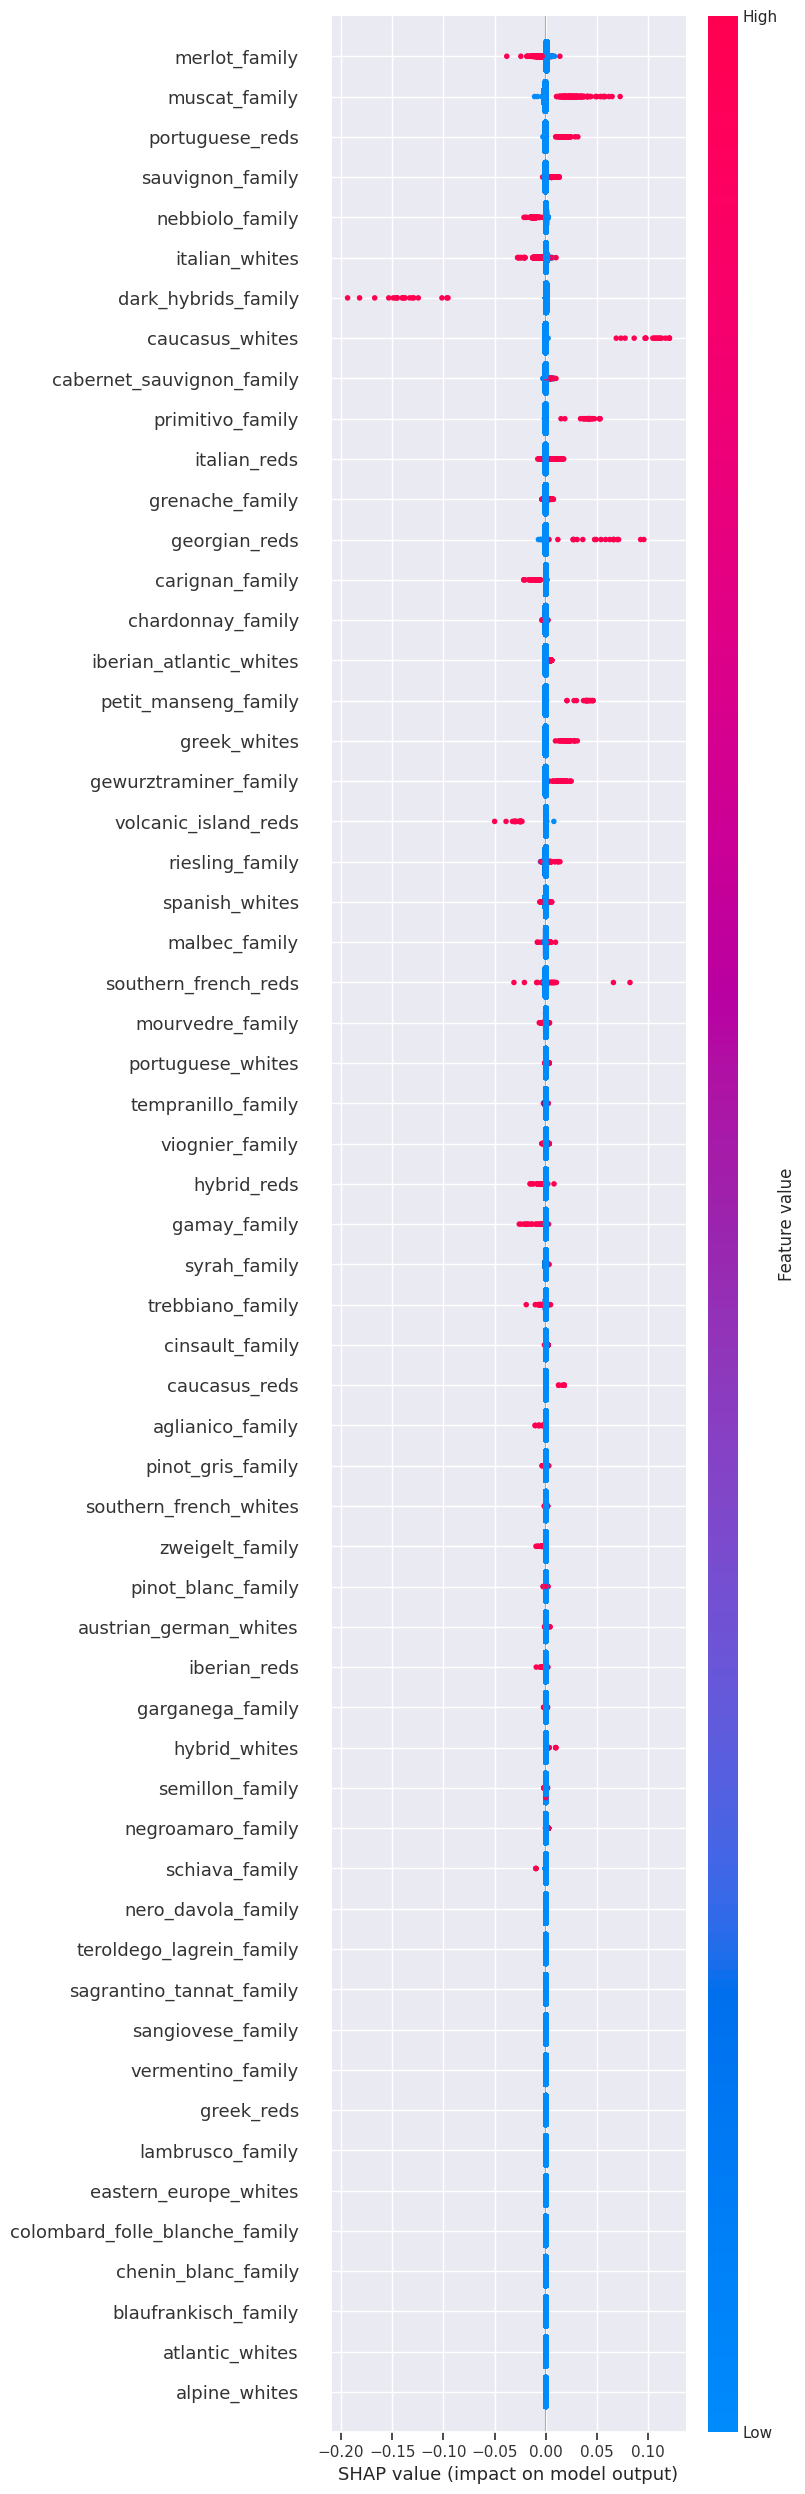

In [ ]:
# all
selected_features = ['merlot_family']
selected_features = np.intersect1d(grapes_cols,test_transformed.columns)
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False, max_display=len(selected_features))
# plt.savefig('img/shap_all.jpg', dpi = 300, bbox_inches='tight')
plt.show()

#### Food

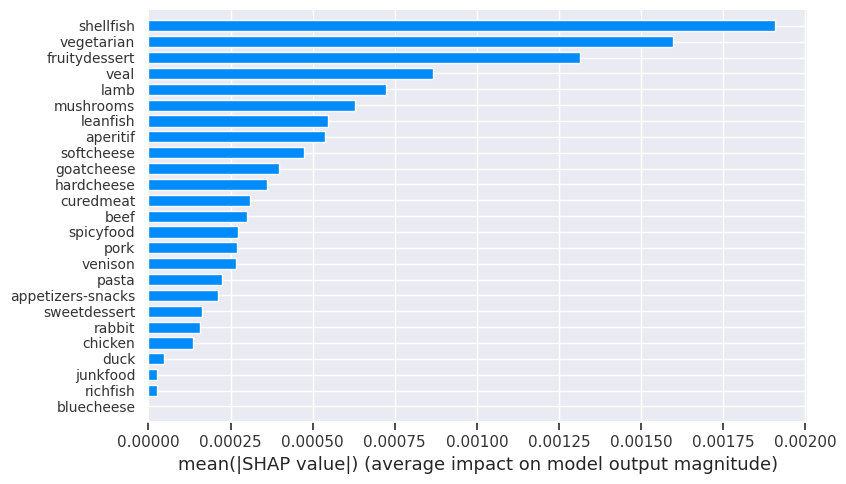

In [ ]:
selected_features = np.intersect1d(food_col,test_transformed.columns)
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False, plot_type="bar", plot_size=[9,5], max_display=len(selected_features))
plt.tight_layout()
plt.yticks(fontsize=10)
plt.savefig('img/shap/class_food_bar_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

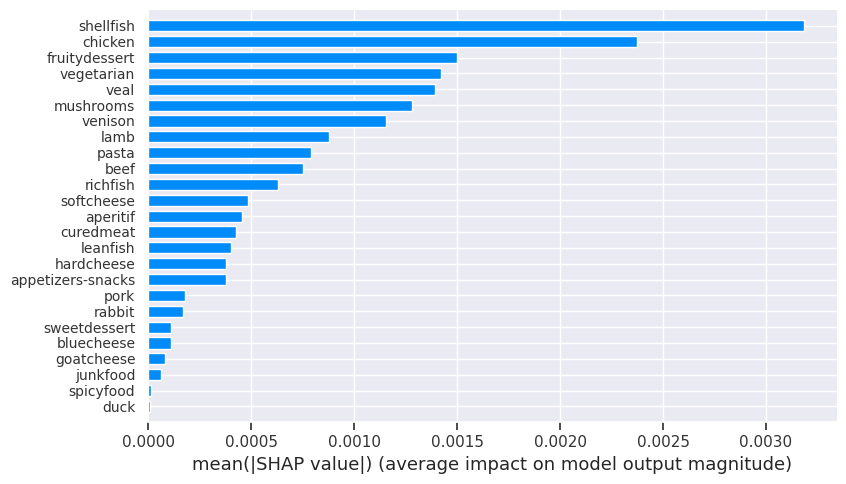

In [ ]:
selected_features = np.intersect1d(food_col,test_transformed.columns)
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False, plot_type="bar", plot_size=[9,5], max_display=len(selected_features))
plt.tight_layout()
plt.yticks(fontsize=10)
plt.savefig('img/shap/food_bar_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

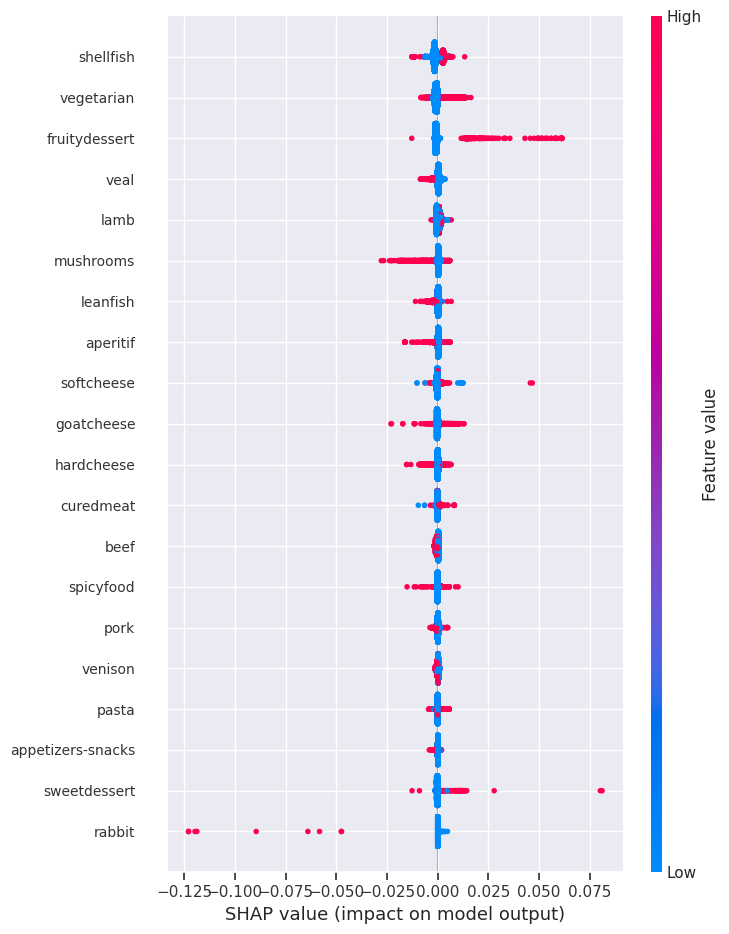

In [ ]:
selected_features = np.intersect1d(food_col,test_transformed.columns)
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False)
plt.tight_layout()
plt.yticks(fontsize=10)
plt.savefig('img/shap/class_food_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

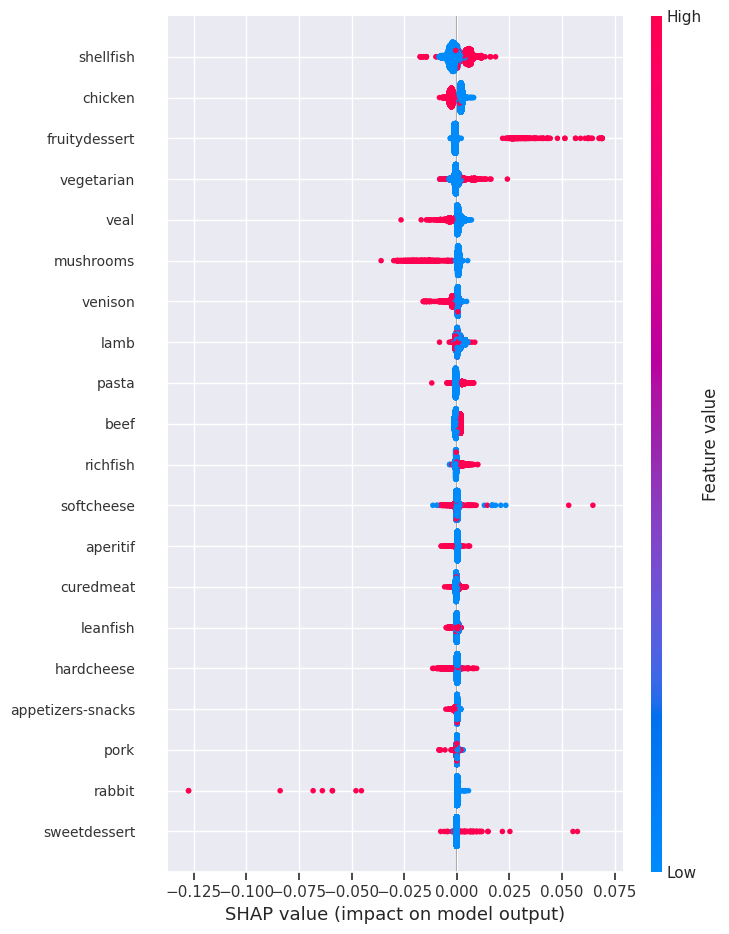

In [ ]:
selected_features = np.intersect1d(food_col,test_transformed.columns)
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap_values = explainer.shap_values(test_transformed)
shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False)
plt.tight_layout()
plt.yticks(fontsize=10)
plt.savefig('img/shap/food_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

#### Type

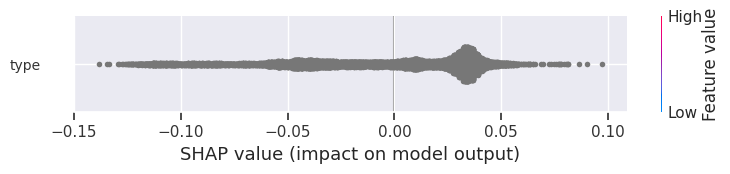

In [ ]:
selected_features = ['type']
feature_idx = [test_transformed.columns.get_loc(f) for f in selected_features]

shap.summary_plot(shap_values[:, feature_idx], test_transformed.iloc[:, feature_idx], show=False)
plt.tight_layout()
plt.yticks(fontsize=10)
# plt.savefig('img/shap/food_top.jpg', dpi = 300, bbox_inches='tight')
plt.show()

In [ ]:
shap_df = pd.DataFrame(shap_values, columns=test_transformed.columns)

In [ ]:
shap_df['type_name'] = test_transformed['type'].values

In [ ]:
mean_shap = (
        shap_df
        .groupby("type_name")['type']
        .mean()
        .sort_values()
    )

mean_abs_shap = (
        shap_df
        .groupby("type_name")['type']
        .apply(lambda x: x.abs().mean())
        .sort_values()
    )

/tmp/ipykernel_11759/2292341830.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("type_name")['type']
/tmp/ipykernel_11759/2292341830.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("type_name")['type']


In [ ]:
mean_shap = mean_shap.sort_values(ascending=False)

In [ ]:
mean_abs_shap.sort_values(ascending=False).index.to_list()

['rose', 'white', 'red', 'spark', 'dessert', 'orange', 'fortif']

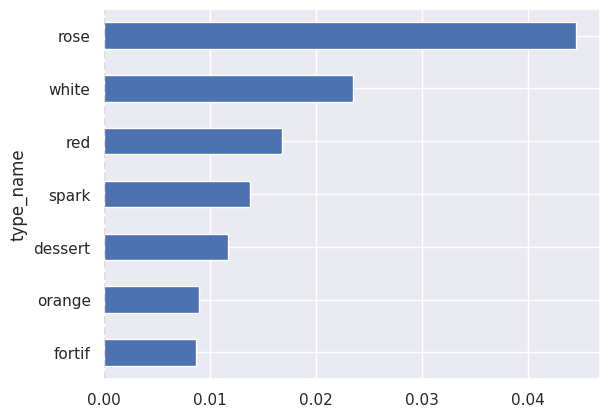

In [ ]:
mean_abs_shap.plot(kind="barh") 
plt.axvline(0, color="black", linestyle="--") 
plt.show()

In [ ]:
l = [8, 7, 6, 3, 1, 9, 5]
colors = [sns.color_palette('deep')[i] for i in l]

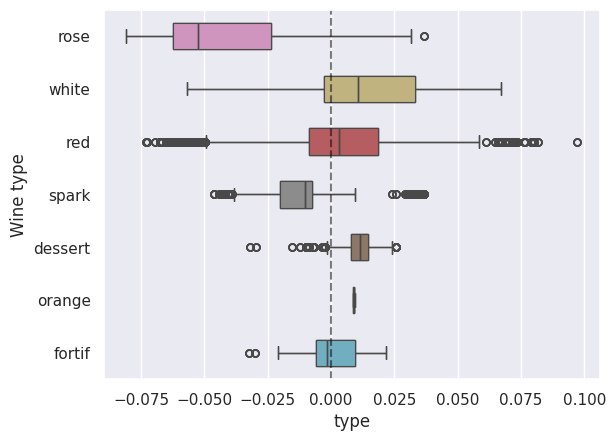

In [ ]:
for i, (index, value) in enumerate(mean_shap.items()):
    
    sns.boxplot(
        shap_df, 
        x="type", 
        y="type_name",
        hue="type_name",
        width=0.5,  # Width of the box
        fliersize=5,  # Size of outliers
        linewidth=0.8,  # Box outline thickness
        order=mean_abs_shap.sort_values(ascending=False).index.to_list(),  # Set the order of categories on the x-axis
        palette=colors[::-1], 
    )

plt.axvline(0, color="black", linestyle="--", alpha = 0.5)
plt.ylabel("Wine type")
plt.savefig("img/shap/class_type_boxplot.jpg", dpi=300)
plt.show()

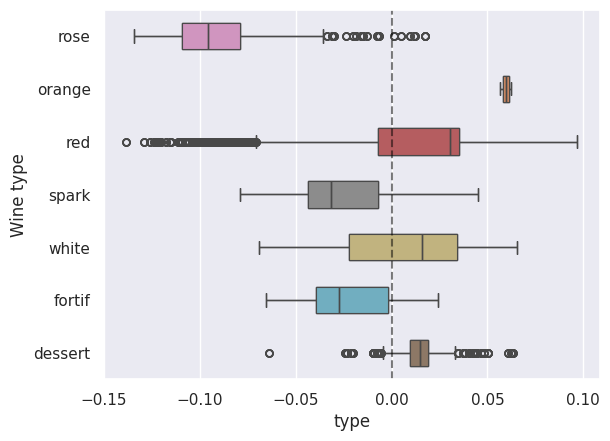

In [ ]:
for i, (index, value) in enumerate(mean_shap.items()):
    
    sns.boxplot(
        shap_df, 
        x="type", 
        y="type_name",
        hue="type_name",
        width=0.5,  # Width of the box
        fliersize=5,  # Size of outliers
        linewidth=0.8,  # Box outline thickness
        order=mean_abs_shap.sort_values(ascending=False).index.to_list(),  # Set the order of categories on the x-axis
        palette=colors[::-1], 
    )

plt.axvline(0, color="black", linestyle="--", alpha = 0.5)
plt.ylabel("Wine type")
plt.savefig("img/shap/type_boxplot.jpg", dpi=300)
plt.show()

#### Region name

In [ ]:
shap_df['region_name_name'] = test_transformed['region_name']

sort most influential

In [ ]:
mean_abs_shap = (
        shap_df
        .groupby("region_name_name")['region_name']
        .apply(lambda x: x.abs().mean())
        .sort_values(ascending=False)
    )

mean_shap = (
        shap_df
        .groupby("region_name_name")['region_name']
        .mean()
        .sort_values(ascending=False)
    )

/tmp/ipykernel_11759/1804778101.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("region_name_name")['region_name']
/tmp/ipykernel_11759/1804778101.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("region_name_name")['region_name']


In [ ]:
mean_shap

region_name_name
Кубань                                         0.062593
Крым                                           0.059703
Valul lui Traian                               0.059270
Вайоц Дзор                                     0.058049
Codru                                          0.054581
                                                 ...   
Savigny-lès-Beaune 1er Cru 'Les Narbantons'   -0.047501
Imereti                                       -0.048381
Buzet                                         -0.048446
Verdicchio di Matelica                        -0.049131
Sanlúcar de Barrameda                         -0.049685
Name: region_name, Length: 954, dtype: float64

In [ ]:
mean_abs_shap = mean_abs_shap.sort_values(ascending=False)
mean_abs_shap.index[:10]

CategoricalIndex(['Кубань', 'Крым', 'Valul lui Traian', 'Вайоц Дзор', 'Codru',
                  'Арагацотн', 'Sanlúcar de Barrameda',
                  'Verdicchio di Matelica', 'Buzet', 'Imereti'],
                 categories=['Abadía Retuerta', 'Abruzzo', 'Achkarren', 'Adelaide Hills', ..., 'Вайоц Дзор', 'Крым', 'Кубань', 'Тавуш'], ordered=False, dtype='category', name='region_name_name')

In [ ]:
tmp_df = shap_df[shap_df['region_name_name'].isin(mean_abs_shap.index[:10])][['region_name', 'region_name_name']]

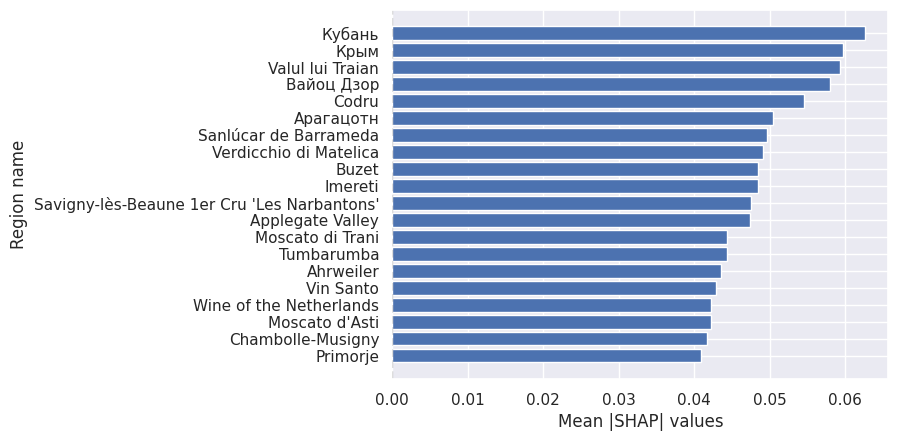

In [ ]:
# mean_abs_shap.head(10).plot(kind="barh") 
plt.barh(mean_abs_shap.head(20)[::-1].index, mean_abs_shap.head(20)[::-1].values)
plt.axvline(0, color="black", linestyle="--") 
plt.xlabel("Mean |SHAP| values")
plt.ylabel("Region name")
plt.savefig("img/shap/class_reg_n_top20_abs.jpg", dpi=300)
plt.show()

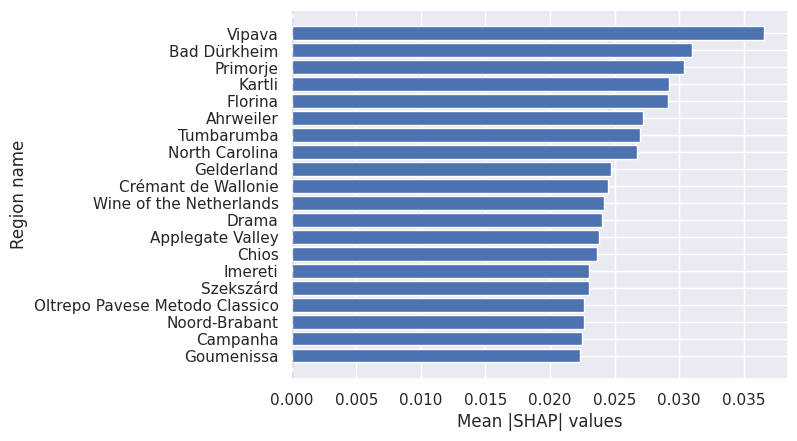

In [ ]:
# mean_abs_shap.head(10).plot(kind="barh") 
plt.barh(mean_abs_shap.head(20)[::-1].index, mean_abs_shap.head(20)[::-1].values)
plt.axvline(0, color="black", linestyle="--") 
plt.xlabel("Mean |SHAP| values")
plt.ylabel("Region name")
plt.savefig("img/shap/reg_n_top20_abs.jpg", dpi=300)
plt.show()

In [ ]:
e = shap_df[shap_df['region_name_name'].isin(mean_abs_shap.index[:20][::-1])][['region_name', 'region_name_name']]
e['region_name_name'] = e['region_name_name'].astype(str)
e.shape

(117, 2)

In [ ]:
e['region_name_name'].unique()

array(['Chambolle-Musigny', 'Кубань', "Moscato d'Asti", 'Вайоц Дзор',
       'Крым', 'Tumbarumba',
       "Savigny-lès-Beaune 1er Cru 'Les Narbantons'", 'Imereti',
       'Verdicchio di Matelica', 'Moscato di Trani', 'Applegate Valley',
       'Codru', 'Арагацотн', 'Primorje', 'Ahrweiler', 'Vin Santo',
       'Sanlúcar de Barrameda', 'Wine of the Netherlands',
       'Valul lui Traian', 'Buzet'], dtype=object)

<Axes: xlabel='region_name', ylabel='region_name_name'>

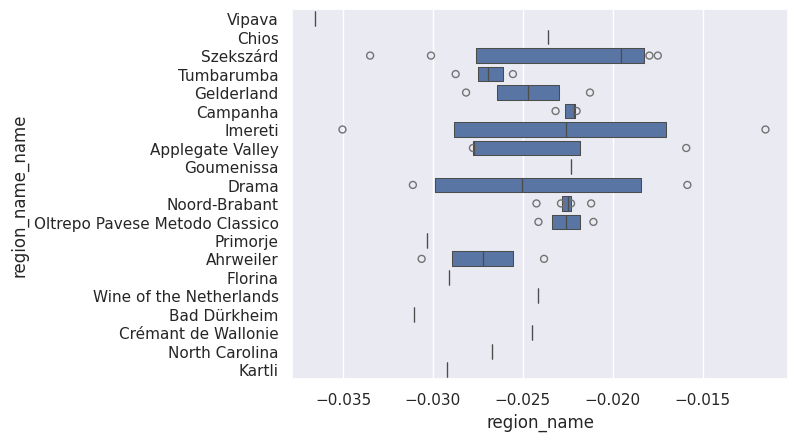

In [ ]:
sns.boxenplot(
    e,
    x= "region_name", 
    y = "region_name_name"
)

Looking at those with the most wines

In [ ]:
most_pop_regn = shap_df.groupby('region_name_name')['region_name'].count().sort_values(ascending=False).index[:20].to_list()

/tmp/ipykernel_11759/83422709.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  most_pop_regn = shap_df.groupby('region_name_name')['region_name'].count().sort_values(ascending=False).index[:20].to_list()


In [ ]:
most_pop_regn

['Champagne',
 'Willamette Valley',
 'Pfalz',
 'Ribera del Duero',
 'Rioja',
 'Columbia Valley',
 'Barolo',
 'Stellenbosch',
 'Mosel',
 'Toscana',
 'Baden',
 'Cava',
 'Douro',
 'Südtirol - Alto Adige',
 'Brunello di Montalcino',
 'Saint-Émilion Grand Cru',
 'Barossa Valley',
 'Marlborough',
 'Franciacorta',
 'Sauternes']

In [ ]:
e = shap_df[shap_df['region_name_name'].isin(most_pop_regn)][['region_name', 'region_name_name']]
e['region_name_name'] = e['region_name_name'].astype(str)
e.shape

(2696, 2)

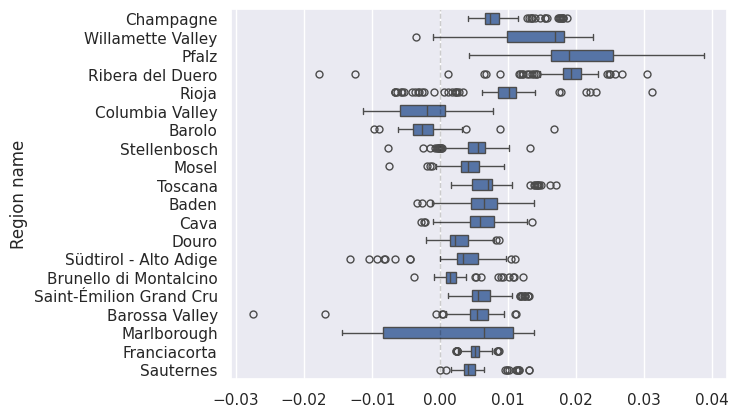

In [ ]:
sns.boxplot(
    e,
    x = "region_name", 
    y = "region_name_name",
    order=most_pop_regn,
    width=0.6,          
    saturation=0.8,
    flierprops=dict(
        marker='o',       # shape of the extreme points
        markersize=5,    # size of the extreme points
    )
)
plt.ylabel("Region name")
plt.xlabel("")
plt.axvline(x=0, linestyle='--', linewidth=1, alpha = 0.2, color="black")
# plt.savefig('img/shap/regn_top_pop_dist.jpg', dpi=300)

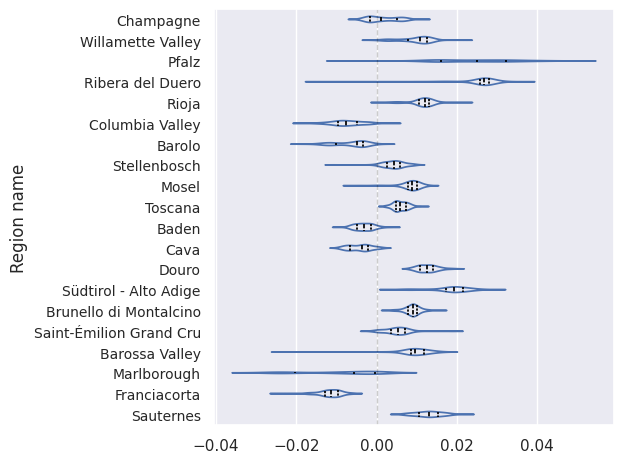

In [ ]:
# test violin CLASS
ax = sns.violinplot(
    data=e,
    x="region_name",
    y="region_name_name",
    order=most_pop_regn,
    color="none", 
    width=0.6,            # width of each violin
    inner="quartile",     # shows median and quartiles inside the violin
    # saturation=0.8
)

for violin in ax.collections:
    violin.set_facecolor('none')  # removes fill
    violin.set_edgecolor(sns.color_palette('deep')[0]) # keeps outline
    violin.set_alpha(1)           # ensures it's fully visible


plt.ylabel("Region name")
plt.xlabel("")
plt.axvline(x=0, linestyle='--', linewidth=1, alpha = 0.2, color="black")
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('img/shap/class_regn_top_pop_dist_vp.jpg', dpi=300)

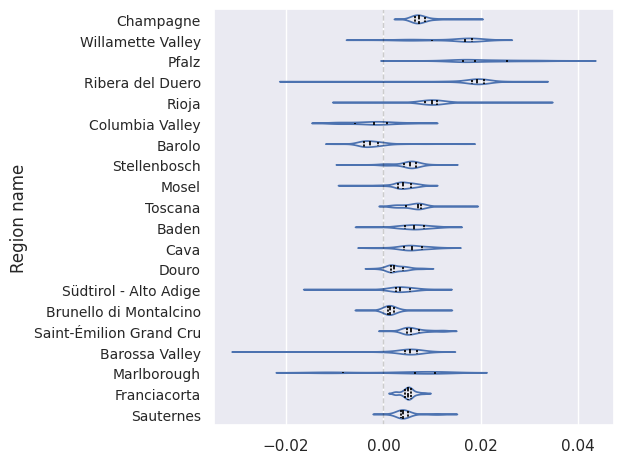

In [ ]:
# test violin
ax = sns.violinplot(
    data=e,
    x="region_name",
    y="region_name_name",
    order=most_pop_regn,
    color="none", 
    width=0.6,            # width of each violin
    inner="quartile",     # shows median and quartiles inside the violin
    # saturation=0.8
)

for violin in ax.collections:
    violin.set_facecolor('none')  # removes fill
    violin.set_edgecolor(sns.color_palette('deep')[0]) # keeps outline
    violin.set_alpha(1)           # ensures it's fully visible


plt.ylabel("Region name")
plt.xlabel("")
plt.axvline(x=0, linestyle='--', linewidth=1, alpha = 0.2, color="black")
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('img/shap/regn_top_pop_dist_vp.jpg', dpi=300)

#### Country


In [ ]:
shap_df['country_name'] = test_transformed['country']

In [ ]:
mean_shap = (
        shap_df
        .groupby("country_name")['country']
        .mean()
        .sort_values(ascending=False)
    )

mean_abs_shap = (
        shap_df
        .groupby("country_name")['country']
        .apply(lambda x: x.abs().mean())
        .sort_values(ascending=False)
    )

/tmp/ipykernel_11759/3201668027.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("country_name")['country']
/tmp/ipykernel_11759/3201668027.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("country_name")['country']


In [ ]:
mean_abs_shap 

country_name
Moldova          0.451067
Russia           0.417463
Armenia          0.406790
Georgia          0.093592
Netherlands      0.072181
Belgium          0.068766
Mexico           0.064755
Greece           0.061761
Slovenia         0.056396
Austria          0.053542
Hungary          0.050310
Brazil           0.049351
New Zealand      0.032036
Portugal         0.028044
Australia        0.024708
Spain            0.022564
Germany          0.022311
Italy            0.015305
United States    0.015190
France           0.010592
South Africa     0.009328
Name: country, dtype: float64

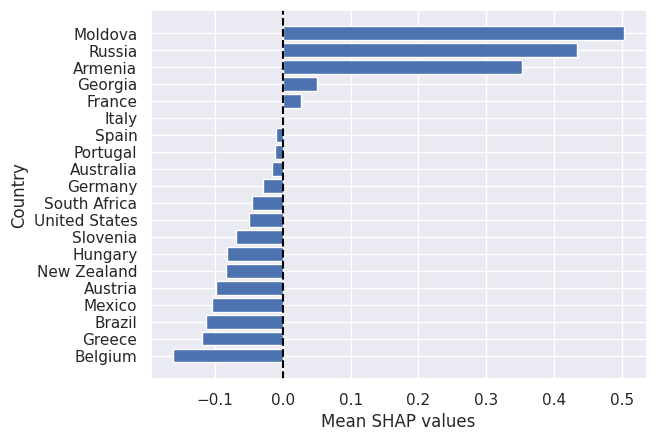

In [ ]:
# mean_abs_shap.head(10).plot(kind="barh") 
plt.barh(mean_shap.head(20)[::-1].index, mean_shap.head(20)[::-1].values)
plt.axvline(0, color="black", linestyle="--") 
plt.xlabel("Mean SHAP values")
plt.ylabel("Country")
plt.savefig("img/shap/reg_country_top20.jpg", dpi=300)
plt.show()

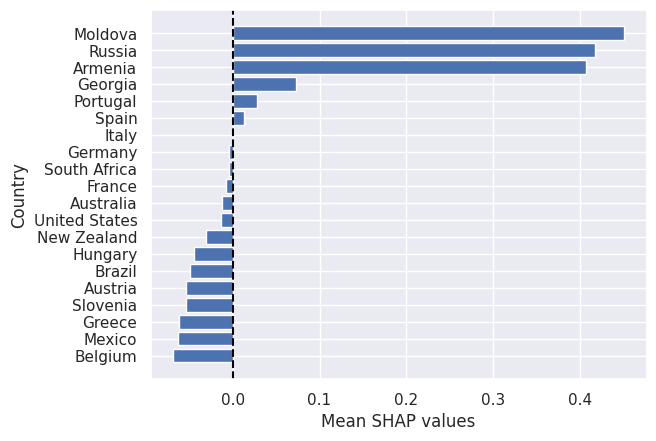

In [ ]:
# mean_abs_shap.head(10).plot(kind="barh") 
plt.barh(mean_shap.head(20)[::-1].index, mean_shap.head(20)[::-1].values)
plt.axvline(0, color="black", linestyle="--") 
plt.xlabel("Mean SHAP values")
plt.ylabel("Country")
plt.savefig("img/shap/class_country_top20.jpg", dpi=300)
plt.show()

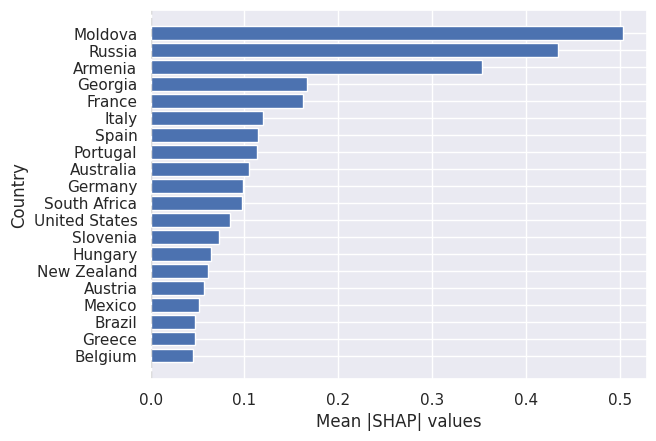

In [ ]:
# mean_abs_shap.head(10).plot(kind="barh") 
plt.barh(mean_abs_shap.head(20)[::-1].index, mean_abs_shap.head(20)[::-1].values)
plt.axvline(0, color="black", linestyle="--") 
plt.xlabel("Mean |SHAP| values")
plt.ylabel("Country")
# plt.savefig("img/shap/country_top20_abs.jpg", dpi=300)
plt.show()

In [ ]:
most_pop_regn = shap_df.groupby('country_name')['country'].count().sort_values(ascending=False).index[:20].to_list()
most_pop_regn

/tmp/ipykernel_11759/1741240044.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  most_pop_regn = shap_df.groupby('country_name')['country'].count().sort_values(ascending=False).index[:20].to_list()


['France',
 'Italy',
 'Spain',
 'United States',
 'Germany',
 'Australia',
 'South Africa',
 'Portugal',
 'New Zealand',
 'Austria',
 'Greece',
 'Russia',
 'Georgia',
 'Hungary',
 'Slovenia',
 'Netherlands',
 'Brazil',
 'Mexico',
 'Belgium',
 'Armenia']

In [ ]:
e = shap_df[shap_df['country_name'].isin(most_pop_regn)][['country_name', 'country']]
e['country_name'] = e['country_name'].astype(str)
e.shape

(9326, 2)

In [ ]:
sns.boxplot(
    e,
    x = "country", 
    y = "country_name",
    order=most_pop_regn,
    width=0.6,          
    saturation=0.8,
    flierprops=dict(
        marker='o',       # shape of the extreme points
        markersize=5,    # size of the extreme points
    )
)
plt.ylabel("Country")
plt.xlabel("")
plt.axvline(x=0, linestyle='--', linewidth=1, alpha = 0.2, color="black")
plt.tight_layout()
plt.savefig('img/shap/count_top_pop_dist.jpg', dpi=300)

In [ ]:
wines[wines['country'] == "Armenia"].shape

(25, 25)

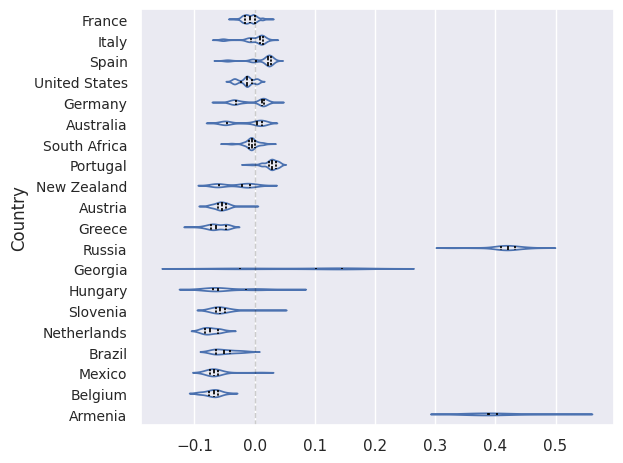

In [ ]:
# test violin CLASS
ax = sns.violinplot(
    data=e,
    x = "country", 
    y = "country_name",
    order=most_pop_regn,
    color="none", 
    width=0.6,            # width of each violin
    inner="quartile",     # shows median and quartiles inside the violin
    # saturation=0.8
)

for violin in ax.collections:
    violin.set_facecolor('none')  # removes fill
    violin.set_edgecolor(sns.color_palette('deep')[0]) # keeps outline
    violin.set_alpha(1)           # ensures it's fully visible


plt.ylabel("Country")
plt.xlabel("")
plt.axvline(x=0, linestyle='--', linewidth=1, alpha = 0.2, color="black")
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('img/shap/class_count_top_pop_dist_vp.jpg', dpi=300)

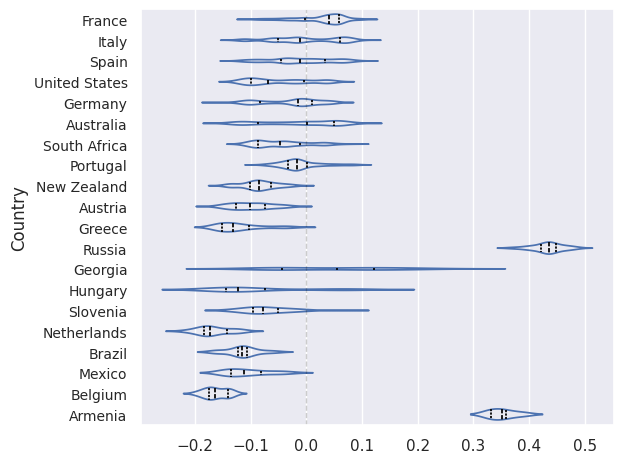

In [ ]:
# test violin
ax = sns.violinplot(
    data=e,
    x = "country", 
    y = "country_name",
    order=most_pop_regn,
    color="none", 
    width=0.6,            # width of each violin
    inner="quartile",     # shows median and quartiles inside the violin
    # saturation=0.8
)

for violin in ax.collections:
    violin.set_facecolor('none')  # removes fill
    violin.set_edgecolor(sns.color_palette('deep')[0]) # keeps outline
    violin.set_alpha(1)           # ensures it's fully visible


plt.ylabel("Country")
plt.xlabel("")
plt.axvline(x=0, linestyle='--', linewidth=1, alpha = 0.2, color="black")
plt.yticks(fontsize=10)
plt.tight_layout()
plt.savefig('img/shap/count_top_pop_dist_vp.jpg', dpi=300)

---


#### Tastes

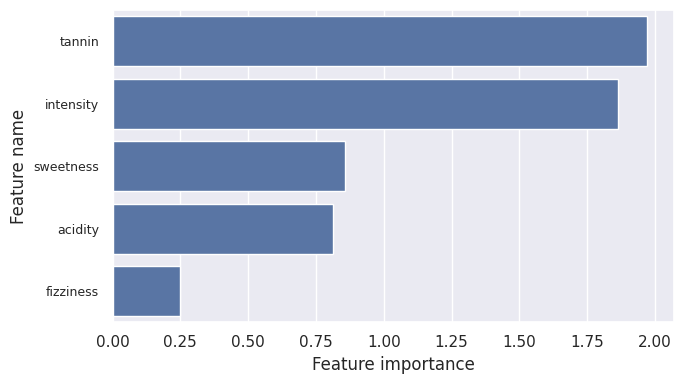

In [ ]:
plt.figure(figsize=(7, 4))
sns.set_theme(style="darkgrid")
sns.barplot(df_cat_reg_feat_imp[df_cat_reg_feat_imp['feat_name'].isin(taste_cols)], x="feat_imp", y="feat_name")
plt.yticks(fontsize=9)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.tight_layout()
plt.savefig('img/reg_fimp_taste.jpg', dpi=300)

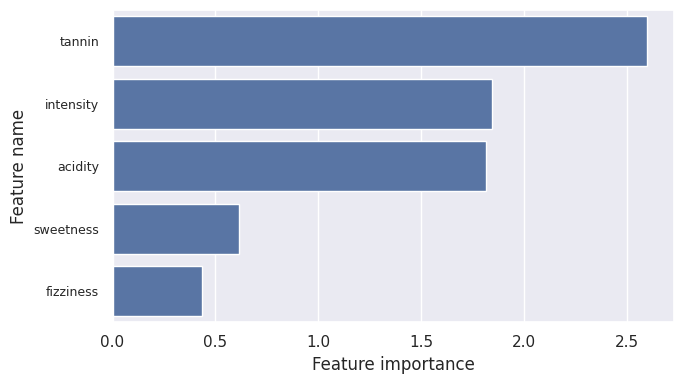

In [ ]:
plt.figure(figsize=(7, 4))
sns.set_theme(style="darkgrid")
sns.barplot(df_cat_reg_feat_imp[df_cat_reg_feat_imp['feat_name'].isin(taste_cols)], x="feat_imp", y="feat_name")
plt.yticks(fontsize=9)
plt.xlabel("Feature importance")
plt.ylabel("Feature name")
plt.tight_layout()
plt.savefig('img/class_fimp_taste.jpg', dpi=300)

In [ ]:
np.array(taste_cols) + '_name'

array(['sweetness_name', 'acidity_name', 'tannin_name', 'fizziness_name',
       'intensity_name'], dtype='<U14')

In [ ]:
test_transformed[taste_cols]

,sweetness,acidity,tannin,fizziness,intensity
0,1.0,4.5,2.5,0.0,3.0
1,NaN,NaN,0.0,0.0,NaN
2,2.0,3.0,0.0,0.0,4.0
3,1.5,3.0,0.0,0.0,3.0
4,1.0,4.0,4.0,0.0,4.0
...,...,...,...,...,...
9324,1.5,3.0,0.0,0.0,3.0
9325,1.0,4.0,0.0,0.0,2.0
9326,1.0,3.0,3.5,0.0,5.0
9327,1.0,2.5,0.0,1.0,2.5


In [ ]:
shap_df[taste_cols] 

,sweetness,acidity,tannin,fizziness,intensity
0,0.003438,-0.005118,0.009162,0.000817,-0.002461
1,0.002269,0.004076,-0.008892,0.000847,-0.009955
2,-0.004068,0.002305,-0.008587,0.000997,0.002601
3,-0.008934,-0.001332,-0.012811,-0.000378,-0.005137
4,0.002453,-0.000584,0.021076,0.001189,0.002576
...,...,...,...,...,...
9324,-0.007035,-0.001016,-0.004354,0.000853,-0.003843
9325,0.002279,0.000996,-0.007701,0.000455,0.004988
9326,0.002084,0.004002,0.016426,0.001192,0.004972
9327,0.010774,0.006748,-0.003489,0.000615,0.010614


In [ ]:
melted_df = shap_df[taste_cols].melt(var_name="Taste", value_name="Value")

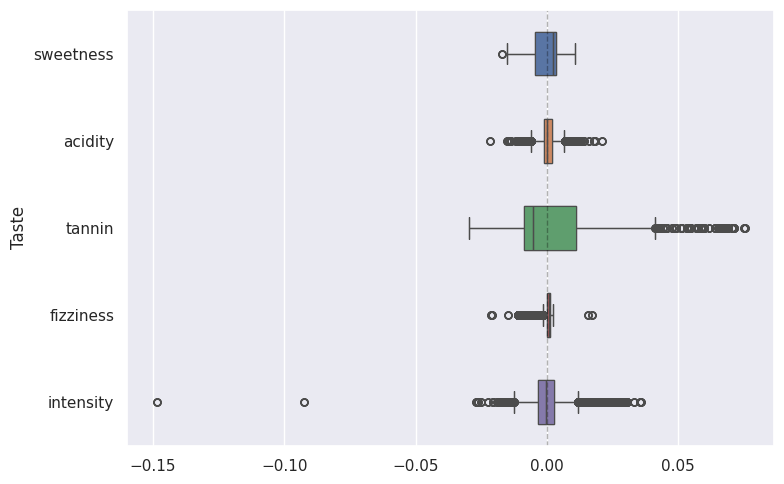

In [ ]:
plt.figure(figsize=(8, 5))

for i, taste in enumerate(taste_cols):
    sns.boxplot(
        melted_df, 
        x="Value",  # Variable name (this will correspond to the different taste columns)
        y="Taste",  # Values in the taste columns
        hue="Taste",  # Use hue to differentiate the tastes
        width=0.5,  # Width of the box
        fliersize=5,  # Size of outliers
        linewidth=0.8,  # Box outline thicknes
    )

plt.xlabel('')
plt.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)  # Vertical line at x=0
plt.tight_layout()
plt.savefig("img/shap/reg_tast_dist.jpg", dpi=300)


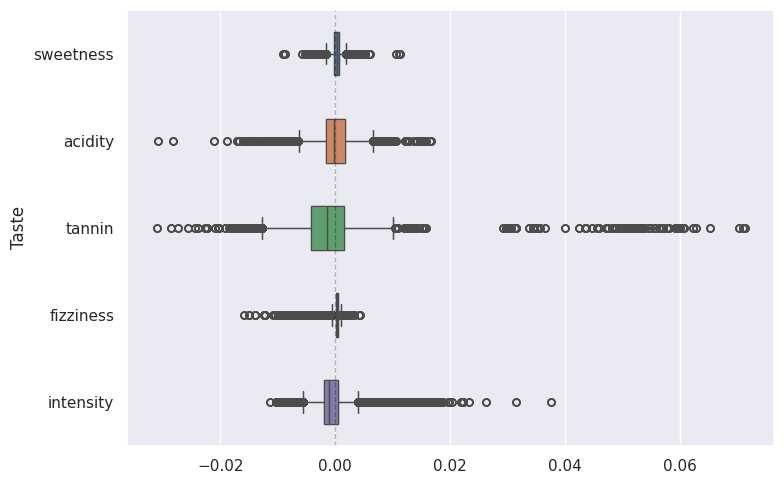

In [ ]:
plt.figure(figsize=(8, 5))

for i, taste in enumerate(taste_cols):
    sns.boxplot(
        melted_df, 
        x="Value",  # Variable name (this will correspond to the different taste columns)
        y="Taste",  # Values in the taste columns
        hue="Taste",  # Use hue to differentiate the tastes
        width=0.5,  # Width of the box
        fliersize=5,  # Size of outliers
        linewidth=0.8,  # Box outline thicknes
    )

plt.xlabel('')
plt.axvline(0, color="black", linestyle="--", linewidth=1, alpha=0.3)  # Vertical line at x=0
plt.tight_layout()
plt.savefig("img/shap/classif_tast_dist?jpg", dpi=300)
